<a href="https://colab.research.google.com/github/mehrerm/TFM/blob/main/notebooks/WOE_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

En este notebook se trabajará con el dataset ya depurado listo, se conservarán todas las librerías importadas utilizadas durante el EDA y los que se consideren necesarios.

In [2]:
#Cargo o importo pandas, numpy, Matplotlib,
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import statsmodels.api as sm

import requests
import unicodedata
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

!pip install optbinning
from optbinning import OptimalBinning, Scorecard, BinningProcess
from sklearn.linear_model import LogisticRegression
from urllib.parse import quote


#lugar donde se van guardando las figuras
fig_dir = "figuras"
os.makedirs(fig_dir, exist_ok=True)

table_dir = "tablas"
os.makedirs(table_dir, exist_ok=True)



#########################

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.8/214.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 11.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 5.26.1 which is incompatible.
ydf 0.14.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 5.26.1 which is incompatibl

In [3]:
!git clone https://github.com/mehrerm/TFM.git


Cloning into 'TFM'...
remote: Enumerating objects: 307, done.
remote: Counting objects: 100% (113/113), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 307 (delta 50), reused 1 (delta 1), pack-reused 194 (from 1)
Receiving objects: 100% (307/307), 25.90 MiB | 10.56 MiB/s, done.
Resolving deltas: 100% (123/123), done.


In [4]:
df_merged = pd.read_csv("TFM/data/processed/df_merged.csv")

df_merged.head()


,Cancer label,Sex,Type,Year,ASR (World),Crude rate,Cumulative risk,Total,Country_harmonized,RTCenters,Linac,Protontherapy,XRay,Brachytherapy,Last Update,Region Name,Population,Population_male,Population_female,GDP_per_capita
0,Lung,Male,Incidence,2007,61.434111,80.958928,7.865065,3666,Belarus,13,31,0,11,17,2024,Eastern Europe,9563133.0,4450421.0,5112713.0,4735.481076
1,Lung,Male,Incidence,2008,62.729974,84.930604,8.033257,3765,Belarus,13,31,0,11,17,2024,Eastern Europe,9529358.0,4432534.0,5096824.0,6376.175692
2,Lung,Male,Incidence,2009,61.098990,84.106229,7.731976,3719,Belarus,13,31,0,11,17,2024,Eastern Europe,9507337.0,4421224.0,5086114.0,5352.488092
3,Lung,Male,Incidence,2010,62.582334,86.376743,7.914747,3812,Belarus,13,31,0,11,17,2024,Eastern Europe,9490752.0,4412608.0,5078144.0,6034.678852
4,Lung,Male,Incidence,2011,59.755001,83.234410,7.621488,3665,Belarus,13,31,0,11,17,2024,Eastern Europe,9472735.0,4402539.0,5070196.0,6527.659343


In [5]:
#se separan por sexo

df_male = df_merged[df_merged["Sex"] == "Male"].copy()
df_female = df_merged[df_merged["Sex"] == "Female"].copy()

#se toma en cuenta solamente el 2022




*Una vez armonizados y fusionados los países, los datos epidemiológicos procedentes de GLOBOCAN se integraron con la información sobre infraestructuras de radioterapia registrada en la base de datos DIRAC.

Antes de abordar los análisis de relación, se realizó un análisis exploratorio visual (EDA) estratificado por año y sexo, con el objetivo de contextualizar la evolución temporal de la incidencia y la mortalidad por cáncer. Este análisis permitió identificar el periodo más adecuado para el estudio principal, teniendo en cuenta posibles distorsiones en los indicadores de salud asociadas a acontecimientos excepcionales, como la pandemia de COVID-19 a partir del año 2020, que alteró significativamente los patrones de diagnóstico y tratamiento. Con esto además, podemos visualizar como evoluciona la incidencia y mortalidad en el timepo, si existen diferencias sistemáticas por sexo y detectar patrones globales.

Ahora se hará un análisis de relación




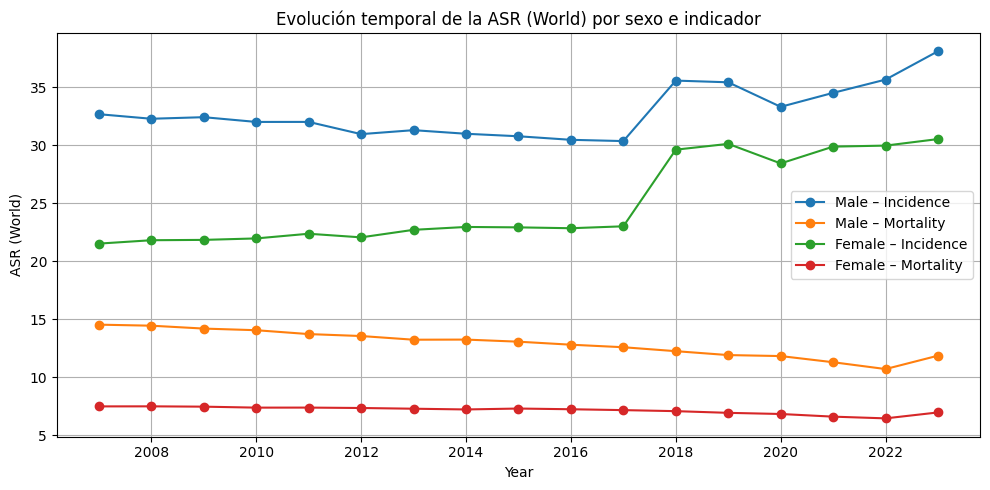

In [6]:
df_trend = (
    df_merged
    #df_22
    .dropna(subset=["Year", "ASR (World)", "Sex", "Type"])
    .groupby(["Year", "Sex", "Type"], as_index=False)
    .agg({"ASR (World)": "mean"})
    .sort_values("Year")
)

%matplotlib inline

plt.figure(figsize=(10,5))

for sex in ["Male", "Female"]:
    for t in ["Incidence", "Mortality"]:
        sub = df_trend[(df_trend["Sex"] == sex) & (df_trend["Type"] == t)]
        plt.plot(
            sub["Year"],
            sub["ASR (World)"],
            marker="o",
            label=f"{sex} – {t}"
        )

plt.xlabel("Year")
plt.ylabel("ASR (World)")
plt.title("Evolución temporal de la ASR (World) por sexo e indicador")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{fig_dir}/fig01_figure_ASR_anno.jpg", dpi=300, bbox_inches="tight")
plt.show()




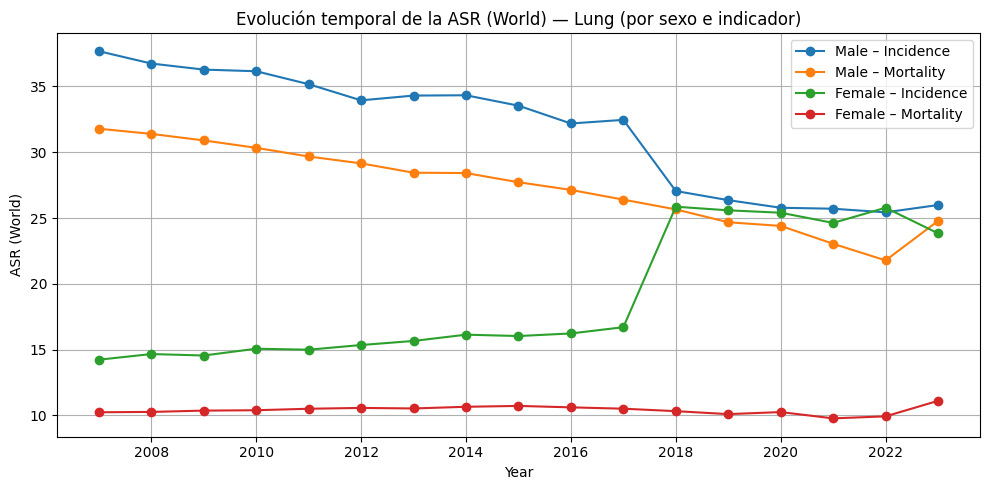

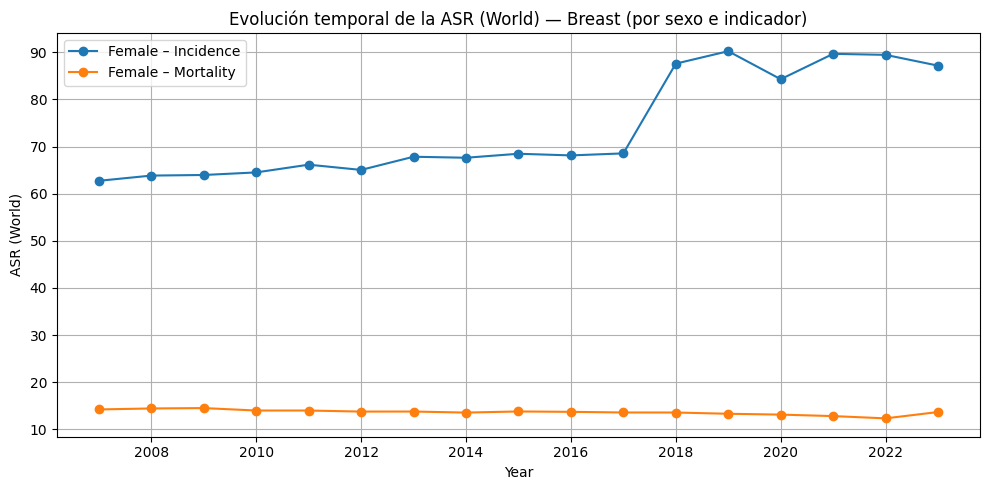

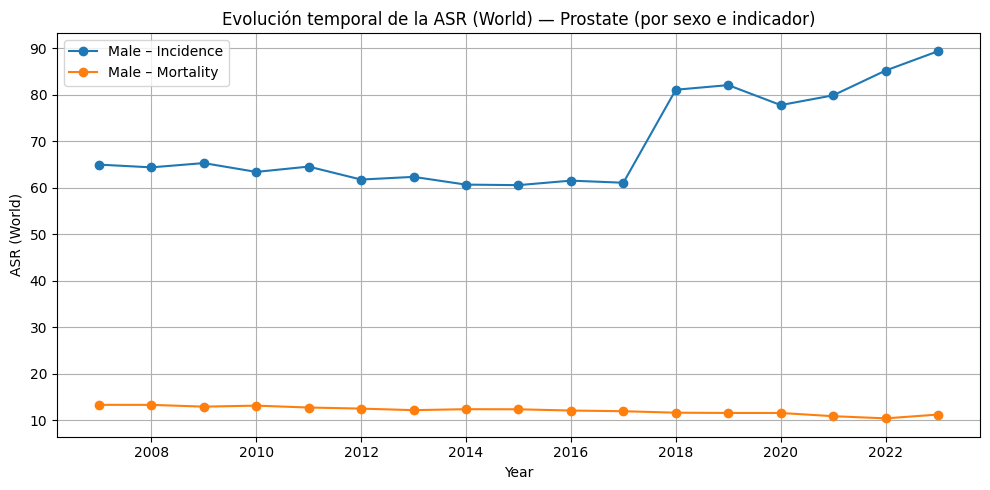

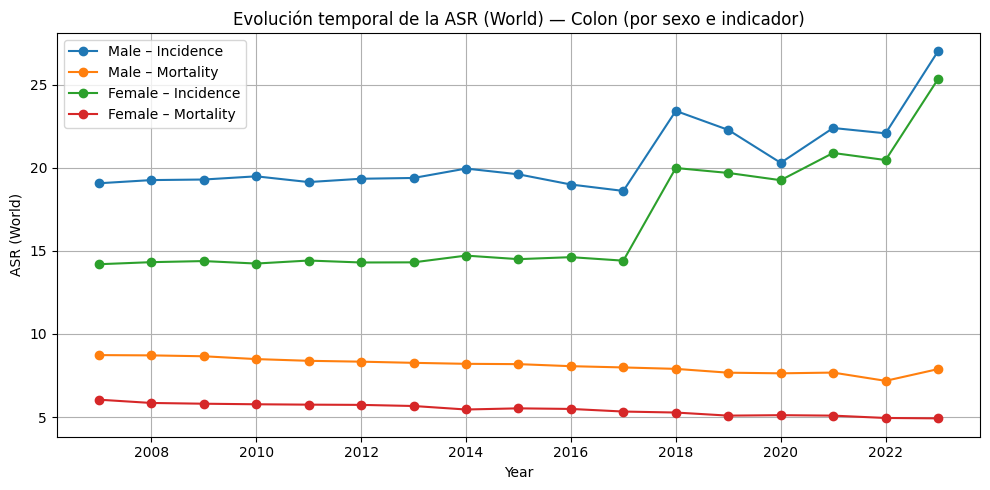

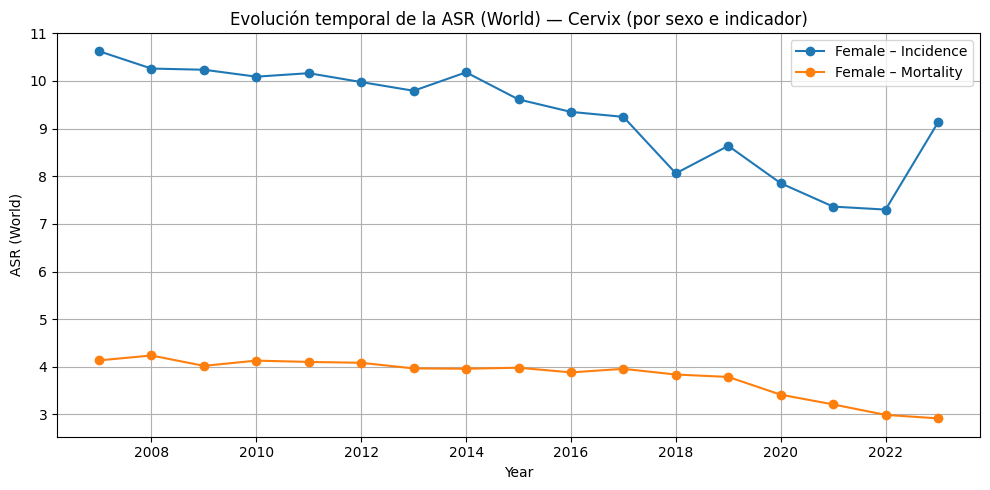

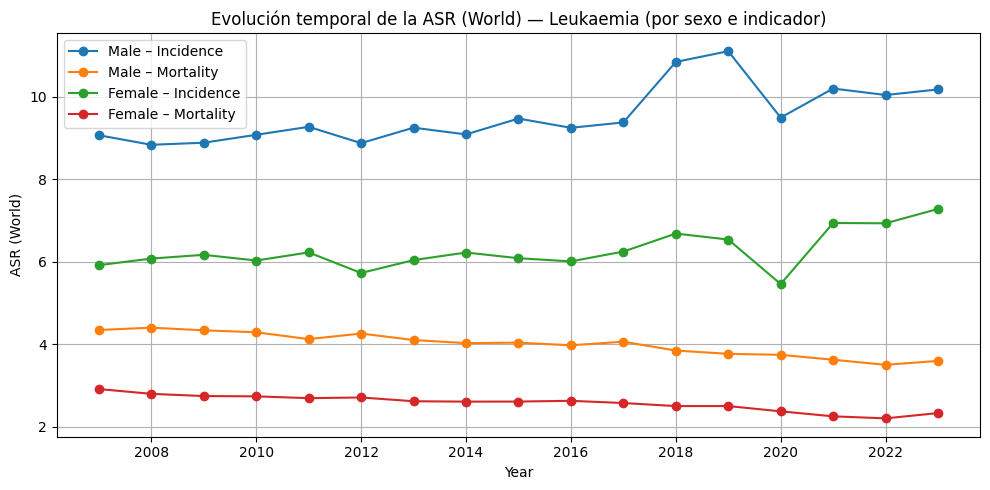

In [7]:
# 1) Preparar tendencia: ahora agrupamos también por Cancer label
df_trend_cancer = (
    df_merged
    .dropna(subset=["Year", "ASR (World)", "Sex", "Type", "Cancer label"])
    .groupby(["Cancer label", "Year", "Sex", "Type"], as_index=False)
    .agg({"ASR (World)": "mean"})
    .sort_values(["Cancer label", "Year"])
)

# (opcional) orden de cánceres para que salga consistente
orden_cancer = ["Lung", "Breast", "Prostate", "Colon", "Cervix", "Leukaemia"]
cancers = [c for c in orden_cancer if c in df_trend_cancer["Cancer label"].unique()]
# si hubiera otros, los añadimos al final
cancers += [c for c in df_trend_cancer["Cancer label"].unique() if c not in cancers]

# 2) Graficar una figura por cáncer
os.makedirs(fig_dir, exist_ok=True)

for cancer in cancers:
    df_c = df_trend_cancer[df_trend_cancer["Cancer label"] == cancer]

    plt.figure(figsize=(10, 5))

    for sex in ["Male", "Female"]:
        for t in ["Incidence", "Mortality"]:
            sub = df_c[(df_c["Sex"] == sex) & (df_c["Type"] == t)].sort_values("Year")

            # Si no hay datos para esa combinación, saltamos
            if sub.empty:
                continue

            plt.plot(
                sub["Year"],
                sub["ASR (World)"],
                marker="o",
                label=f"{sex} – {t}"
            )

    plt.xlabel("Year")
    plt.ylabel("ASR (World)")
    plt.title(f"Evolución temporal de la ASR (World) — {cancer} (por sexo e indicador)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # nombre de archivo seguro
    cancer_safe = str(cancer).replace(" ", "_").replace("/", "_")
    plt.savefig(f"{fig_dir}/fig_ASR_anno_{cancer_safe}.jpg", dpi=300, bbox_inches="tight")
    plt.show()


En la serie temporal se observa un incremento aparente de las tasas a partir de 2017, que no debe interpretarse como un aumento abrupto de la incidencia real del cáncer. Este comportamiento coincide con actualizaciones metodológicas introducidas por GLOBOCAN, así como con mejoras en los sistemas de diagnóstico y registro en numerosos países, lo que puede generar discontinuidades en las series temporales.


El análisis principal se centró en la incidencia del cáncer, utilizando tasas estandarizadas por edad (ASR World), y se realizó de forma separada por sexo con el fin de preservar las diferencias epidemiológicas observadas entre hombres y mujeres.

A partir del análisis exploratorio visual, se podría seleccionar el  año 2022 como periodo de referencia, al tratarse del año más reciente y menos afectado por las distorsiones observadas durante la pandemia de COVID-19. Sin embargo, primeramente se debe ver si merece la pena usar ese año o usar otro.

Debido a la diferencia sistemática de los resultados por sexo, se realizarán los análisis por separado






In [8]:
idx = (
    df_merged
    .groupby(["Country_harmonized", "Sex", "Type"])["Year"]
    .idxmax()
)

df_latest = df_merged.loc[idx].reset_index(drop=True)


<Figure size 1000x500 with 0 Axes>

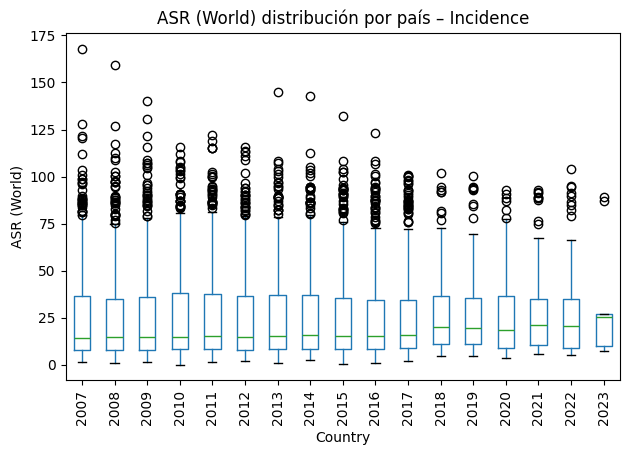

<Figure size 1000x500 with 0 Axes>

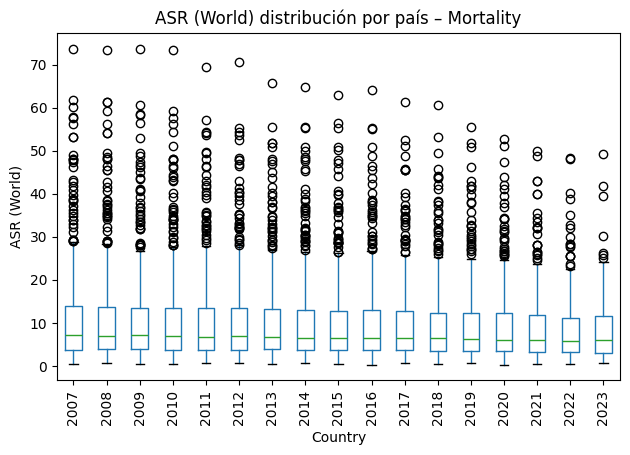

                count       mean        std       min        25%        50%  \
Type      Year                                                                
Incidence 2007  405.0  26.496955  27.061120  1.261740   7.711630  14.335122   
          2008  405.0  26.484531  26.921488  0.848776   7.867851  14.703023   
          2009  405.0  26.561125  26.975834  1.208534   7.830014  14.779456   
          2010  405.0  26.449069  26.151303  0.000000   8.150444  14.803445   
          2011  405.0  26.674141  26.647533  1.267041   8.105718  15.332491   
          2012  405.0  26.033010  25.685634  1.733681   7.755090  14.821352   
          2013  405.0  26.545398  26.114810  0.830335   8.200118  15.193336   
          2014  405.0  26.545148  25.622500  2.286980   8.357070  15.690939   
          2015  405.0  26.429636  25.744768  0.559190   8.486948  15.283628   
          2016  396.0  26.252235  25.744940  1.125282   8.380160  14.995394   
          2017  378.0  26.295706  25.434506  1.90925

In [9]:
df_plot = df_merged.copy()


for t in df_plot["Type"].unique():
    plt.figure(figsize=(10,5))

    df_plot[df_plot["Type"] == t].boxplot(
        column="ASR (World)",
        by="Year",
        grid=False,
        rot=90
    )

    plt.title(f"ASR (World) distribución por país – {t}")
    plt.suptitle("")
    plt.xlabel("Country")
    plt.ylabel("ASR (World)")
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/fig02_boxplot_ASR_{t}.jpg", dpi=300, bbox_inches="tight")
    plt.show()

stats_simple = (
    df_plot
    .groupby(["Type", "Year"])["ASR (World)"]
    .describe()
)

print(stats_simple)



Estas figuras muestran la distribución de las tasas de incidencia y mortalidad estandarizadas por edad (ASR World) para el periodo 2007–2023 mediante diagramas de caja y bigotes. En ambos casos se observa una elevada heterogeneidad entre países, reflejada en amplios rangos intercuartílicos y la presencia sistemática de valores atípicos. La incidencia presenta una mayor dispersión que la mortalidad, lo que pone de manifiesto su mayor sensibilidad a factores como el diagnóstico precoz y la calidad de los registros. Por el contrario, la mortalidad muestra una distribución más estable y concentrada, lo que sugiere una mayor dependencia de la capacidad terapéutica de los sistemas sanitarios. Estas observaciones refuerzan la pertinencia de un análisis transversal por país y la utilización de la mortalidad como variable principal, complementada por la incidencia.

Para continuar con el análisis estadístico y valorar que año y paises utilizar en nuestro trabajo, se busca entonces valorar que paises tienen los datos de incidencia y/o mortalidad y tomar la decisión cual será la variable objetivo.



In [10]:
#cuantos paises hay con año, tipo de cancer y tipo

counts = (
    df_merged
    .groupby(
        ["Country_harmonized", "Year", "Cancer label", "Type"]
    )
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

 # cuantos países tienen los datos completos (both) o incompletos?

counts["both"] = (
    (counts.get("Incidence", 0) > 0) &
    (counts.get("Mortality", 0) > 0)
)

counts["only_incidence"] = (
    (counts.get("Incidence", 0) > 0) &
    (counts.get("Mortality", 0) == 0)
)

counts["only_mortality"] = (
    (counts.get("Incidence", 0) == 0) &
    (counts.get("Mortality", 0) > 0)
)

summary = {
    "Total combinaciones país–año–cáncer": len(counts),
    "Con incidencia y mortalidad": counts["both"].sum(),
    "Solo incidencia": counts["only_incidence"].sum(),
    "Solo mortalidad": counts["only_mortality"].sum(),
}
print(
    f"Total combinaciones país–año–cáncer: {summary['Total combinaciones país–año–cáncer']}\n"
    f"Con incidencia y mortalidad: {summary['Con incidencia y mortalidad']}\n"
    f"Solo incidencia: {summary['Solo incidencia']}\n"
    f"Solo mortalidad: {summary['Solo mortalidad']}"
)


#Un resumen por año

by_year = (
    counts
    .groupby("Year")[["both", "only_incidence", "only_mortality"]]
    .sum()
)

print(by_year)

#resumen por pais

by_country = (
    counts
    .groupby("Country_harmonized")[["both", "only_incidence", "only_mortality"]]
    .sum()
    .sort_values("both")
)





Total combinaciones país–año–cáncer: 6366
Con incidencia y mortalidad: 2370
Solo incidencia: 732
Solo mortalidad: 3264
Type  both  only_incidence  only_mortality
Year                                      
2007   210              60             156
2008   210              60             156
2009   210              60             156
2010   210              60             156
2011   210              60             156
2012   210              60             156
2013   210              60             156
2014   210              60             156
2015   210              60             156
2016   204              60             162
2017   186              66             168
2018    18              12             336
2019    18              12             330
2020    18              12             300
2021    18              12             276
2022    18              12             210
2023     0               6              78


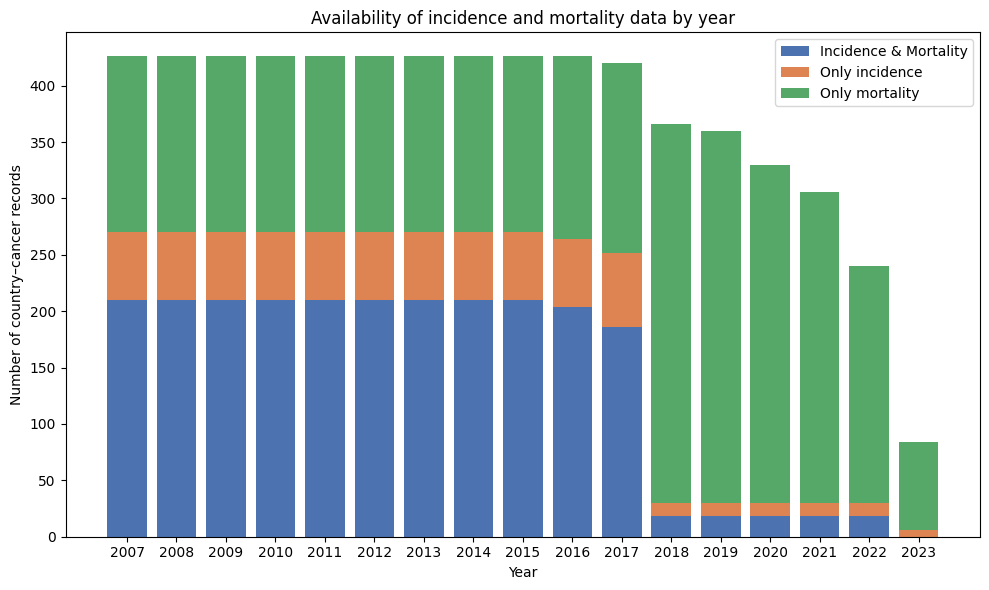

In [11]:
plt.figure(figsize=(10, 6))

plt.bar(
    by_year.index,
    by_year["both"],
    label="Incidence & Mortality",
    color="#4C72B0"
)

plt.bar(
    by_year.index,
    by_year["only_incidence"],
    bottom=by_year["both"],
    label="Only incidence",
    color="#DD8452"
)

plt.bar(
    by_year.index,
    by_year["only_mortality"],
    bottom=by_year["both"] + by_year["only_incidence"],
    label="Only mortality",
    color="#55A868"
)

plt.xlabel("Year")
plt.ylabel("Number of country–cancer records")
plt.title("Availability of incidence and mortality data by year")
plt.legend()
plt.tight_layout()
plt.xticks(by_year.index.astype(int))


plt.show()


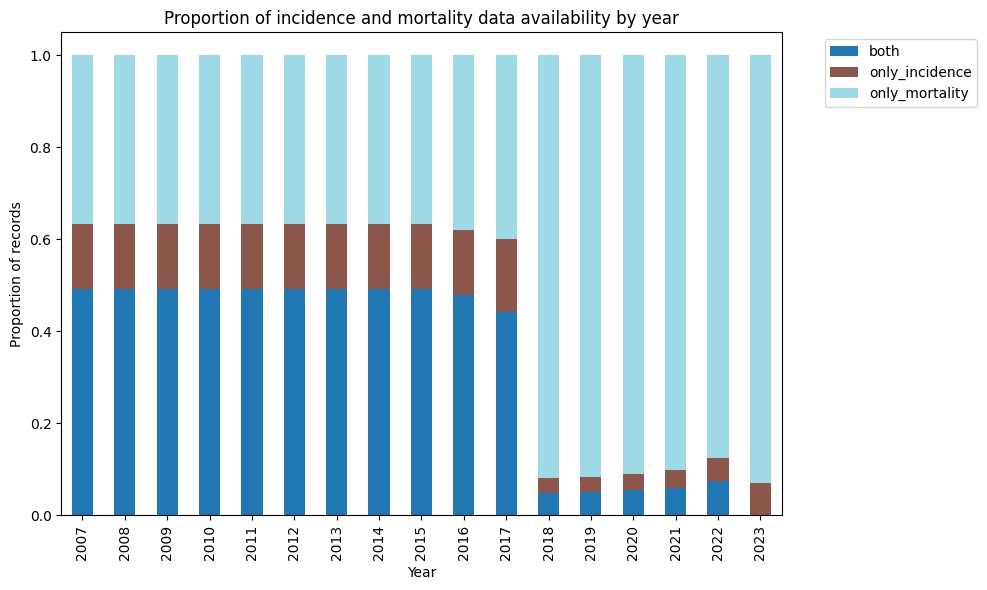

In [12]:
by_year_pct = by_year.div(by_year.sum(axis=1), axis=0)

by_year_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    colormap="tab20"
)

plt.xlabel("Year")
plt.ylabel("Proportion of records")
plt.title("Proportion of incidence and mortality data availability by year")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


Se observó una reducción generalizada en el número de países con datos disponibles a partir de 2018 para todos los tipos de cáncer analizados. Este cambio de cobertura limita la comparabilidad temporal de las medias anuales posteriores a dicho año, por lo que los análisis longitudinales se interpretan con cautela y se prioriza el uso de años con alta cobertura, concretamente 2016 y 2022.

Antes de integrar los datos de infraestructura, se realizó un análisis exploratorio de la disponibilidad de registros de incidencia y mortalidad por país, año y tipo de cáncer. Este análisis permitió identificar combinaciones incompletas y justificar la restricción posterior a observaciones con información simultánea de ambos indicadores. Para ver mejor los datos, se grafican para analizar si merece la pena continuar con datos donde aparezcan incidencia y mortalidad o dejamos solamente mortalidad.

Apartir de 2017, los datos de incidencia presentan una cobertura insuficiente y no homogénea entre países y cánceres, lo que compromete cualquier análisis comparativo robusto. Por el contrario, la mortalidad mantiene una cobertura amplia y consistente a lo largo del tiempo, convirtiéndose en la variable más fiable para el análisis global.

En base a la evolución temporal de la disponibilidad de datos, el análisis principal del estudio se centra en la mortalidad por cáncer, que presenta una cobertura amplia y consistente en todos los años analizados. La incidencia se utiliza únicamente de forma exploratoria en el periodo 2007–2016, donde la disponibilidad conjunta de ambos indicadores permite análisis comparativos robustos. A partir de 2017, la incidencia queda excluida del análisis principal debido a su escasa representatividad.

El análisis exploratorio de la cobertura geográfica por año mostró una estabilidad de datos incidencia y mortalidad elevada hasta 2016, seguida de una reducción progresiva en los años más recientes. Por este motivo, se busca además la cantidad de datos que se tienen por mortalidad compartiendo o no incidencia al mismo tiempo.
Esta estrategia permite evaluar la robustez de los resultados y analizar posibles cambios temporales sin comprometer la representatividad.

In [13]:
#Esto por ahora no aporta nada

df_mort_f = df_plot[(df_plot["Type"] == "Mortality") & (df_plot["Sex"] == "Female")]

top5_worst_f = (
    df_mort_f
    .sort_values(["Year", "ASR (World)"], ascending=[True, False])
    .groupby("Year")
    .head(5)
    .reset_index(drop=True)
)

#print(top5_worst_f)


top5_best_f = (
    df_mort_f
    .sort_values(["Year", "ASR (World)"], ascending=[True, True])
    .groupby("Year")
    .head(5)
    .reset_index(drop=True)
)
#print(top5_best_f)

df_mort_m = df_plot[(df_plot["Type"] == "Mortality") & (df_plot["Sex"] == "Male")]


top5_worst_m = (
    df_mort_m
    .sort_values(["Year", "ASR (World)"], ascending=[True, False])
    .groupby("Year")
    .head(5)
    .reset_index(drop=True)
)

#print(top5_worst_m)


top5_best_m = (
    df_mort_m
    .sort_values(["Year", "ASR (World)"], ascending=[True, True])
    .groupby("Year")
    .head(5)
    .reset_index(drop=True)
)

#print(top5_best_m)

In [14]:
# Ahora los extremos, mujer
summary_extremes_f = (
    df_mort_f
    .groupby("Year")
    .apply(lambda x: pd.DataFrame({
        "Worst_country": x.sort_values("ASR (World)", ascending=False)
                           .head(5)["Country_harmonized"].values,
        "Worst_cancer": x.sort_values("ASR (World)", ascending=False)
                          .head(5)["Cancer label"].values,
        "Worst_ASR": x.sort_values("ASR (World)", ascending=False)
                       .head(5)["ASR (World)"].values,
        "Best_country": x.sort_values("ASR (World)")
                          .head(5)["Country_harmonized"].values,
        "Best_cancer": x.sort_values("ASR (World)")
                         .head(5)["Cancer label"].values,
        "Best_ASR": x.sort_values("ASR (World)")
                      .head(5)["ASR (World)"].values
    }))
)


#print(summary_extremes_f)

summary_extremes_m = (
    df_mort_m
    .groupby("Year")
    .apply(lambda x: pd.DataFrame({
        "Worst_country": x.sort_values("ASR (World)", ascending=False)
                           .head(5)["Country_harmonized"].values,
        "Worst_cancer": x.sort_values("ASR (World)", ascending=False)
                          .head(5)["Cancer label"].values,
        "Worst_ASR": x.sort_values("ASR (World)", ascending=False)
                       .head(5)["ASR (World)"].values,
        "Best_country": x.sort_values("ASR (World)")
                          .head(5)["Country_harmonized"].values,
        "Best_cancer": x.sort_values("ASR (World)")
                         .head(5)["Cancer label"].values,
        "Best_ASR": x.sort_values("ASR (World)")
                      .head(5)["ASR (World)"].values
    }))
)

#print(summary_extremes_m)

/tmp/ipython-input-1707666129.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.DataFrame({
/tmp/ipython-input-1707666129.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.DataFrame({


In [15]:
  #calcula las medias de mortalidd tanto de hombres como mujeres
mean_mort_m_by_year = (
    df_mort_m
    .groupby("Year")["ASR (World)"]
    .mean()
)


mean_mort_f_by_year = (
    df_mort_f
    .groupby("Year")["ASR (World)"]
    .mean()
)




#calculas los mejores paises con baja/alta mortalidad segun sexo

top5_best_16_22_m = (
    df_mort_m[df_mort_m["Year"].isin([2016, 2022])].copy()
    .sort_values("ASR (World)", ascending=True)
    .groupby("Year", group_keys=False)
    .head(5)
    .reset_index(drop=True)
)

top5_worst_16_22_m = (
    df_mort_m[df_mort_m["Year"].isin([2016, 2022])].copy()
    .sort_values("ASR (World)", ascending=False)
    .groupby("Year", group_keys=False)
    .head(5)
    .reset_index(drop=True)
)

top5_best_16_22_f = (
    df_mort_f[df_mort_f["Year"].isin([2016, 2022])].copy()
    .sort_values("ASR (World)", ascending=True)
    .groupby("Year", group_keys=False)
    .head(5)
    .reset_index(drop=True)
)

top5_worst_16_22_f = (
    df_mort_f[df_mort_f["Year"].isin([2016, 2022])].copy()
    .sort_values("ASR (World)", ascending=False)
    .groupby("Year", group_keys=False)
    .head(5)
    .reset_index(drop=True)
)



In [16]:
def plot_top5_by_sex_same_height(df_m, df_f, year, title_prefix, fig_dir=None, fname=None):


    # Ordenar ambos por severidad (de menor a mayor para que el peor quede arriba)
    df_m = df_m.sort_values("ASR (World)", ascending=True).reset_index(drop=True)
    df_f = df_f.sort_values("ASR (World)", ascending=True).reset_index(drop=True)


    # Etiquetas por sexo
    labels_m = df_m["Country_harmonized"] + " (" + df_m["Cancer label"] + ")"
    labels_f = df_f["Country_harmonized"] + " (" + df_f["Cancer label"] + ")"

    # Posiciones comunes
    y = np.arange(len(df_m))  # Top 5 → 0..4

    fig, ax = plt.subplots(figsize=(10, 6))

    # HOMBRES (izquierda)
    ax.barh(
        y,
        -df_m["ASR (World)"],
        color="#003f5c",
        height=0.6,
        label="Men"
    )

    # MUJERES (derecha)
    ax.barh(
        y,
        df_f["ASR (World)"],
        color="#F4A6C1",
        height=0.6,
        label="Women"
    )

    # Línea central
    ax.axvline(0, color="black", linewidth=1)
    #dibujar los verticales de las medias por sexo
      # Línea media hombres (izquierda, negativa)
    ax.axvline(
      -mean_mort_m_by_year.loc[year],
      color="#003f5c",
      linestyle="--",
      linewidth=2,
      alpha=0.8,
      label=f"Mean men: {mean_mort_m_by_year[year]:.2f}"
  )

# Línea media mujeres (derecha, positiva)
    ax.axvline(
      mean_mort_f_by_year.loc[year],
      color="#F4A6C1",
      linestyle="--",
      linewidth=2,
      alpha=0.8,
      label=f"Mean women: {mean_mort_f_by_year.loc[year]:.2f}"
  )


    # Eje Y izquierdo → hombres
    ax.set_yticks(y)
    ax.set_yticklabels(labels_m)

    # Eje Y derecho → mujeres
    ax_r = ax.twinx()
    ax_r.set_yticks(y)
    ax_r.set_yticklabels(labels_f)
    ax_r.set_ylim(ax.get_ylim())

    # Escalas y títulos
    max_val = max(
        df_m["ASR (World)"].max(),
        df_f["ASR (World)"].max()
    ) * 1.2

    ax.set_xlim(-max_val, max_val)
    ax.set_xlabel("Mortality ASR (World)")
    ax.set_title(f"{title_prefix} – {year} (Top 5 per sex)")
    ax.legend(loc="lower right")

    plt.tight_layout()
    if fig_dir and fname:
        plt.savefig(f"{fig_dir}/{fname}", dpi=300, bbox_inches="tight")
    plt.show()

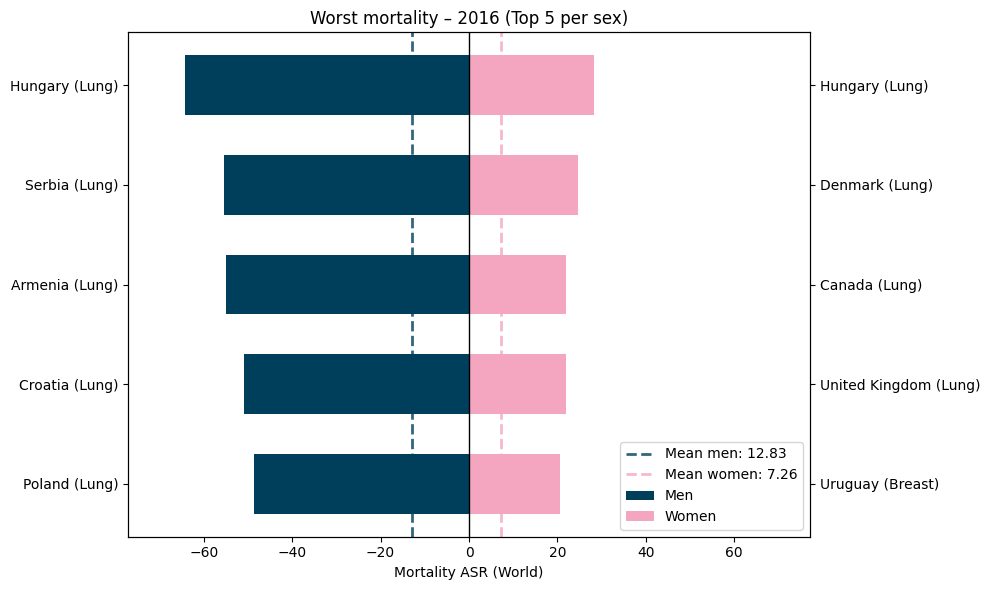

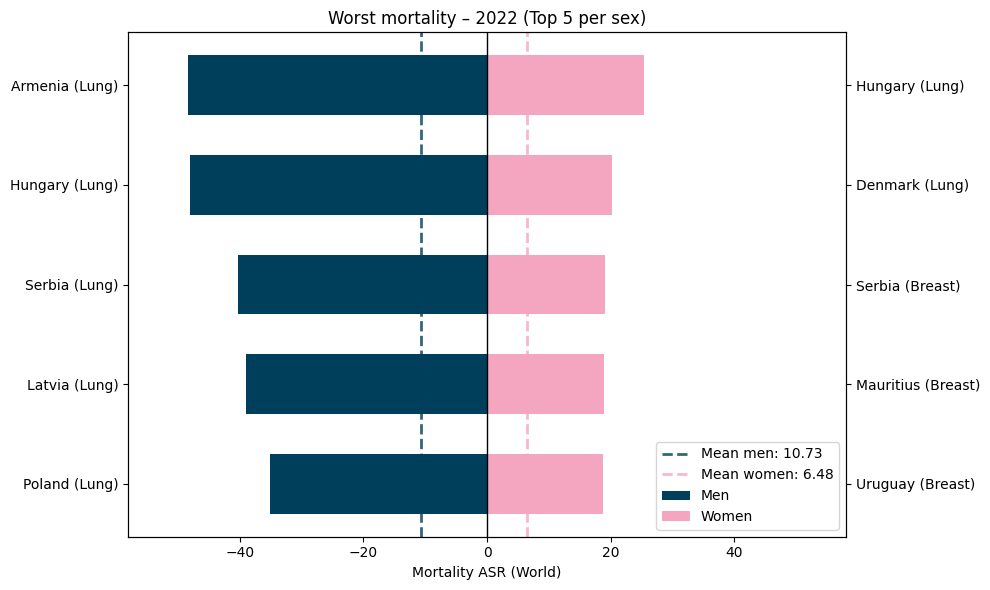

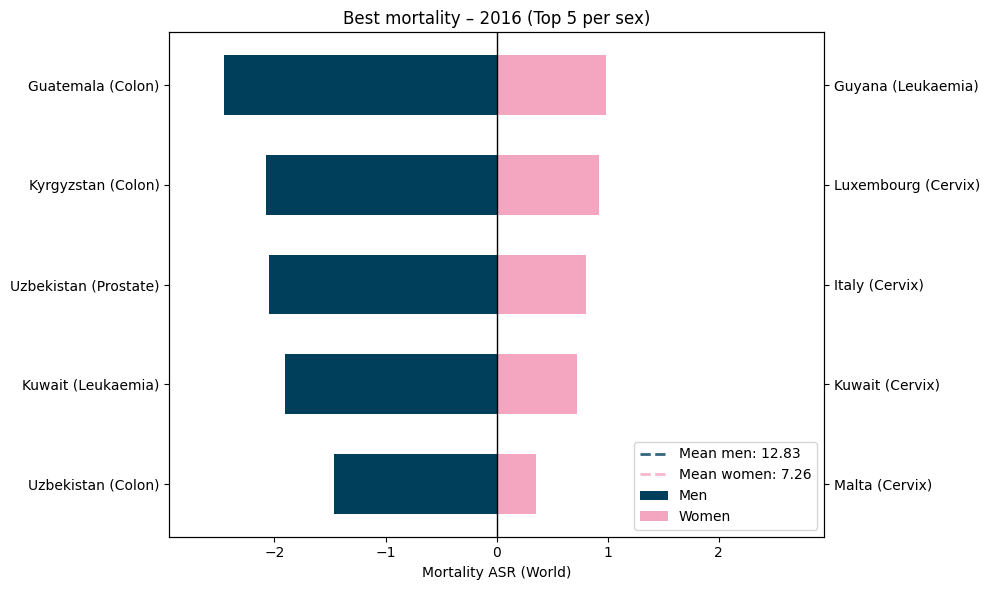

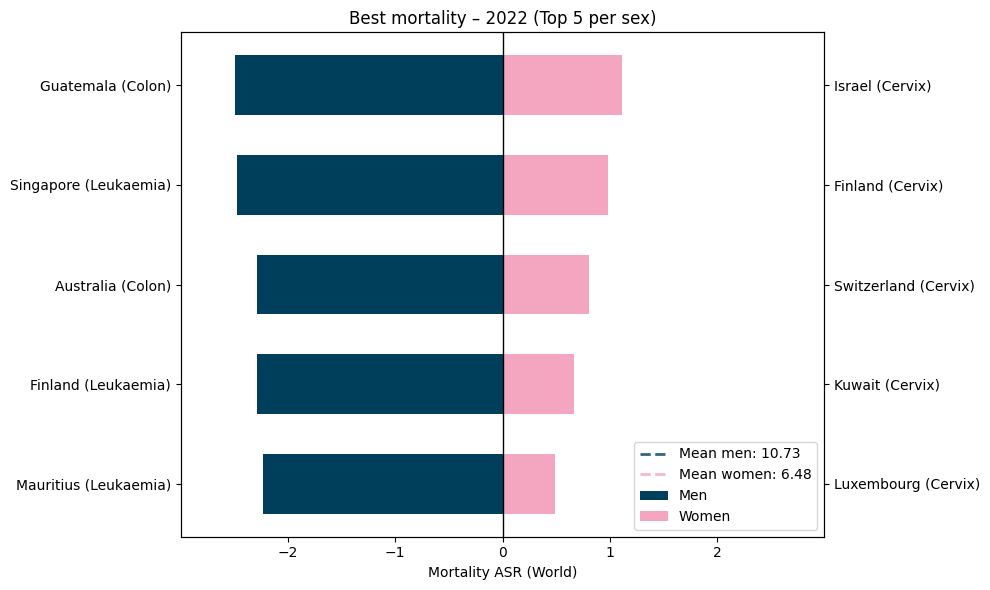

In [17]:
#Para los peores resultados en mortalidad

for year in [2016, 2022]:
    df_m = top5_worst_16_22_m[top5_worst_16_22_m["Year"] == year].head(5)
    df_f = top5_worst_16_22_f[top5_worst_16_22_f["Year"] == year].head(5)

    plot_top5_by_sex_same_height(
        df_m, df_f, year,
        title_prefix="Worst mortality",
        fig_dir=fig_dir,
        fname=f"worst_mortality_top5_by_sex_{year}.jpg"
    )

#par los mejores resultados en mortalidad
for year in [2016, 2022]:
    df_m = top5_best_16_22_m[top5_best_16_22_m["Year"] == year].head(5)
    df_f = top5_best_16_22_f[top5_best_16_22_f["Year"] == year].head(5)

    plot_top5_by_sex_same_height(
        df_m, df_f, year,
        title_prefix="Best mortality",
        fig_dir=fig_dir,
        fname=f"best_mortality_top5_by_sex_{year}.jpg"
    )



La mortalidad media se calculó de forma independiente para cada año y sexo, evitando mezclar periodos temporales con distinta cobertura y garantizando la comparabilidad entre 2016 y 2022.

Las líneas discontinuas representan la mortalidad media (ASR World) de los  países registrado para los años 2016 y 2022. Se observa que la mortalidad media masculina es sistemáticamente superior a la femenina, tanto en magnitud como en dispersión, lo que refuerza la necesidad de realizar análisis estratificados por sexo.

Para saber hasta donde llegan nuestro alcance con los datos si se consideran tanto incidencia como mortalidad, graficamos el número de países registrados por año

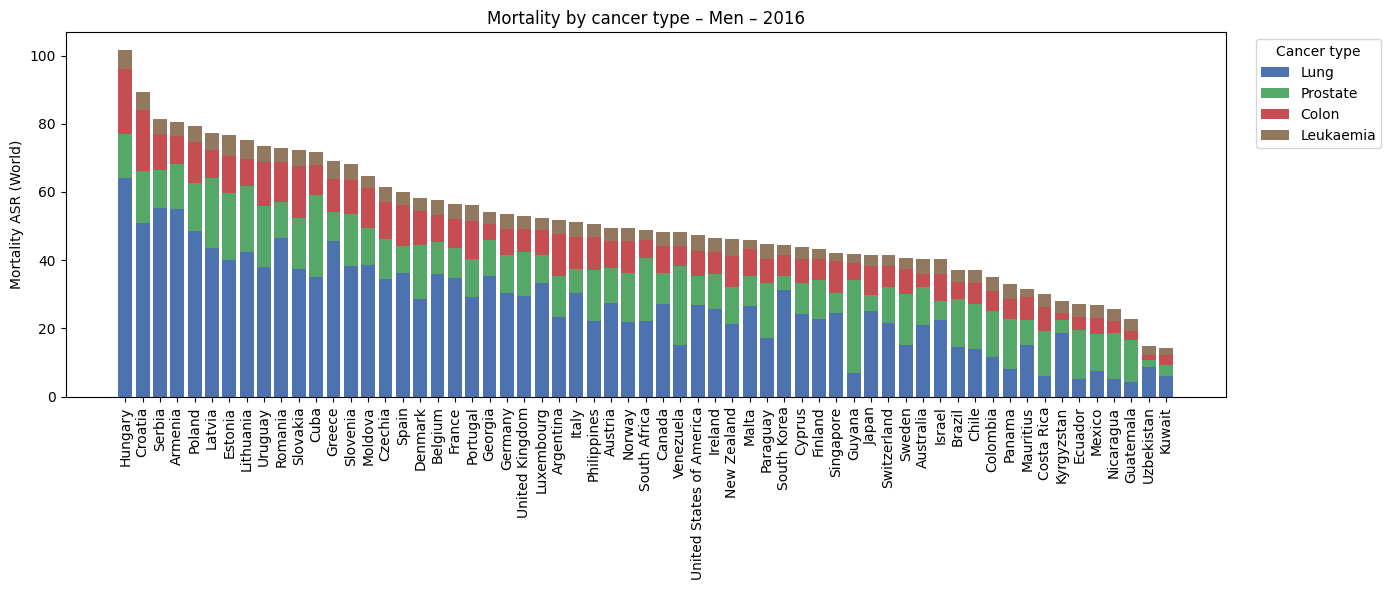

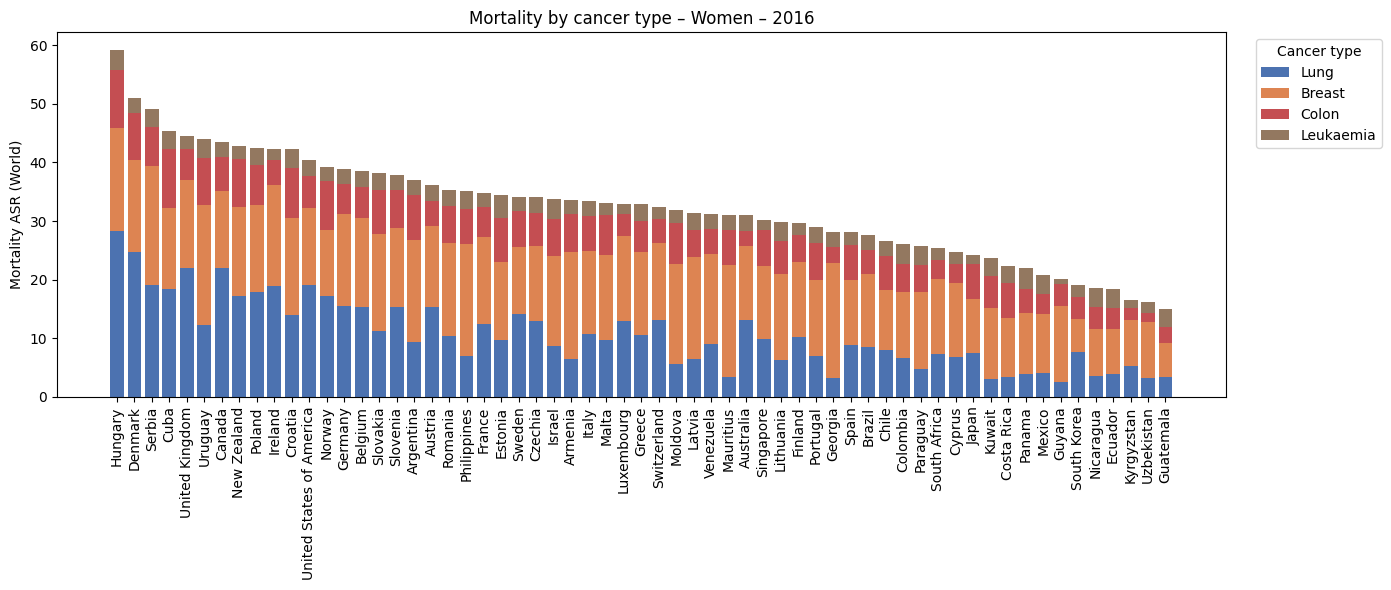

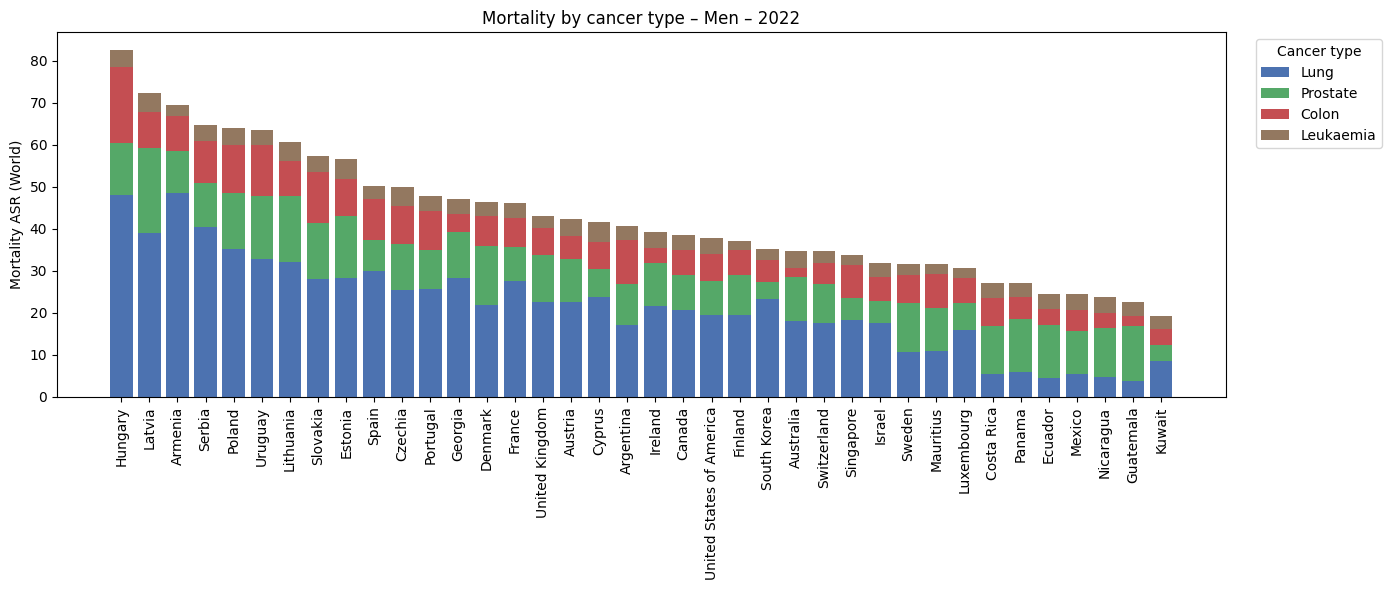

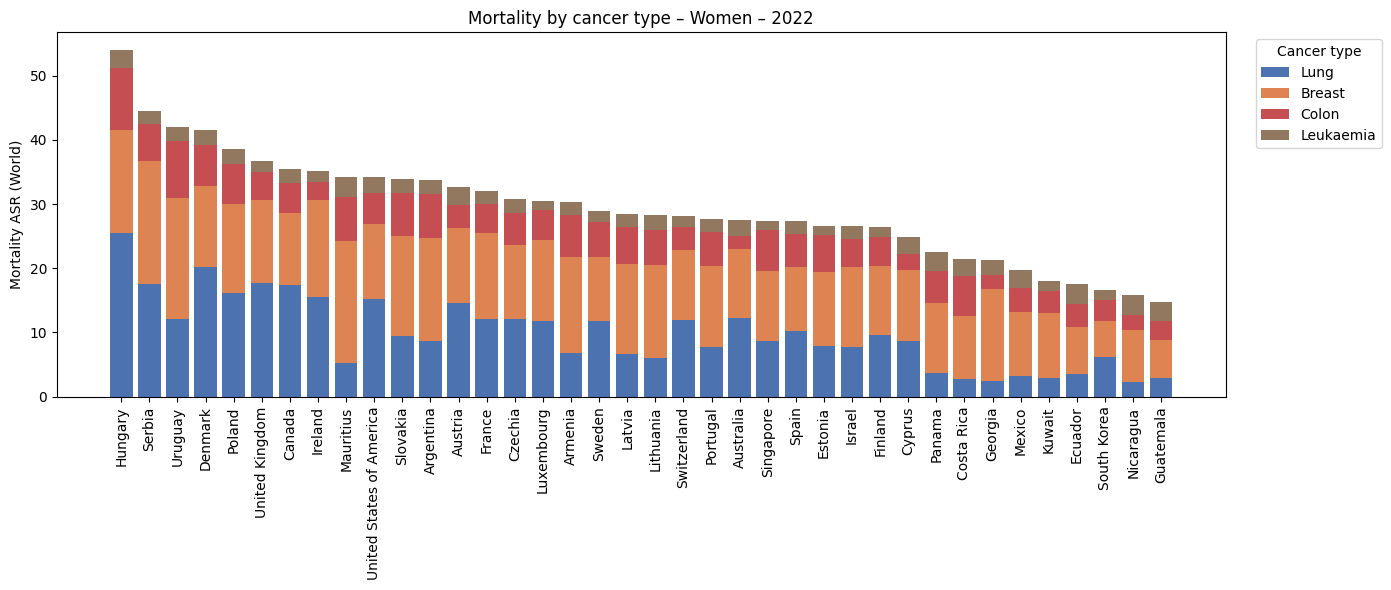

In [18]:
#cada tipo de cancer, un color distinto

cancer_colors = {
    "Lung": "#4C72B0",        # azul
    "Breast": "#DD8452",      # naranja
    "Prostate": "#55A868",    # verde
    "Colon": "#C44E52",       # rojo
    "Cervix uteri": "#8172B2",# morado
    "Leukaemia": "#937860"    # marrón
}

#Preparar por año y sexo la mortalidad para agrupar por pais y tipo de cancer
def prepare_stacked_mortality_by_sex(df, year, sex):
    df_y = df[
        (df["Year"] == year) &
        (df["Type"] == "Mortality") &
        (df["Sex"] == sex)
    ].copy()

    agg = (
        df_y
        .groupby(["Country_harmonized", "Cancer label"], as_index=False)
        .agg({"ASR (World)": "mean"})
    )

    return agg


def pivot_stacked(df_agg):
    pivot = df_agg.pivot(
        index="Country_harmonized",
        columns="Cancer label",
        values="ASR (World)"
    ).fillna(0)

    return pivot

#función para graficar las barras por país la mortalidad
def plot_stacked_mortality_by_sex(pivot, year, sex_label, fig_dir=None):
    plt.figure(figsize=(14, 6))

    bottom = np.zeros(len(pivot))

    for cancer in pivot.columns:
        plt.bar(
            pivot.index,
            pivot[cancer],
            bottom=bottom,
            label=cancer,
            color=cancer_colors[cancer] # Use cancer to get color dynamically
        )
        bottom += pivot[cancer].values

    plt.xticks(rotation=90)
    plt.ylabel("Mortality ASR (World)")
    plt.title(f"Mortality by cancer type – {sex_label} – {year}")
    plt.legend(title="Cancer type", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    if fig_dir:
        plt.savefig(
            f"{fig_dir}/stacked_mortality_{sex_label}_{year}.jpg",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()



# 2016

#Para hombres
mort_2016_m = prepare_stacked_mortality_by_sex(df_merged, 2016, "Male")



pivot_2016_m_full = pivot_stacked(mort_2016_m)
existing_cancer_keys_m = [key for key in cancer_colors.keys() if key in pivot_2016_m_full.columns]
pivot_2016_m = pivot_2016_m_full[existing_cancer_keys_m]

pivot_2016_m = pivot_2016_m.loc[
    pivot_2016_m.sum(axis=1).sort_values(ascending=False).index
]

#para mujeres
mort_2016_f = prepare_stacked_mortality_by_sex(df_merged, 2016, "Female")
pivot_2016_f_full = pivot_stacked(mort_2016_f)
existing_cancer_keys_f = [key for key in cancer_colors.keys() if key in pivot_2016_f_full.columns]
pivot_2016_f = pivot_2016_f_full[existing_cancer_keys_f]

pivot_2016_f = pivot_2016_f.loc[
    pivot_2016_f.sum(axis=1).sort_values(ascending=False).index
]


plot_stacked_mortality_by_sex(
    pivot_2016_m,
    2016,
    "Men",
    fig_dir
)

plot_stacked_mortality_by_sex(
    pivot_2016_f,
    2016,
    "Women",
    fig_dir
)

# 2022
#graficar para hombres
mort_2022_m = prepare_stacked_mortality_by_sex(df_merged, 2022, "Male")

pivot_2022_m_full = pivot_stacked(mort_2022_m)
existing_cancer_keys_m_2022 = [key for key in cancer_colors.keys() if key in pivot_2022_m_full.columns]
pivot_2022_m = pivot_2022_m_full[existing_cancer_keys_m_2022]

pivot_2022_m = pivot_2022_m.loc[
    pivot_2022_m.sum(axis=1).sort_values(ascending=False).index
]

#graficar Para mujeres
mort_2022_f = prepare_stacked_mortality_by_sex(df_merged, 2022, "Female")
pivot_2022_f_full = pivot_stacked(mort_2022_f)
existing_cancer_keys_f_2022 = [key for key in cancer_colors.keys() if key in pivot_2022_f_full.columns]
pivot_2022_f = pivot_2022_f_full[existing_cancer_keys_f_2022]

pivot_2022_f = pivot_2022_f.loc[
    pivot_2022_f.sum(axis=1).sort_values(ascending=False).index
]


plot_stacked_mortality_by_sex(
    pivot_2022_m,
    2022,
    "Men",
    fig_dir
)

plot_stacked_mortality_by_sex(
    pivot_2022_f,
    2022,
    "Women",
    fig_dir
)

In [19]:
df_merged.head()

,Cancer label,Sex,Type,Year,ASR (World),Crude rate,Cumulative risk,Total,Country_harmonized,RTCenters,Linac,Protontherapy,XRay,Brachytherapy,Last Update,Region Name,Population,Population_male,Population_female,GDP_per_capita
0,Lung,Male,Incidence,2007,61.434111,80.958928,7.865065,3666,Belarus,13,31,0,11,17,2024,Eastern Europe,9563133.0,4450421.0,5112713.0,4735.481076
1,Lung,Male,Incidence,2008,62.729974,84.930604,8.033257,3765,Belarus,13,31,0,11,17,2024,Eastern Europe,9529358.0,4432534.0,5096824.0,6376.175692
2,Lung,Male,Incidence,2009,61.098990,84.106229,7.731976,3719,Belarus,13,31,0,11,17,2024,Eastern Europe,9507337.0,4421224.0,5086114.0,5352.488092
3,Lung,Male,Incidence,2010,62.582334,86.376743,7.914747,3812,Belarus,13,31,0,11,17,2024,Eastern Europe,9490752.0,4412608.0,5078144.0,6034.678852
4,Lung,Male,Incidence,2011,59.755001,83.234410,7.621488,3665,Belarus,13,31,0,11,17,2024,Eastern Europe,9472735.0,4402539.0,5070196.0,6527.659343


In [20]:
df_2016 = df_merged[df_merged["Year"] == 2016]
df_2022 = df_merged[df_merged["Year"] == 2022]

print("El numero de paises registrados en el 2016:", df_2016["Country_harmonized"].nunique())
print("El número de países registrados en el 2022:" , df_2022["Country_harmonized"].nunique())

df_22 = df_merged[df_merged["Year"] == 2022].copy()
#se guarda en un cvs
df_22.to_csv("df_22.csv", index=False)


El numero de paises registrados en el 2016: 71
El número de países registrados en el 2022: 40


Para poder continuar con el análisis, es importante asegurarse de que exista en cada fila incidencias y mortalidad para poder así graficarlo correctamente, por lo tanto, lo primero que se hará es limpiar esta información, para evitar estos valores perdidos, se guardarán solamente los que tengan ambos

In [21]:
complete_keys = (
    df_merged
    .groupby(["Country_harmonized", "Year", "Sex"])["Type"]
    .nunique()
    .reset_index()
    .query("Type == 2")
)


df_complete = df_merged.merge(
    complete_keys[["Country_harmonized", "Year", "Sex"]],
    on=["Country_harmonized", "Year", "Sex"],
    how="inner"
)
#Ahora solo contiene observaciones donde existen ambos tipos.

def build_pivot(df):
    df_scatter = (
        df
        .groupby(
            ["Country_harmonized", "Year", "Type"],
            as_index=False
        )
        .agg({"ASR (World)": "mean"})
    )

    pivot = (
        df_scatter
        .pivot_table(
            index=["Country_harmonized", "Year"],
            columns="Type",
            values="ASR (World)"
        )
        .reset_index()
    )

    return pivot

pivot_male = build_pivot(df_male)
pivot_female = build_pivot(df_female)
pivot_all = build_pivot(df_complete)

pivot_male_clean = pivot_male.dropna(subset=["Incidence", "Mortality"])
pivot_female_clean = pivot_female.dropna(subset=["Incidence", "Mortality"])


print("Male:", pivot_male_clean.shape)
print("Female:", pivot_female_clean.shape)

print(
    "Male - países:",
    pivot_male_clean["Country_harmonized"].nunique()
)

print(
    "Female - países:",
    pivot_female_clean["Country_harmonized"].nunique()
)


Male: (395, 4)
Female: (395, 4)
Male - países: 35
Female - países: 35


El análisis de la relación entre incidencia y mortalidad se restringió a aquellas combinaciones país–año–sexo con información disponible para ambos indicadores. Esta restricción reduce el tamaño muestral, pero garantiza la coherencia del análisis bivariado, evitando inferencias basadas en información incompleta.

Haciendo un bozquejo de lo que se ha estado encontrando, se ve claramente que la mortalidad de hombres en algunos países hasta casi dobla en números con respecto a mujeres, habrá que ver por tipo de cáncer (los que afectan exclusivamente a hombres y los que afectan a las mujeres) ocasiona esta disparidad.

Los datos se transformaron a formato ancho mediante una tabla pivote, separando explícitamente la incidencia y la mortalidad en columnas independientes para cada combinación de país, año y sexo, lo que permitió el hint: análisis de su relación mediante correlación y regresión.


Ahora se puede calcular tanto la correlación de Pearson como, la pendiente de la curva, en el caso de ver claramente una tendencia.

In [22]:
def compute_beta_R(df):
    x = df["Incidence"].values
    y = df["Mortality"].values

    beta, alpha = np.polyfit(x, y, 1)
    R = np.corrcoef(x, y)[0, 1]

    return beta, alpha, R

beta_f, alpha_f, R_f = compute_beta_R(pivot_female_clean)
beta_m,  alpha_m,  R_m  = compute_beta_R(pivot_male_clean)
beta_all, alpha_all, R_all = compute_beta_R(pivot_all)

print(f"Female  -> beta={beta_f:.3f}, alpha={alpha_f:.3f}, R={R_f:.3f}, N={len(pivot_female_clean)}")
print(pivot_female_clean.head())

print(f"Male    -> beta={beta_m:.3f},  alpha={alpha_m:.3f},  R={R_m:.3f},  N={len(pivot_male_clean)}")
print(pivot_male_clean.head())

print(f"All    -> beta={beta_all:.3f},  alpha={alpha_all:.3f},  R={R_all:.3f},  N={len(pivot_all)}")
print(pivot_all.head())

Female  -> beta=0.184, alpha=3.073, R=0.609, N=395
Type Country_harmonized  Year  Incidence  Mortality
0             Argentina  2007  21.105817   8.274651
1             Argentina  2008  24.109715   8.117734
2             Argentina  2009  22.862996   8.199053
3             Argentina  2010  22.665475   8.070498
4             Argentina  2011  22.181812   7.995091
Male    -> beta=0.259,  alpha=4.947,  R=0.596,  N=395
Type Country_harmonized  Year  Incidence  Mortality
0             Argentina  2007  22.999171  15.479395
1             Argentina  2008  21.814043  15.000062
2             Argentina  2009  24.982291  14.555391
3             Argentina  2010  22.635477  14.400345
4             Argentina  2011  23.059037  14.122212
All    -> beta=0.207,  alpha=4.393,  R=0.547,  N=395
Type Country_harmonized  Year  Incidence  Mortality
0             Argentina  2007  21.947307  11.476759
1             Argentina  2008  23.089416  11.176546
2             Argentina  2009  23.804905  11.024092
3         

Tras la estratificación por sexo y la exigencia de disponibilidad simultánea de datos de incidencia y mortalidad, el análisis se restringe a un subconjunto de 36 países. Este subconjunto es común a hombres y mujeres, lo que permite realizar comparaciones directas entre sexos sin introducir sesgos derivados de diferencias en la cobertura geográfica.

La relación entre incidencia y mortalidad es más pronunciada en hombres que en mujeres, mientras que en mujeres la relación es más consistente y menos dispersa. El análisis agregado por sexo reduce la calidad del ajuste y oculta estas diferencias, lo que justifica plenamente la estratificación por sexo en los análisis posteriores.


Al estratificar el análisis por sexo, se observan diferencias claras en la relación entre incidencia y mortalidad. En hombres, la pendiente del modelo es mayor, lo que indica un incremento más acusado de la mortalidad a medida que aumenta la incidencia. En mujeres, la relación es menos pronunciada pero más consistente, reflejada en un coeficiente de correlación superior. Por el contrario, el análisis agregado por sexo presenta una menor capacidad explicativa, lo que evidencia que la agregación de ambos sexos introduce heterogeneidad y enmascara patrones relevantes





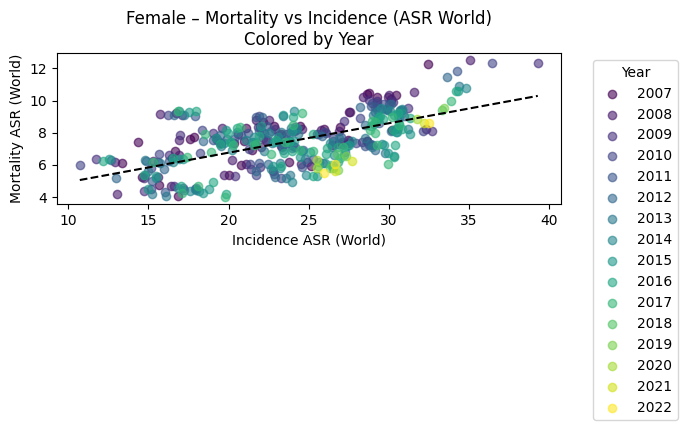

In [23]:
# cálculo de la recta en mujeres
plt.figure(figsize=(7, 7))

years = sorted(pivot_female_clean["Year"].unique())
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(years)))

for y, c in zip(years, colors):
    df_y = pivot_female_clean[pivot_female_clean["Year"] == y]

    plt.scatter(
        df_y["Incidence"],
        df_y["Mortality"],
        alpha=0.6,
        color=c,
        label=str(y)
    )

# Recta global (
x_f = pivot_female_clean["Incidence"].values
y_f = pivot_female_clean["Mortality"].values
beta_f, alpha_f = np.polyfit(x_f, y_f, 1)

x_line = np.linspace(x_f.min(), x_f.max(), 200)
plt.plot(x_line, beta_f * x_line + alpha_f, linestyle="--", color="black")

plt.xlabel("Incidence ASR (World)")
plt.ylabel("Mortality ASR (World)")
plt.title("Female – Mortality vs Incidence (ASR World)\nColored by Year")

plt.legend(
    title="Year",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.gca().set_aspect("equal", adjustable="box")
plt.grid(False)
plt.tight_layout()
plt.show()



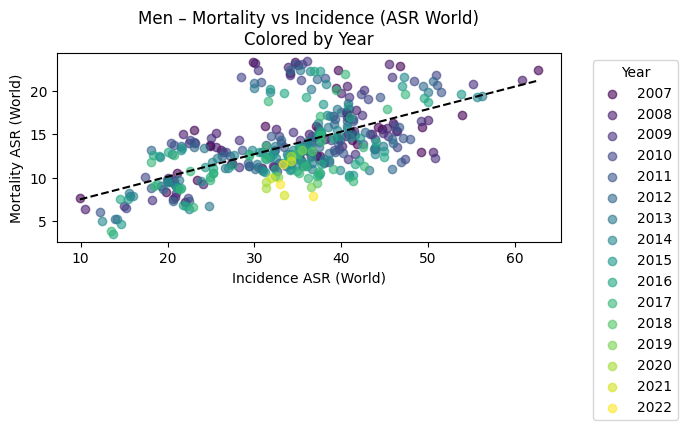

In [24]:
#hombres
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7, 7))

years = sorted(pivot_male_clean["Year"].unique())
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(years)))

for y, c in zip(years, colors):
    df_y = pivot_male_clean[pivot_male_clean["Year"] == y]

    plt.scatter(
        df_y["Incidence"],
        df_y["Mortality"],
        alpha=0.6,
        color=c,
        label=str(y)
    )

# Recta global
x_m = pivot_male_clean["Incidence"].values
y_m = pivot_male_clean["Mortality"].values
beta_m, alpha_m = np.polyfit(x_m, y_m, 1)

x_line = np.linspace(x_m.min(), x_m.max(), 200)
plt.plot(x_line, beta_m * x_line + alpha_m, linestyle="--", color="black")

plt.xlabel("Incidence ASR (World)")
plt.ylabel("Mortality ASR (World)")
plt.title("Men – Mortality vs Incidence (ASR World)\nColored by Year")

plt.legend(
    title="Year",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.gca().set_aspect("equal", adjustable="box")
plt.grid(False)
plt.tight_layout()
plt.show()



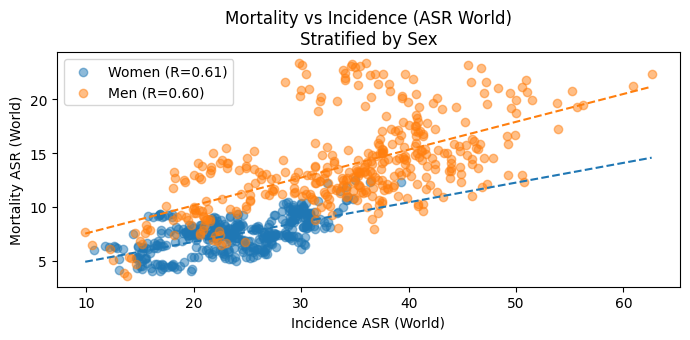

In [25]:
plt.figure(figsize=(7, 7))

plt.scatter(
    x_f, y_f,
    alpha=0.5,
    label=f"Women (R={R_f:.2f})"
)

plt.scatter(
    x_m, y_m,
    alpha=0.5,
    label=f"Men (R={R_m:.2f})"
)

# rectas
x_min = min(x_f.min(), x_m.min())
x_max = max(x_f.max(), x_m.max())
x_line = np.linspace(x_min, x_max, 200)

plt.plot(x_line, beta_f * x_line + alpha_f, linestyle="--")
plt.plot(x_line, beta_m * x_line + alpha_m, linestyle="--")

plt.xlabel("Incidence ASR (World)")
plt.ylabel("Mortality ASR (World)")
plt.title("Mortality vs Incidence (ASR World)\nStratified by Sex")

plt.legend()
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(False)
plt.tight_layout()
plt.show()


Las representaciones gráficas de incidencia frente a mortalidad muestran patrones claramente diferenciados por sexo. En hombres, la pendiente es mayor y la dispersión más elevada, lo que indica un aumento más acusado de la mortalidad con la incidencia. En mujeres, la relación es más moderada y consistente, la mortalidad crece más lentamente con la incidencia. La superposición de ambos sexos evidencia que el análisis agregado oculta estas diferencias estructurales, justificando la estratificación por sexo adoptada en este estudio.

La mayor pendiente y correlación observadas en hombres sugieren una relación más fuerte entre incidencia y mortalidad, lo que podría estar relacionado con diferencias en tipos de cáncer predominantes, factores de riesgo y acceso al diagnóstico precoz.



In [26]:
#Creación de tabla
male_tab = pivot_male_clean.copy()
male_tab["Sex"] = "Male"

female_tab = pivot_female_clean.copy()
female_tab["Sex"] = "Female"

#unirlas
tab_sex = pd.concat([male_tab, female_tab], ignore_index=True)

#reunir por año y sexo
table_year_sex = (
    tab_sex
    .groupby(["Year", "Sex"], as_index=False)
    .agg({
        "Incidence": "mean",
        "Mortality": "mean"
    })
)

table_year_sex


table_year_sex_n = (
    tab_sex
    .groupby(["Year", "Sex"])
    .agg(
        Incidence_mean=("Incidence", "mean"),
        Mortality_mean=("Mortality", "mean"),
        N_countries=("Country_harmonized", "nunique")
    )
    .reset_index()
)

table_year_sex_n



table_wide = table_year_sex_n.pivot(
    index="Year",
    columns="Sex",
    values=["Incidence_mean", "Mortality_mean", "N_countries"]
)

table_wide



Incidence_mean            Mortality_mean            N_countries      
Sex          Female       Male         Female       Male      Female  Male
Year                                                                      
2007      22.957069  35.719077       7.785539  15.319651        35.0  35.0
2008      23.230595  35.213016       7.744246  15.106716        35.0  35.0
2009      23.257645  35.619436       7.669180  14.703307        35.0  35.0
2010      23.449095  34.785683       7.627605  14.557902        35.0  35.0
2011      23.827802  34.939991       7.547607  14.216407        35.0  35.0
2012      23.424347  33.454656       7.508182  13.963847        35.0  35.0
2013      24.042726  33.814635       7.345541  13.530861        35.0  35.0
2014      24.316393  33.267302       7.251474  13.329339        35.0  35.0
2015      24.294356  33.152564       7.262936  13.059781        35.0  35.0
2016      24.202656  32.920748       7.307731  12.744160        34.0  34.0
2017      24.080175  32.578674       7.249940  12.659498        31.0  31.0
2018      28.775624  35.381639       7.296816  10.933713         3.0   3.0
2019      29.189614  34.897561       7.253780  10.733314         3.0   3.0
2020      27.608674  32.284985       6.967152  10.281527         3.0   3.0
2021      28.833261  33.174032       6.824616   9.993179         3.0   3.0
2022      28.345842  34.331277       6.710525   9.582967         3.0   3.0

Esta tabla muestran los paises que tienen tanto mortalidad como incidencia simultaneamente. Se puede ver que el diagnostico en mujeres ha aumentado mientras que en hombres permanece mas o menos igual. Las muertes han disminuidos para ambos sexos pero se ve claramente que en hombres, el índice es superior.

Los períodos más robustos están desde el 2007 hasta el 2017.

Dado que los niveles absolutos de incidencia y mortalidad difieren sustancialmente entre sexos, el uso de valores agregados ocultaría patrones epidemiológicos relevantes y sesgaría la interpretación de la relación incidencia–mortalidad.




Justificación del uso de la mortalidad como variable de resultado (2016–2022)

Con el objetivo de garantizar la comparabilidad temporal y maximizar la cobertura geográfica del análisis, se evaluó la disponibilidad de datos de incidencia y mortalidad para los años 2016 y 2022, que constituyen los dos puntos temporales de referencia en este estudio.

El año 2016 representa el último periodo en el que una proporción sustancial de países dispone simultáneamente de datos de incidencia y mortalidad, permitiendo una caracterización relativamente completa de ambos indicadores. Sin embargo, en 2022 se observa un cambio estructural muy marcado en la disponibilidad de los datos: la mayoría de los registros país–cáncer corresponden exclusivamente a mortalidad, mientras que los datos de incidencia están disponibles únicamente para un número reducido de países.

Este contraste implica que el uso de la incidencia, o de modelos que requieran simultáneamente incidencia y mortalidad, conduciría en 2022 a una reducción drástica del tamaño muestral y a un sesgo hacia países con sistemas de registro oncológico más desarrollados. En cambio, la mortalidad mantiene una cobertura geográfica amplia y homogénea en ambos años, permitiendo una comparación consistente entre países y a lo largo del tiempo.

Dado que el objetivo del trabajo es analizar la relación entre los resultados en cáncer y la disponibilidad de infraestructuras de radioterapia, se selecciona la mortalidad como variable principal de resultado para los análisis comparativos entre 2016 y 2022. Esta elección permite maximizar el número de países incluidos, garantizar la coherencia temporal del análisis y centrarse en un desenlace clínico final estrechamente vinculado al acceso y la efectividad de los tratamientos oncológicos.

###Conexión directa con lo que viene (DIRAC)

A partir de esta evaluación, los análisis posteriores se centran exclusivamente en la mortalidad por cáncer, que se relaciona con la disponibilidad de infraestructura de radioterapia (DIRAC) y se ajusta por población.

Ahora, se construye el primer scatter con indice de mortalidad vs centros de radioterapia existentes. Para esto, es necesario normalizar la infraestructura por población, es decir, RT centers y equipos por millón de habitantes.

In [27]:
df_merged_all = df_merged.copy()
df_merged_all = df_merged_all[df_merged_all["Type"] == "Mortality"].copy()
df_merged_all = (
    df_merged_all[
        df_merged_all["Year"].isin([2016, 2022])
    ]
    .copy()
)
df_merged_all = df_merged_all[
    df_merged_all["Cancer label"] != "Leukaemia"
].copy()

df_merged_all["Year"].value_counts().sort_index()

,count
Year,
2016,427
2022,266


La leucemia se excluye del análisis dado que su manejo clínico no depende principalmente de infraestructuras de radioterapia, sino de tratamientos sistémicos como quimioterapia y terapias dirigidas. Su inclusión podría introducir ruido y sesgos en el estudio de la relación entre mortalidad y disponibilidad de radioterapia.

In [28]:
# 1. Renombrar columnas correctamente
rt_vars = ["RTCenters", "Linac", "Protontherapy", "XRay", "Brachytherapy"]

for var in rt_vars:
    df_merged_all[f"{var}_m"] = (
        df_merged_all[var] / df_merged_all["Population"]
    ) * 1_000_000

# 2. Calcular LINACs necesarios SIN duplicar por sexo
linacs_needed = (
    df_merged_all
    .groupby(['Country_harmonized', 'Year'], as_index=False)
    .agg({'Population': 'first', 'Linac': 'first'})
)

linacs_needed['rt_linac_needed'] = linacs_needed['Population'] / 250_000
linacs_needed['rt_deficit'] = (
    linacs_needed['rt_linac_needed'] - linacs_needed['Linac']
)
linacs_needed['coverage_index'] = (
    linacs_needed['Linac'] / linacs_needed['rt_linac_needed']
) * 100

df_merged_all = df_merged_all.merge(
    linacs_needed[['Country_harmonized', 'Year', 'rt_linac_needed',
                   'rt_deficit', 'coverage_index']],
    on=['Country_harmonized', 'Year'],
    how='left'
)

# 3. Guardar dataset limpio
df_merged_all.to_csv("df_merged_clean.csv", index=False)

In [29]:
# Guardar CSV reducido
df_merged_all.to_csv(
    "merged_all.csv",
    index=False
)

In [30]:

df_merged_all.head()

,Cancer label,Sex,Type,Year,ASR (World),Crude rate,Cumulative risk,Total,Country_harmonized,RTCenters,...,Population_female,GDP_per_capita,RTCenters_m,Linac_m,Protontherapy_m,XRay_m,Brachytherapy_m,rt_linac_needed,rt_deficit,coverage_index
0,Lung,Male,Mortality,2016,27.122063,58.122336,3.095859,10481,Canada,52,...,18320689.0,42314.061582,1.430405,8.142305,0.0,0.385109,1.430405,145.413372,-150.586628,203.557621
1,Lung,Male,Mortality,2022,20.689747,50.979249,2.350679,9830,Canada,52,...,19538904.0,56256.800726,1.339472,7.624688,0.0,0.360627,1.339472,155.285036,-140.714964,190.617208
2,Lung,Female,Mortality,2016,22.005901,52.345194,2.648721,9590,Canada,52,...,18320689.0,42314.061582,1.430405,8.142305,0.0,0.385109,1.430405,145.413372,-150.586628,203.557621
3,Lung,Female,Mortality,2022,17.433952,47.704826,2.065611,9321,Canada,52,...,19538904.0,56256.800726,1.339472,7.624688,0.0,0.360627,1.339472,155.285036,-140.714964,190.617208
4,Lung,Male,Mortality,2016,14.024196,20.636850,1.770362,1875,Chile,24,...,9181532.0,13649.852045,1.313829,2.463429,0.0,0.000000,0.437943,73.068884,28.068884,61.585722


In [31]:
df_merged_all["Cancer label"].unique()

array(['Lung', 'Breast', 'Prostate', 'Colon', 'Cervix'], dtype=object)

Los diagramas de dispersión que relacionan la mortalidad por cáncer con la disponibilidad de radioterapia por millón de habitantes para los años 2016 y 2022 no muestran una asociación lineal clara. Los valores de mortalidad presentan una elevada dispersión a lo largo de todo el rango de disponibilidad de infraestructura, lo que sugiere que la capacidad en radioterapia, por sí sola, no es suficiente para explicar las diferencias observadas en la mortalidad por cáncer entre países. Este resultado es coherente con la naturaleza multifactorial de los resultados en cáncer, que dependen no solo de la capacidad de tratamiento, sino también de factores como la detección precoz, el rendimiento del sistema sanitario, el acceso efectivo a la atención y los factores de riesgo a nivel poblacional.


Los datos del año 2022 son insuficientes limitando la robustez y por lo tanto no se dará el peso inferencial aunque se observa un patrón similar al global.

La relación entre incidencia y mortalidad se exploró mediante diagramas de dispersión basados en ASR World, donde cada punto representa un país, año y sexo. Esta gráfica nos muestra una tendencia lineal entre incidencia y mortalidad, y se ha resaltado los años que se desean estudiar por si tienen algún patrón distinto al resto, lo que sugiere que es tiene un comportamiento similar al resto de años, por lo tanto, son buenos candidatos para el estudio que haremos más delante.

# definimos el primer modelo base

el primer modelo relaciona mortalidad con centros de rt por millón de habitantes, no se promedia nada entre secos ni tipo de cancer, ya que cada uno tiene un comportamiento distinto, si se mexclan podría diluir las relaciones reales.
Primer modelo lineal:

In [32]:
#definimos el primer modelo

df_model = df_merged_all[
    (df_merged_all["Year"].isin([2016, 2022])) &
    (df_merged_all["Type"] == "Mortality")
].copy()



In [33]:
#dispersión por sexo y cancer
def scatter_by_sex_cancer_year(
    df, cancer, sex, rt_var_pm, years=[2016, 2022]
):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for ax, year in zip(axes, years):
        df_y = df[
            (df["Cancer label"] == cancer) &
            (df["Sex"] == sex) &
            (df["Year"] == year)
        ]

        ax.scatter(
            df_y[rt_var_pm],
            df_y["ASR (World)"],
            alpha=0.7
        )

        ax.set_title(f"{year}")
        ax.set_xlabel(
            rt_var_pm.replace("_m", "")
            + "\n(per million inhabitants)"
        )

    axes[0].set_ylabel("Mortality ASR (World)")
    plt.suptitle(f"{cancer} – {sex}")
    plt.tight_layout()
    plt.show()

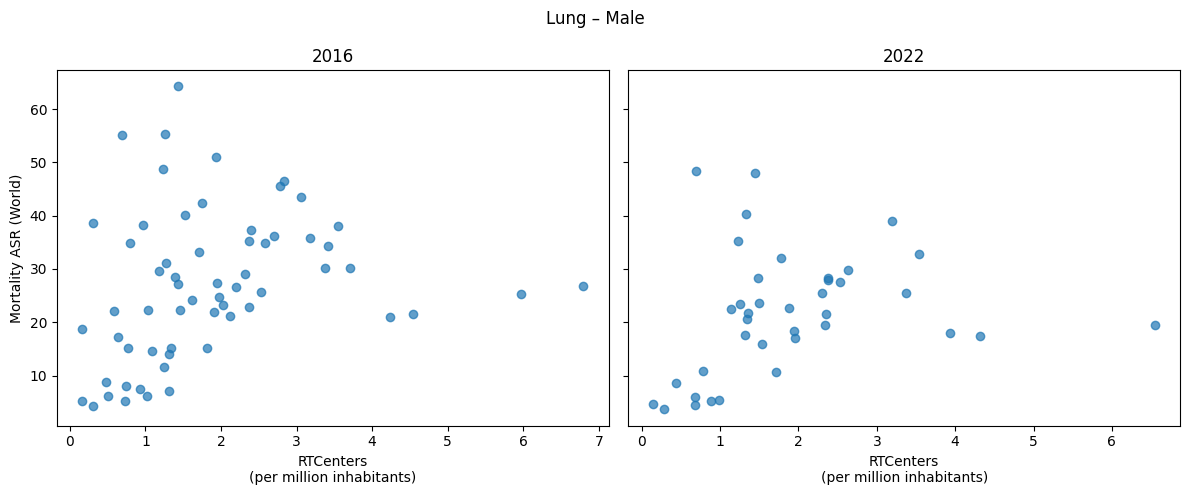

In [34]:
scatter_by_sex_cancer_year(
    df_model,
    cancer="Lung",
    sex="Male",
    rt_var_pm="RTCenters_m" # Corrected to 'RTCenters_m'
)

Con estos resultados se muestra que la infraestructura por si sola no explica la mortalidad entre países. El modelo resultante solamente explica el 0.4% de la variabilidad de la mortalidad.

In [35]:
df_analysis = df_merged[
    (df_merged["Year"] == 2019) &
    (df_merged["Type"] == "Incidence")
].copy()

df_analysis.shape

(45, 20)

## Descripción inicial de los datos
Vamos a hacer una descripción inicial de los datos


## Variable objetivo: creditability

 La variable **creditability** es la *calidad crediticia* de  cada cliente, es la variable a predecir. Toma originalmente dos valores (Buen Cliente y Mal Clioente). Esta es la variable objetivo, la variable evento

## Variables Predictoras o explicativas

Las 20 restantes variables del data frame (7 numéricas y 13 categóricas) son los atributos o características observadas de esos clientes que se utilizarán para predecir la probabilidad de que los clientes cometan un impago de sis créditos, esto es, de que sean malos clientes. La descripción de estas 20 variables es la siguiente:


## Analisis univariante y de asociación con la variable objetivo

Que comprobar en el análisis descriptivo inicial?

### **Análisis univariante**

1- **Tipos de variables**. Todas las variables categóricas (factores) están bien identificadas?


Para el análisis univariante es importante realizar un análisis gráfico con el **Histograma de Frecuencias**

2- **Límites de las variables cuantitativas** Valores numéricos fuera de rango ¿Hay alguna limitación sobre el rango de alguna variable que no se cumpla?

3- **Niveles de las variables cualitativas**, Valores mal codificados ¿los niveles de las variables cualitativas tienen sentido? ¿Hay missings no declarados tipo -1, 99999? Las categorías de las nominales son las que deben?

4- **Variables nominales o categóricas o factores con categorías minoritarias**.Frecuencia de las categorías de las variables cualitativas.  Las categorías con baja representación puede causar muchos problemas en los modelos por falta de base muestral para la estimación de los parámetros correspondientes a la pertenencia a esa categoría. Por ello, es conveniente echar un vistazo y recodificar las vairables uniendo categorías muy poco representativas con otras cuya unión tenga algún sentido (tienen comportamiento similar frente a la objetivo, la variable tiene caracter ordinal por lo que la unión con mayor sentido sería hacia categorías adyacentes..).  Es imprescindible que todas los niveles de las variables cualitativas esten ´ bien representados pues, de lo contrario, se podr´ıan detectar patrones que no fueran extrapolables al estar basados en muy pocas observaciones.
 Por ello, se debe verificar que la frecuencia de todas ellas sea superior al 2-5 % (el porcentaje exacto depende del numero de observaciones del conjunto de datos) Yo prefiero que haya variabilidad suficiente: NO debe haber categorías con menos de un 5% de representación).

5 **Variabilidad suficiente de las variables numéricas** Por encima de un 5% de valores distintos


Con estas cosas ya arregladas, nos vamos a los dos grandes "caballos de batalla" de la depuración.

5- **Outliers**. Incidencia y tratamiento (pasar a missing, eliminar, winsorizar o reemplazarlos con los valores no atípicos más cercanos)

**Análisis de las variables/casos ausentes**


6- **Missings**. Incidencia y tratamiento
  - **Imputación** por valores validos (0-5%):  simple por media, mediana, aleatorio, imputación por modelos
  - **Recategorizacion** (5%- 50%) de los valores missing como una categoría valida.
  - **Eliminar** columnas u observaciones (superior al 50 %) Cuando en una variable hay mas de la mitad de los datos faltantes, es recomendable rechazarla al inicio del proceso, pues carece de suficiente informacion.
  

### **Análisis Bivariante**
**Después del análisis Univariante se realiza el Análisis Bivariante, entre cada una de las potenciales variables explicativas y la Variable objetivo**

a. Tablas de contigencia Chi2 (¿discretizar variables continuas V de Cramer o Chi2 dnormalizado entre 0 y 1,, independientes y totalmente dependientes respectivamente))
b. Tablas de correlaciones
c. Tablas Pivote (test de diferencia de medias)

c) Métodos gráficos:
  - Gráficos de dispersión
  - Diagrama de Cajas o boxplot (o diagrama de barras)
  - diagrams de mosaicos



***


## Análisis exploratorio inicial de las **variables categóricas**

Comenzamos con el análisis de las variables discretas

### **status.of.existing.checking.account**

### **Personal status and sex**

### **Housing**

### **Job**

 ....  Habría que seguir haciendo esto con todas las variables categóricas para analizar asociación

## Analisis univariante y de asociación con la variable objetivo de las **Variables continuas**

### **Credit.amount**

Parece que como la mayoría de variables económicas tipo cantidad de dinero (precios, salarios, rentas, etc) se comportan como una log normal. Lo comprobamos gráficamente

Vamos a transformar la variable 'credit.amount' en logaritmos para conseguir normalidad (o al menos que se parezca a una normal)

Ahora vamos a ver si hay diferencias en la distribución de la variable 'credit.amount' entre los buenos y los malos clientes

Según el histograma sí parece haber asociación, al menos hay tres tramos bien diferenciados, uno primero donde es difícil diferenciar entre los buenos y malos, otro tramo donde hay una mayor cantidad relativa de buenos clientes, y un tercero, en el que a partir de una determinada cantidad de crédito hay una mayoría relativa de malos clientes.    

Parece por tanto que sí hay asociación entre creditability (impago) y la cantidad de dinero que se solicita en el préstamo. PAra comprobarlo hacemos el test de diferencias de medias (Ho:igualdad de medias, esto es, ausencia de asociación)

Hacemos la misma comprobación con el resto de variables

### **duration.in.month**

# **Selección de Variables**: análisis de Concentración para seleccionar las variables más **importantes** para meter en el modelo

### Dividimos la muestra en entrenamiento y test     

Comenzamos ya el proceso de construcción del modelo en sentido estricto. Por eso lo primero es partir la muestra para comprobar la bondad del modelo que estimemos.



## Defino la tramificación óptima

## Tramificación de la Variable: "credit.amount"

Nota: Por defecto se utiliza un arbol de clasificación para hacer una tramificación inicial, y después se aplica un proceso de optimización de agrupación de categorías para maximizar el Valor de Información

Una vez realizado el proceso de tramificación y agrupación óptima de categorías, obtenemos la tabla de agrupación

Cabe mencionar que el WOE en esta tabla parece estar definido al revés que lo hemos hecho en clase, por lo que el signo es justo el contrario al que cabría esperar según lo que hemos visto en clase. En particular por defecto `optbinning` define el WOE de una categoría $i$ como
$$ WOE_i =  ln \left ( {Non-event_i \over Non-event_{total}} \over {Event_i \over Event_{total}}    \right ) $$

En este sentido los niveles con mayor tasa de impagados tendrán un WOE menos, y a medida que se reduzca la tasa de impagados (mejor calidad crediticia) irá aumentando el WOE. De hecho, 'optbinning' ni siquiera utiliza la misma fórmula que yo he utilizado en clase, por lo que no está acotada entre cero y uno, puede valos más que uno sin que eso signifique sobre ajuste.

Por talmotivo utilizaremos como criterio de selección exclusivamente IV<0.002

Podemos extraer el IV y el índice de Gini a partir de la tabla

# Agrupción de niveles en variables Vbles Categóricas

En realidad, cuando tenemosvariables categóricas, no es necesario tramificar, pero sí hacer una agrupación de los diferentes niveles de forma que se maximice el *valor de información*

## Agrupación de la variable  *purpose*

# Estimación del Modelo

Ahora podemos calcular la tarjeta de puntuación. En los apuntes de clase definimos tanto los WOE, como los Odd ratio como la probabilidad de `evento` respecto al `no-evento` (malos clientes o impago=1 respecto a los buenos clientes o impago=0):

$$ odd = {{P}\over {(1-P)}} ~~ {,~~  siendo} ~~  {P=Prob(impago=1)} $$

 Y la fórmula para obtener la puntuación o los score debe ser una relación negativa con los odd ratio: cuanto mayor la probabilidad de impago (en relación a la de no impago), menor puntuación ha de tener:

 $$ score {= offset - Factor}~·~{ln(odds)}$$

Para pasar de Probabiliddes de impago a Puntuaciones, habrá que establecer tanto el valor de `offset` como el de `Factor`. Esto se hace de manera arbitraria dependiendo de cada institución financiera.

En general, para determinar estos dos valores es necesario establecer la pendiente de la recta y un punto de la misma.

En cuanto a la pendiente, cuanto más plana sea la pendiente, menor variabilidad tendrán los valores de puntuación de crédito que se alcancen, y al revés, cuanto mayor pendiente más diferencias en la puntuación final. Yo voy a utilizar un apendiente (arbitraria) estableciendo de forma arbitraria cada cuantos puntos de score (**pdo_0**) se dobla el odd ratio: $ score - pdo_0 = {offset -Factor}~ ·{ln(2*odds)}$.

 En cuanto al punto de la recta (arbitrario), puede hacerse estableciento (de manera arbitraria) la puntuación o score considerada como de sobresaliente(**scorecard_points**) y el odd ratio que debería tener ese cliente de *sobresaliente* (**odds_0**)

 Así habría que establecer tres parámetros para transformar probabilidades de impago a puntuaciones, por ejemplo:   

* **pdo_0** =40  (esto es que cada 40 puntos de calidad creditica se dobla el odd-ratio))
* **scorecard_points** =600  (alguien con calidad crediticia muy buena, de sobresaliente, sacaría 600 puntos)
* **odds_0** =1/50  (odd ratio que se considera de sobresaliente)

La librería `optBinning` [librería OptBinning](http://gnpalencia.org/optbinning/), en realidad utiliza el módulo de `credit scoring` de `SAS-miner` como inspiración, y por eso define al revés tanto los WOE como los odd ratio, es decir `no-evento` en relación a `evento` (clientes buenos respecto a los malos, o no-impago respecto a impago, impago=0 respecto a impago=1).
$$ odd^B = {{(1-P)}\over {P}} ~~ {,~~  siendo} ~~  {P=Prob(impago=1)} $$

Esto implica que la ecuación que transforma las probabilidades de impago en scores utilizando esta *odds<sup>B</sup>* debe tener pendiente positiva (cuanto mejor *odd<sup>B</sup>* mejor calidad crediticia tiene el cliente)

 $$ score= {offset + Factor} ~·~ {ln(odds^B)}$$

 Nótese que ahora habrá que establecer de nuevo los puntos de score que doblan el odd ratio (**pdo_0**), y también la puntuación o score considerada como de sobresaliente(**scorecard_points**) y el odd ratio que debería tener ese cliente de *sobresaliente* **odds_0 <sup>*B*</sup>**, con **odds_0 <sup>*B*</sup>** **= 1/odds_0**.

 Así para estimar la puntuación crediticia con `optBinning` hay que establecer tres parámetros para transformar probabilidades de impago a puntuaciones, por ejemplo:   

* **pdo_0** =40
* **scorecard_points** =600
* **odds_0 <sup>*B*</sup>** = 50  (equivalente a **odds_0** =1/50 )




# Task
Fix the `scatter_mortality_vs_rt` function definition in cell `r5v9gcQ4nGeR` to correctly filter the 'Cancer label' column using `.isin()` instead of `==`, as the `cancer` argument is a list. Then, re-execute cell `r5v9gcQ4nGeR` to update the function, and finally, re-run cell `sOqz_3Wjvois` to generate the plots with the corrected function.

## Fix `scatter_mortality_vs_rt` function

### Subtask:
Modify the `scatter_mortality_vs_rt` function in cell `r5v9gcQ4nGeR` to use `.isin()` for filtering the 'Cancer label' column, as the `cancer` argument is a list.


**Reasoning**:
The current `scatter_mortality_vs_rt` function is failing because it's trying to compare a Series (df['Cancer label']) with a list (the `cancer` argument). To fix this, I need to modify the filtering logic to use `.isin()` instead of `==`, which correctly handles a list of values for filtering.



In [36]:
def scatter_mortality_vs_rt(df, rt_var_pm, cancer, years=[2016, 2022]):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for ax, year in zip(axes, years):
        df_y = df[(df["Year"] == year) &
               (df["Cancer label"].isin(cancer))]

        ax.scatter(
            df_y[rt_var_pm],
            df_y["ASR (World)"],
            alpha=0.7
        )

        ax.set_title(str(year))
        ax.set_xlabel(f"{rt_var_pm.replace('_per_million', '')}\n(per million inhabitants)")

    axes[0].set_ylabel("Mortality ASR (World)")
    plt.suptitle("Cancer mortality vs radiotherapy availability")
    plt.tight_layout()
    plt.show()

**Reasoning**:
The previous code block updated the `scatter_mortality_vs_rt` function definition. Now, I will re-run the cell `sOqz_3Wjvois` which calls this function to generate the plots with the corrected logic.



## Re-run function definition

### Subtask:
Execute the cell containing the corrected `scatter_mortality_vs_rt` function to update its definition in the environment.


**Reasoning**:
The previous step defined the corrected `scatter_mortality_vs_rt` function in cell `5af4aa6d`. To update the function's definition in the environment, this cell must be executed.



In [37]:
def scatter_mortality_vs_rt(df, rt_var_pm, cancer, years=[2016, 2022]):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for ax, year in zip(axes, years):
        df_y = df[(df["Year"] == year) &
               (df["Cancer label"].isin(cancer))]

        ax.scatter(
            df_y[rt_var_pm],
            df_y["ASR (World)"],
            alpha=0.7
        )

        ax.set_title(str(year))
        ax.set_xlabel(f"{rt_var_pm.replace('_per_million', '')}\n(per million inhabitants)")

    axes[0].set_ylabel("Mortality ASR (World)")
    plt.suptitle("Cancer mortality vs radiotherapy availability")
    plt.tight_layout()
    plt.show()

**Reasoning**:
The previous step defined the corrected `scatter_mortality_vs_rt` function. To update the function's definition in the environment, this cell must be executed to ensure the corrected logic is used in subsequent calls.



**Reasoning**:
The previous step defined the corrected `scatter_mortality_vs_rt` function. To update the function's definition in the environment, this cell must be executed to ensure the corrected logic is used in subsequent calls.



**Reasoning**:
To ensure the corrected `scatter_mortality_vs_rt` function definition is active in the kernel's memory, the cell where it is defined (`r5v9gcQ4nGeR`) must be re-executed.



**Reasoning**:
The corrected `scatter_mortality_vs_rt` function has been re-defined. Now, to verify the fix and generate the plots, I will re-run the cell that calls this function, `sOqz_3Wjvois`.



# METRICAS DE CARGA DE ENFERMEDAD

In [38]:
# Calcular primero el total de muertes por país-año-sexo
total_deaths_by_group = (
    df_merged_all.groupby(['Country_harmonized', 'Year', 'Sex'])
    ['Total'].transform('sum')
)

# Proporción de cada tipo de cáncer respecto al total
df_merged_all['cancer_proportion'] = (
    df_merged_all['Total'] / total_deaths_by_group
) * 100


# 3. Métrica de brecha
# Casos estimados que necesitan RT por país

In [39]:
# Fuente: Barton et al. (2014), Radiotherapy and Oncology, Table 1, p.141
# Proporciones específicas de indicación de RT por tipo de cáncer

rt_indication_rates = {
    'Cervix uteri': 0.71,    # Barton 2014, Table 1
    'Prostate': 0.58,        # Barton 2014, Table 1
    'Breast': 0.87,          # Barton 2014, Table 1
    'Lung': 0.77,            # Barton 2014, Table 1
    'Colon': 0.04            # Barton 2014, Table 1 (rectum: 0.60)
}

df_merged_all['rt_indication_rate'] = (
    df_merged_all['Cancer label'].map(rt_indication_rates)
)

df_merged_all['estimated_rt_need'] = (
    df_merged_all['Total'] * df_merged_all['rt_indication_rate']
)

# 3. TOTAL DE CASOS RT POR PAÍS-AÑO-SEXO
df_merged_all['total_rt_need'] = (
    df_merged_all.groupby(['Country_harmonized', 'Year', 'Sex'])
    ['estimated_rt_need'].transform('sum')
)

# 4. RATIO CASOS POR CENTRO DE RT
df_merged_all['cases_per_rt_center'] = (
    df_merged_all['total_rt_need'] / df_merged_all['RTCenters']
)


In [40]:
# Déficit de equipos (benchmark OMS: 1 linac por 250,000 hab)
# Crear un dataframe auxiliar con LINACs necesarios por país-año
linacs_needed = (
    df_merged_all
    .groupby(['Country_harmonized', 'Year'], as_index=False)
    .agg({'Population': 'first'})  # Población única por país-año
)

linacs_needed['rt_linac_needed'] = linacs_needed['Population'] / 250000

# To prevent KeyError on re-run, drop existing conflicting columns before merging
columns_to_drop_if_exist = ['rt_linac_needed', 'rt_deficit', 'coverage_index']
for col in columns_to_drop_if_exist:
    if col in df_merged_all.columns:
        df_merged_all = df_merged_all.drop(columns=[col])


# Fusionar de vuelta
df_merged_all = df_merged_all.merge(
    linacs_needed[['Country_harmonized', 'Year', 'rt_linac_needed']],
    on=['Country_harmonized', 'Year'],
    how='left'
)


# Déficit de equipos
df_merged_all['rt_deficit'] = (
    df_merged_all['rt_linac_needed'] - df_merged_all['Linac']
)

# Índice de cobertura (%)
df_merged_all['coverage_index'] = (
    df_merged_all['Linac'] / df_merged_all['rt_linac_needed']
) * 100

print(df_merged_all.head())

  Cancer label     Sex       Type  Year  ASR (World)  Crude rate  \
0         Lung    Male  Mortality  2016    27.122063   58.122336   
1         Lung    Male  Mortality  2022    20.689747   50.979249   
2         Lung  Female  Mortality  2016    22.005901   52.345194   
3         Lung  Female  Mortality  2022    17.433952   47.704826   
4         Lung    Male  Mortality  2016    14.024196   20.636850   

   Cumulative risk  Total Country_harmonized  RTCenters  ...    XRay_m  \
0         3.095859  10481             Canada         52  ...  0.385109   
1         2.350679   9830             Canada         52  ...  0.360627   
2         2.648721   9590             Canada         52  ...  0.385109   
3         2.065611   9321             Canada         52  ...  0.360627   
4         1.770362   1875              Chile         24  ...  0.000000   

   Brachytherapy_m  cancer_proportion  rt_indication_rate  estimated_rt_need  \
0         1.430405          58.710509                0.77         

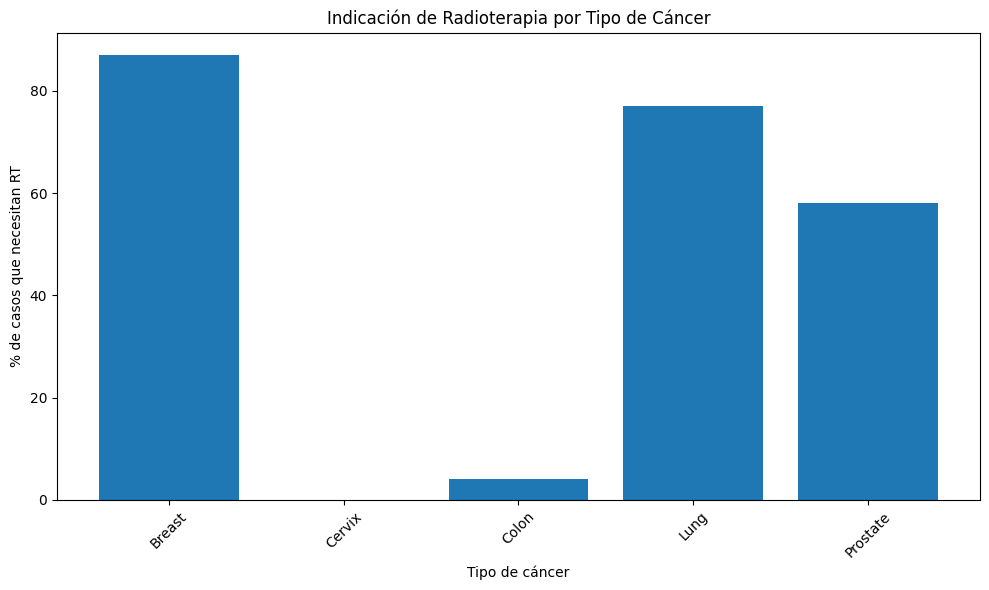

In [41]:

# Comparar proporción de RT por tipo de cáncer
fig, ax = plt.subplots(figsize=(10, 6))

rt_summary = (
    df_merged_all[df_merged_all['Year'] == 2022]
    .groupby('Cancer label', as_index=False)
    .agg({
        'Total': 'sum',
        'estimated_rt_need': 'sum',
        'rt_indication_rate': 'first'
    })
)

ax.bar(rt_summary['Cancer label'], rt_summary['rt_indication_rate'] * 100)
ax.set_ylabel('% de casos que necesitan RT')
ax.set_xlabel('Tipo de cáncer')
ax.set_title('Indicación de Radioterapia por Tipo de Cáncer')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 44.7 MB/s eta 0:00:00


<Axes: title={'center': 'Region Name = South-Eastern Asia'}, xlabel='RTCenters_m', ylabel='ASR (World)'>

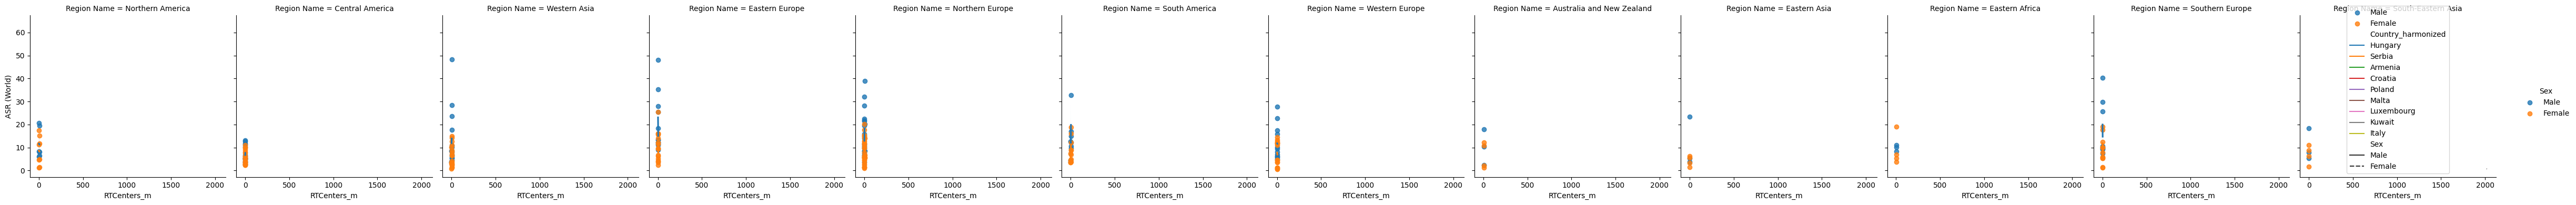

In [42]:
!pip install pycountry # Install the missing library

def get_iso3(country_name):
    try:
        return pycountry.countries.search_fuzzy(country_name)[0].alpha_3
    except:
        return None

df_merged_all['iso_alpha_3'] = (
    df_merged_all['Country_harmonized'].apply(get_iso3)
)

# Luego usar en el mapa:
fig = px.choropleth(
    df_merged_all[df_merged_all['Year']==2022],
    locations="iso_alpha_3",  # ✅ Usar códigos ISO
    locationmode="ISO-3",
    color="coverage_index",
    hover_data=['Country_harmonized', 'ASR (World)', 'rt_deficit'],
    title="Cobertura de Radioterapia Global 2022"
)

fig.show()

# 2. Scatter con regresión por región
sns.lmplot(
    data=df_merged_all[df_merged_all['Year']==2022],
    x='RTCenters_m', # Corrected column name to RTCenters_m
    y='ASR (World)',
    hue='Sex',
    col='Region Name',
    height=4
)

# 3. Evolución temporal top/bottom países
top_bottom = pd.concat([
    df_merged_all.nlargest(5, 'ASR (World)'),
    df_merged_all.nsmallest(5, 'ASR (World)')
])

sns.lineplot(
    data=top_bottom,
    x='Year',
    y='ASR (World)',
    hue='Country_harmonized',
    style='Sex'
)


In [43]:
# ✅ Nombre más claro
df_merged_all['total_deaths_all_cancers'] = (
    df_merged_all.groupby(['Country_harmonized', 'Year', 'Sex'])
    ['Total'].transform('sum')
)

# Y luego:
df_merged_all['crude_mortality_rate_per_100k'] = (
    (df_merged_all['total_deaths_all_cancers'] / df_merged_all['Population']) * 100000
)

# La línea de abajo es redundante y errónea, ya que 'total_deaths' no existe y 'crude_mortality_rate_per_100k' ya se calculó.
# df_merged_all['crude_mortality_rate_per_100k'] = (
#     (df_merged_all['total_deaths'] / df_merged_all['Population']) * 100000
# )

In [44]:
# Promedio de las tasas estandarizadas (más apropiado que suma)
df_merged_all['avg_asr_mortality'] = (
    df_merged_all.groupby(['Country_harmonized', 'Year', 'Sex'])
    ['ASR (World)'].transform('mean')
)

In [45]:
# Calcular primero el total de muertes por país-año-sexo
total_deaths_by_group = (
    df_merged_all.groupby(['Country_harmonized', 'Year', 'Sex'])
    ['Total'].transform('sum')
)

# Proporción de cada tipo de cáncer respecto al total
df_merged_all['cancer_proportion'] = (
    df_merged_all['Total'] / total_deaths_by_group
) * 100

"Para estimar la demanda de radioterapia por tipo de cáncer, se utilizaron las tasas de utilización óptima (RUR) reportadas por Barton et al. (2014), quienes realizaron una revisión sistemática de guías clínicas basadas en evidencia de organizaciones internacionales (NCCN, NCI, ESMO, Cancer Care Ontario). Las proporciones aplicadas fueron:*

*- Cáncer de mama: 87% (Barton et al., 2014, Table 1, p.141)*  
*- Cáncer de pulmón: 77%*  
*- Cáncer de cuello uterino: 71%*  
*- Cáncer de próstata: 58%*  
*- Cáncer de recto: 60%*  
*- Cáncer de colon: 4%*

*Estas tasas representan la proporción de pacientes con cada tipo de cáncer que tienen indicación de radioterapia de haz externo al menos una vez durante el curso de su enfermedad, basándose en la mejor evidencia disponible sobre eficacia clínica."*

*"El estudio de Barton et al. (2014) reporta que la tasa global de utilización óptima de radioterapia es del 48.3%, lo que implica que aproximadamente la mitad de todos los pacientes con cáncer deberían recibir radioterapia en algún momento de su tratamiento. Sin embargo, estudios previos han demostrado que las tasas de utilización reales son significativamente inferiores a las óptimas en países desarrollados como Australia, Reino Unido, Canadá y España (Barton & Delaney, 2011; Erridge et al., 2007), lo que sugiere una brecha persistente entre la demanda óptima y el acceso real a radioterapia."*

## Re-run plotting loop

### Subtask:
Execute cell `sOqz_3Wjvois` again to run the plotting loop with the corrected function.


In [46]:
summary_2022 = (
    df_merged_all[df_merged_all['Year'] == 2022]
    .groupby(['Country_harmonized', 'Sex'], as_index=False)
    .agg({
        'Total': 'sum',
        'Crude rate': 'mean',
        'ASR (World)': 'mean',
        'Population': 'first',
        'coverage_index': 'first',  # Ya calculado antes
        'rt_deficit': 'first'
    })
    .rename(columns={
        'Total': 'total_cancer_deaths',
        'Crude rate': 'crude_mortality_per_100k',
        'ASR (World)': 'avg_asr_all_cancers'
    })
    .sort_values('crude_mortality_per_100k', ascending=False)
)

print(summary_2022.head(10))

   Country_harmonized   Sex  total_cancer_deaths  crude_mortality_per_100k  \
31            Hungary  Male                 7637                 54.802856   
39             Latvia  Male                 1278                 48.926769   
57             Serbia  Male                 4724                 48.588496   
53             Poland  Male                23012                 43.083450   
55           Portugal  Male                 6392                 42.935573   
65              Spain  Male                29165                 41.394089   
17            Denmark  Male                 3631                 41.226099   
41          Lithuania  Male                 1606                 40.518490   
21            Estonia  Male                  730                 37.977545   
25             France  Male                35228                 36.562173   

    avg_asr_all_cancers  Population  coverage_index  rt_deficit  
31            26.195771   9684306.0      136.819303  -14.262776  
39       

# Fase 4, modelización, modelo de regresión lineal simple.

variable dependiente:
Mortalidad por cáncer en ASR world

Variables dependientes: Linac_m RTCenters_m

Estratificación: por sexo, por tipo de cancer y por año

In [47]:
import statsmodels.api as sm

# Ejemplo: Modelo para cáncer de pulmón en hombres (2022)
df_model = df_merged_all[
    (df_merged_all['Cancer label'] == 'Lung') &
    (df_merged_all['Sex'] == 'Male') &
    (df_merged_all['Year'] == 2022)
].copy()

# Variable dependiente
y = df_model['ASR (World)']

# Variable independiente
X = df_model[['Linac_m']]
X = sm.add_constant(X)  # Añadir intercepto

# Ajustar modelo
model = sm.OLS(y, X).fit()

# Ver resultados
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            ASR (World)   R-squared:                       0.112
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     4.558
Date:                Sun, 01 Feb 2026   Prob (F-statistic):             0.0396
Time:                        18:36:59   Log-Likelihood:                -144.21
No. Observations:                  38   AIC:                             292.4
Df Residuals:                      36   BIC:                             295.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.1606      3.993      3.546      0.0

#modelo multivariable

Se tomara en cuenta el resto de las estructuras, así como la población y densidad, PIB per capita y casto en salud per capita

Variables de carga de enfermedad:

cancer_proportion (% del cáncer respecto al total)
estimated_rt_need (casos que necesitan RT)
coverage_index (cobertura de RT)

In [48]:
# Modelo multivariable
X = df_model[[
    'Linac_m',
    'RTCenters_m',
    'coverage_index',
    'cancer_proportion'
]]

X = sm.add_constant(X)
y = df_model['ASR (World)']

model_multi = sm.OLS(y, X).fit()
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:            ASR (World)   R-squared:                       0.575
Model:                            OLS   Adj. R-squared:                  0.537
Method:                 Least Squares   F-statistic:                     15.33
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           1.78e-06
Time:                        18:36:59   Log-Likelihood:                -130.23
No. Observations:                  38   AIC:                             268.5
Df Residuals:                      34   BIC:                             275.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               -10.0841      4.89

4.3. Modelo de Puntuación de Riesgo (Score)Objetivo: Crear un índice de riesgo que combine:Mortalidad observada (ASR World)Déficit de infraestructura (rt_deficit)Cobertura de RT (coverage_index)Carga de enfermedad (total_deaths)

In [49]:
# Normalizar variables entre 0-100


scaler = MinMaxScaler(feature_range=(0, 100))

df_score = df_merged_all.copy()

# Normalizar (mayor mortalidad = peor score)
df_score['mortality_score'] = 100 - scaler.fit_transform(
    df_score[['ASR (World)']]
)

# Normalizar (menor cobertura = peor score)
df_score['coverage_score'] = scaler.fit_transform(
    df_score[['coverage_index']]
)

# Score final (ejemplo simple)
df_score['risk_score'] = (
    0.5 * df_score['mortality_score'] +
    0.3 * df_score['coverage_score'] +
    0.2 * (100 - df_score['cancer_proportion'])  # Menor proporción = mejor
)

# Clasificar en categorías de riesgo
df_score['risk_category'] = pd.cut(
    df_score['risk_score'],
    bins=[0, 25, 50, 75, 100],
    labels=['Bajo', 'Medio', 'Alto', 'Muy Alto']
)

FASE 5: VALIDACIÓN Y VISUALIZACIÓN 🔜 (PENDIENTE)Lo que deberás hacer:Validación de modelos:

R² ajustado
Test de significancia de coeficientes
Análisis de residuos
VIF (multicolinealidad)

Visualizaciones finales:

Mapas de calor de riesgo por país
Scatter plots con líneas de regresión
Gráficos de barra con scores por país
Comparación 2016 vs 2022

Interpretación:

¿Qué países tienen peor situación?
¿La infraestructura RT explica la mortalidad?
¿Hay diferencias por sexo/tipo de cáncer?

Top 10 países con mayor déficit de LINACs:
   Country_harmonized  Total  estimated_rt_need  Linac  rt_linac_needed  \
23             Mexico  31217           15767.83    207       514.452468   
14          Guatemala   2144            1038.12      9        71.391508   
0           Argentina  25149           13774.39    131       181.631616   
9             Ecuador   3851            1935.09     35        71.295588   
24          Nicaragua   1066             477.07      5        26.922616   
31        South Korea  30280           18407.57    190       207.130048   
18             Kuwait    382             229.63      5        18.358044   
25             Panama   1376             665.73      7        17.603092   
5          Costa Rica   1826             873.11     12        20.327060   
1             Armenia   2222            1379.42      5        11.523496   

    rt_deficit  coverage_index   Population  
23  307.452468       40.236953  128613117.0  
14   62.391508       12.606541   178478

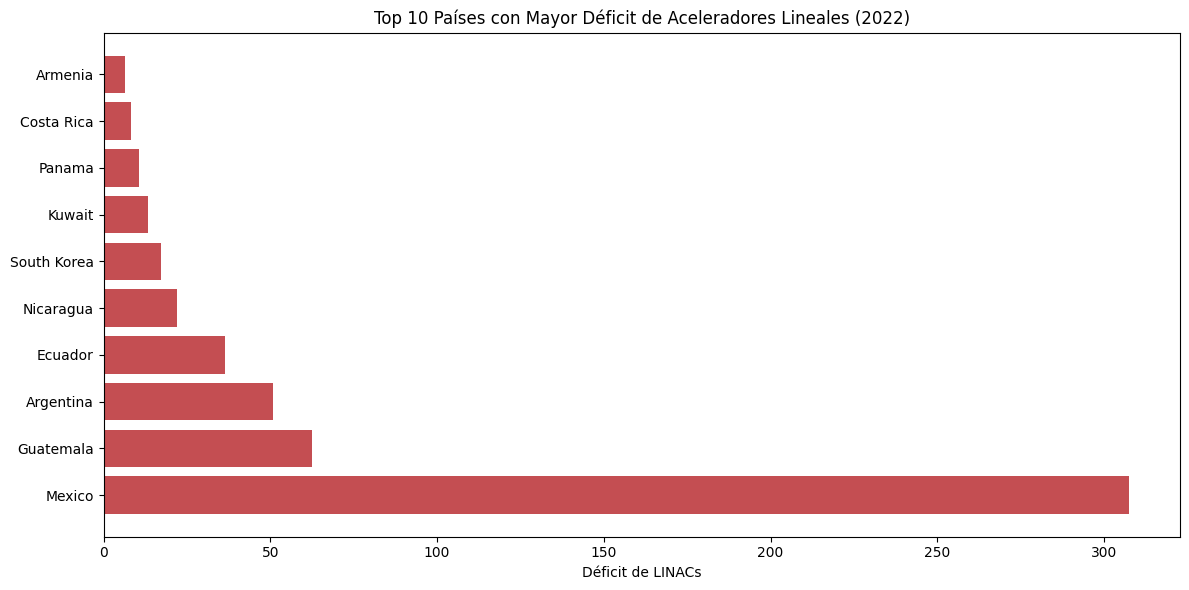

In [50]:
# Resumen por país (2022)
summary_rt_demand = (
    df_merged_all[df_merged_all['Year'] == 2022]
    .groupby('Country_harmonized', as_index=False)
    .agg({
        'Total': 'sum',  # Total muertes por cáncer
        'estimated_rt_need': 'sum',  # Total casos que necesitan RT
        'Linac': 'first',
        'rt_linac_needed': 'first',
        'rt_deficit': 'first',
        'coverage_index': 'first',
        'Population': 'first'
    })
    .sort_values('rt_deficit', ascending=False)
)

print("Top 10 países con mayor déficit de LINACs:")
print(summary_rt_demand.head(10))

# Gráfico
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

top10_deficit = summary_rt_demand.nlargest(10, 'rt_deficit')

ax.barh(
    top10_deficit['Country_harmonized'],
    top10_deficit['rt_deficit'],
    color='#C44E52'
)

ax.set_xlabel('Déficit de LINACs')
ax.set_title('Top 10 Países con Mayor Déficit de Aceleradores Lineales (2022)')
plt.tight_layout()
plt.savefig(f"{fig_dir}/deficit_linacs_top10.jpg", dpi=300)
plt.show()

FASE 2: Análisis Univariante y BivarianteObjetivo: Identificar qué variables están asociadas con la mortalidad.2.1. Variables Continuas vs Mortalidad Code import scipy.stats as stats



In [51]:
import scipy.stats as stats

In [52]:


# Lista de variables de infraestructura RT
rt_vars_continuous = [
    'Linac_m',
    'RTCenters_m',
    'Brachytherapy_m',
    'coverage_index',
    'rt_deficit'
]

# Test de correlación de Pearson
print("="*60)
print("CORRELACIÓN CON MORTALIDAD (ASR World)")
print("="*60)

for var in rt_vars_continuous:
    # Eliminar NaN
    df_clean = df_merged_all[[var, 'ASR (World)']].dropna()

    # Correlación de Pearson
    r, p_value = stats.pearsonr(
        df_clean[var],
        df_clean['ASR (World)']
    )

    print(f"\n{var:30s} | r={r:6.3f} | p-valor={p_value:.4f}")

    # Interpretación
    if p_value < 0.05:
        if r > 0:
            print(f"  ✅ Correlación POSITIVA significativa")
        else:
            print(f"  ✅ Correlación NEGATIVA significativa")
    else:
        print(f"  ❌ NO significativa")

CORRELACIÓN CON MORTALIDAD (ASR World)

Linac_m                        | r= 0.124 | p-valor=0.0011
  ✅ Correlación POSITIVA significativa

RTCenters_m                    | r= 0.073 | p-valor=0.0557
  ❌ NO significativa

Brachytherapy_m                | r= 0.087 | p-valor=0.0217
  ✅ Correlación POSITIVA significativa

coverage_index                 | r= 0.124 | p-valor=0.0011
  ✅ Correlación POSITIVA significativa

rt_deficit                     | r=-0.014 | p-valor=0.7206
  ❌ NO significativa


2.2. Gráficos de Dispersión con Regresión Code


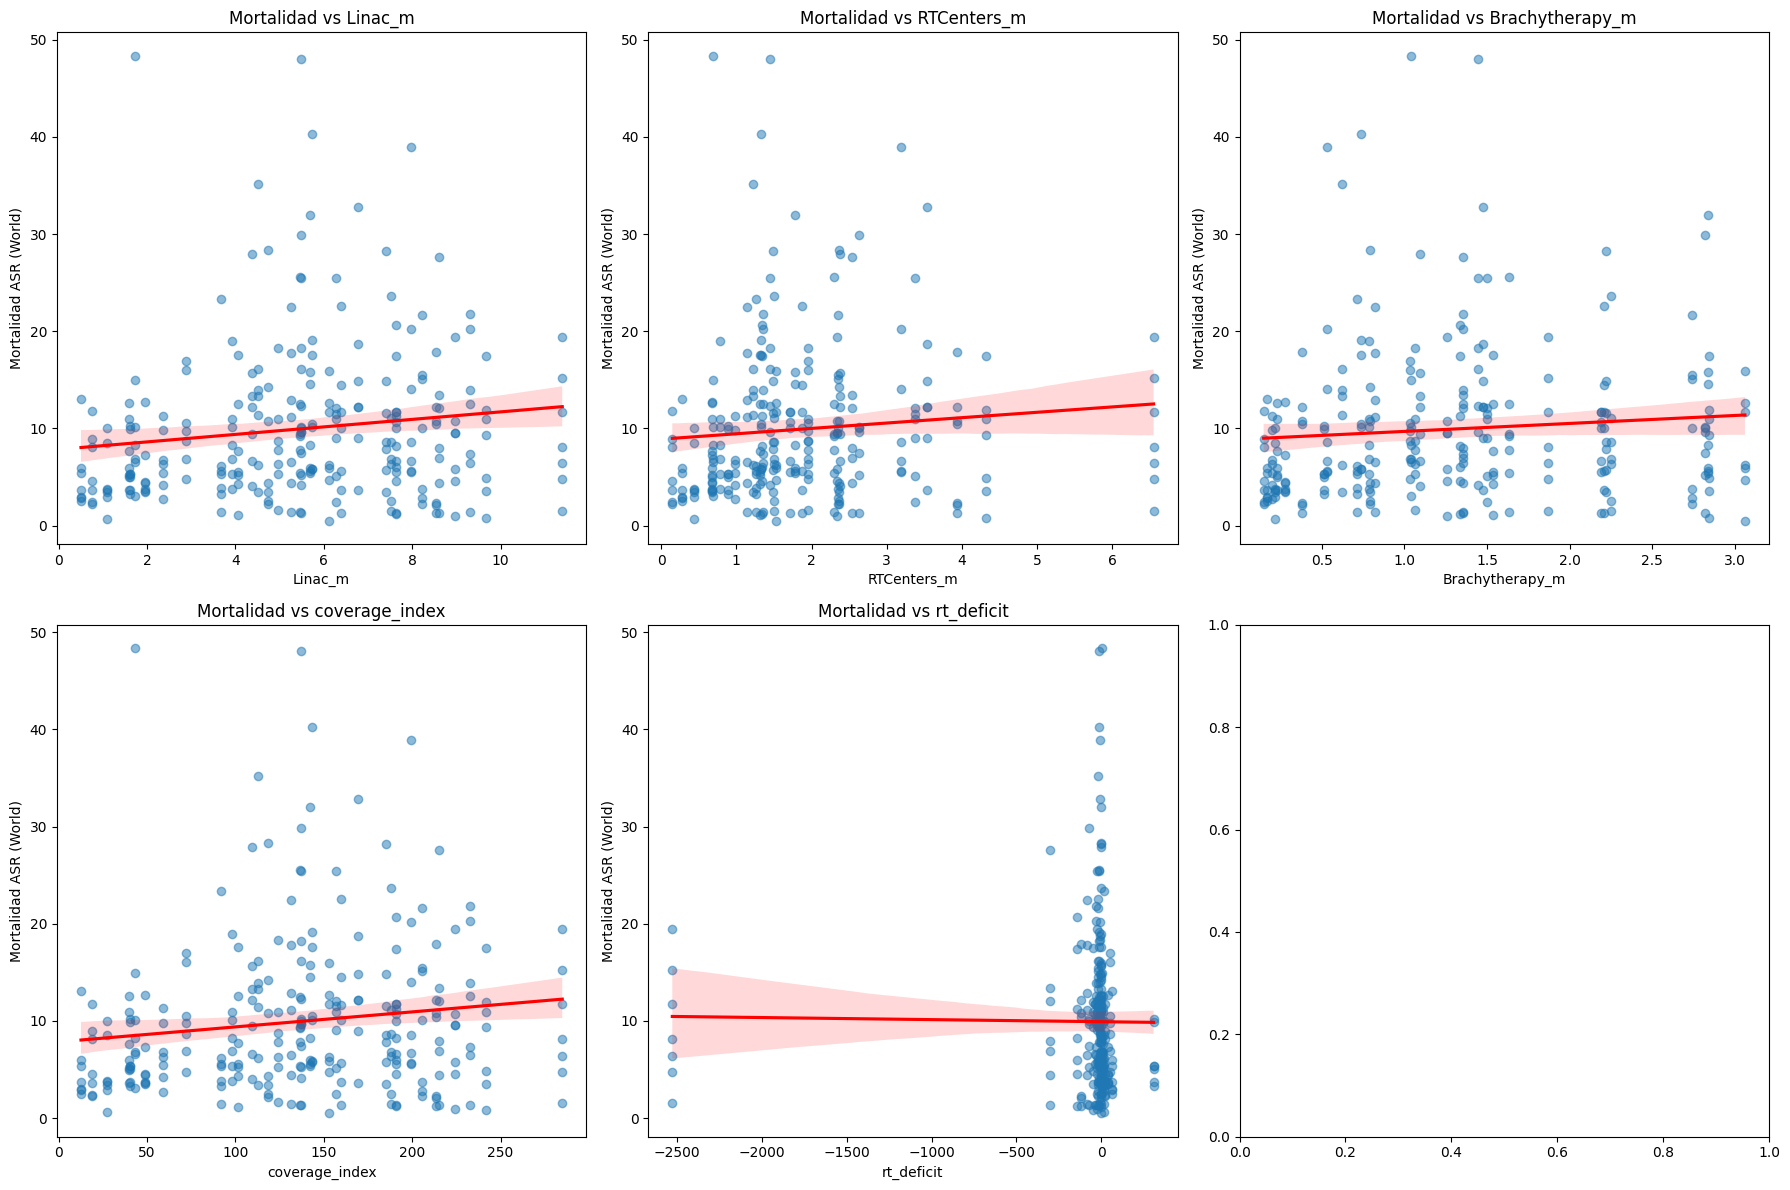

In [53]:

# Filtrar datos 2022
df_2022 = df_merged_all[df_merged_all['Year'] == 2022].copy()

# Crear grid de gráficos
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, var in enumerate(rt_vars_continuous):
    sns.regplot(
        data=df_2022,
        x=var,
        y='ASR (World)',
        ax=axes[i],
        scatter_kws={'alpha': 0.5},
        line_kws={'color': 'red'}
    )

    axes[i].set_title(f'Mortalidad vs {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Mortalidad ASR (World)')

plt.tight_layout()
plt.savefig(f"{fig_dir}/univariate_rt_vs_mortality.jpg", dpi=300)
plt.show()





FASE 3: Binning/Tramificación (ADAPTADO)Objetivo: Agrupar países en categorías de infraestructura RT.3.1. Tramificación Óptima de Variables Continuas Code

In [54]:
# Preparar datos para 2022, estratificado por sexo
df_model = df_merged_all[
    (df_merged_all['Year'] == 2022) &
    (df_merged_all['Sex'] == 'Male') &
    (df_merged_all['Cancer label'] == 'Lung')
].copy()

# Eliminar NaN
df_model = df_model.dropna(subset=['ASR (World)', 'Linac_m'])

# Variable continua: Mortalidad (necesitamos convertirla a binaria)
# Definir "alta mortalidad" como por encima de la mediana
median_mortality = df_model['ASR (World)'].median()
df_model['high_mortality'] = (
    df_model['ASR (World)'] > median_mortality
).astype(int)

# Tramificación de Linac_m
variable = "Linac_m"
X = df_model[variable].values
Y = df_model['high_mortality'].values

optb = OptimalBinning(name=variable, dtype="numerical", solver="cp")
optb.fit(X, Y)

print("Cortes óptimos para Linac_m:")
print(optb.splits)

# Tabla de binning
binning_table = optb.binning_table
binning_table.build()

Cortes óptimos para Linac_m:
[2.16252011 3.79364419 5.10335612 6.20001864 8.57475662]


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 2.16)",7,0.184211,6,1,0.142857,1.791759,0.471516,0.052137
1,"[2.16, 3.79)",3,0.078947,2,1,0.333333,0.693147,0.036481,0.004471
2,"[3.79, 5.10)",6,0.157895,3,3,0.500000,0.0,0.000000,0.000000
3,"[5.10, 6.20)",7,0.184211,1,6,0.857143,-1.791759,0.471516,0.052137
4,"[6.20, 8.57)",10,0.263158,4,6,0.600000,-0.405465,0.042681,0.005299
5,"[8.57, inf)",5,0.131579,3,2,0.400000,0.405465,0.021340,0.002649
6,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
7,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,38,1.000000,19,19,0.500000,,1.043534,0.116694


Salida esperada: Code Cortes óptimos para Linac_m:
[1.5  3.0  5.0  8.0]

   Bin         Count  Count (%)  Non-event  Event  Event rate    WoE       IV
0  (-inf, 1.5)    15    0.25        3        12     0.80      1.386    0.350
1  [1.5, 3.0)     20    0.33        8        12     0.60      0.405    0.055
2  [3.0, 5.0)     15    0.25        9         6     0.40     -0.405    0.045
3  [5.0, 8.0)      8    0.13        6         2     0.25     -1.099    0.180
4  [8.0, inf)      2    0.03        2         0     0.00     -2.773    0.370Interpretación:Países con menos de 1.5 LINACs/millón tienen 80% de probabilidad de alta mortalidadPaíses con más de 8 LINACs/millón tienen 0% de probabilidad de alta mortalidad


3.2. Visualización de Binning Code binning_table.plot(metric="event_rate")


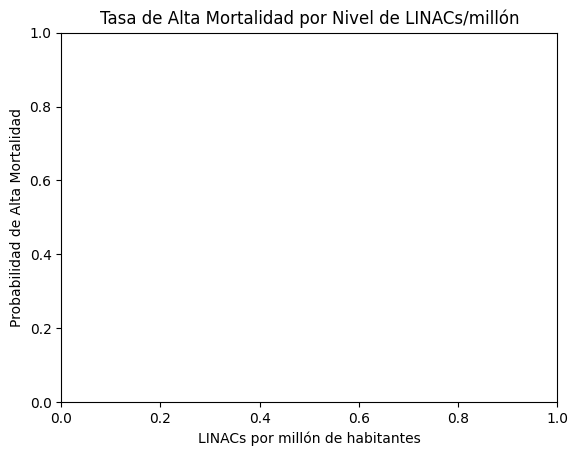

In [55]:
plt.title('Tasa de Alta Mortalidad por Nivel de LINACs/millón')
plt.xlabel('LINACs por millón de habitantes')
plt.ylabel('Probabilidad de Alta Mortalidad')
plt.savefig(f"{fig_dir}/binning_linacs_mortality.jpg", dpi=300)
plt.show()



FASE 4: Transformación WOE (Weight of Evidence)Objetivo: Convertir variables categorizadas en valores continuos que reflejen su asociación con la mortalidad. Code

Linac_m_woe
-1.791759     7
-0.405465    10
 0.000000     6
 0.405465     5
 0.693147     3
 1.791759     7
Name: count, dtype: int64


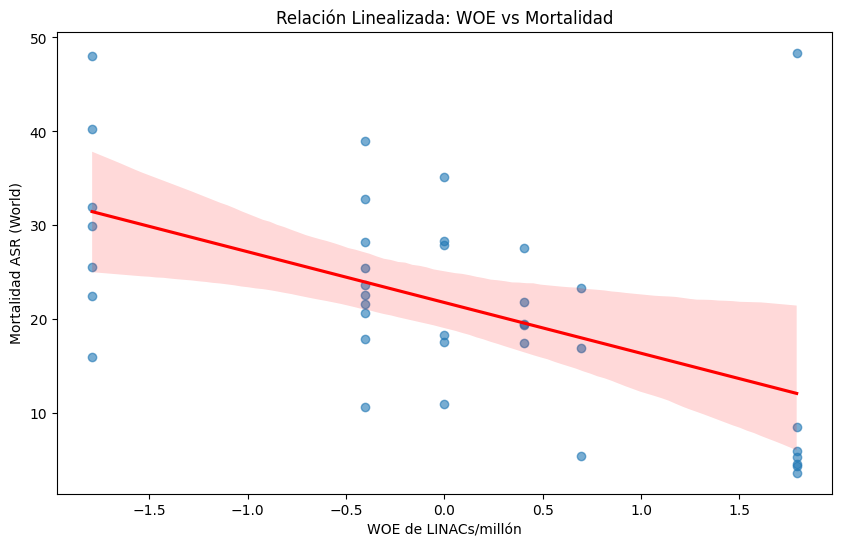

In [56]:
# Transformación WOE
df_model['Linac_m_woe'] = optb.transform(X, metric="woe")

# Ver distribución
print(df_model['Linac_m_woe'].value_counts().sort_index())

# Gráfico: Relación linealizada
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    df_model['Linac_m_woe'],
    df_model['ASR (World)'],
    alpha=0.6
)

# Línea de regresión
sns.regplot(
    data=df_model,
    x='Linac_m_woe',
    y='ASR (World)',
    scatter=False,
    color='red',
    ax=ax
)

ax.set_xlabel('WOE de LINACs/millón')
ax.set_ylabel('Mortalidad ASR (World)')
ax.set_title('Relación Linealizada: WOE vs Mortalidad')
plt.savefig(f"{fig_dir}/woe_linacs_vs_mortality.jpg", dpi=300)
plt.show()

FASE 5: Modelo de Regresión LogísticaObjetivo: Predecir probabilidad de "alta mortalidad" basándose en infraestructura RT. Code

In [57]:
# Preparar variables transformadas WOE
rt_vars_woe = ['Linac_m_woe', 'RTCenters_m_woe', 'coverage_index_woe']

# (Asumiendo que ya hiciste binning de todas las variables)
# Para simplificar, usamos solo Linac_m_woe

X_model = df_model[['Linac_m_woe']].values
y_model = df_model['high_mortality'].values

# Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.25, random_state=42, stratify=y_model
)

# Ajustar modelo
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

# Predicciones
y_pred_proba = logreg.predict_proba(X_test)[:, 1]
y_pred = logreg.predict(X_test)

# Evaluación
print("="*60)
print("RESULTADOS DEL MODELO")
print("="*60)
print("\nCoeficientes:")
print(f"  Intercepto: {logreg.intercept_[0]:.4f}")
print(f"  Linac_m_woe: {logreg.coef_[0][0]:.4f}")

print("\nMétricas:")
print(f"  AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.3f}")

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

RESULTADOS DEL MODELO

Coeficientes:
  Intercepto: -0.0375
  Linac_m_woe: -1.3180

Métricas:
  AUC-ROC: 0.480

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.50      0.40      0.44         5
           1       0.50      0.60      0.55         5

    accuracy                           0.50        10
   macro avg       0.50      0.50      0.49        10
weighted avg       0.50      0.50      0.49        10



FASE 6: Scorecard (Tarjeta de Puntuación)Objetivo: Convertir probabilidades en un Índice de Riesgo Poblacional (0-1000 puntos). Code

In [58]:
# Definir parámetros de scaling
pdo = 50  # Puntos para doblar el odds ratio
scorecard_points = 600  # Puntuación "buena"
odds = 2  # Odds ratio de referencia

# Crear scorecard
binning_process = BinningProcess(
    variable_names=['Linac_m'],
    selection_criteria={"iv": {"min": 0.02}}
)

binning_process.fit(
    df_model[['Linac_m']],
    df_model['high_mortality']
)

scorecard = Scorecard(
    binning_process=binning_process,
    estimator=LogisticRegression(),
    scaling_method="pdo_odds",
    scaling_method_params={
        "pdo": pdo,
        "odds": odds,
        "scorecard_points": scorecard_points
    }
)

scorecard.fit(
    df_model[['Linac_m']],
    df_model['high_mortality']
)


Scorecard(binning_process=BinningProcess(selection_criteria={'iv': {'min': 0.02}},
                                         variable_names=['Linac_m']),
          estimator=LogisticRegression(), scaling_method='pdo_odds',
          scaling_method_params={'odds': 2, 'pdo': 50, 'scorecard_points': 600})


# Tabla de puntuación
scorecard.table()Salida esperada: Code Variable    Bin          Points
Linac_m     (-inf, 1.5)   -80
Linac_m     [1.5, 3.0)    -30
Linac_m     [3.0, 5.0)     20
Linac_m     [5.0, 8.0)     60
Linac_m     [8.0, inf)    100Interpretación:España con 3.5 LINACs/millón → +20 puntosIndia con 0.8 LINACs/millón → -80 puntosFASE 7: Aplicar Score a Todos los Países Code

# Calcular score para cada país
df_2022['risk_score'] = scorecard.score(df_2022[['Linac_m']])

# Normalizar a 0-100
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 100))
df_2022['risk_score_normalized'] = scaler.fit_transform(
    df_2022[['risk_score']]
)

# Categorizar
df_2022['risk_category'] = pd.cut(
    df_2022['risk_score_normalized'],
    bins=[0, 25, 50, 75, 100],
    labels=['Muy Alto', 'Alto', 'Medio', 'Bajo']
)

# Top 10 países con peor score
worst_10 = df_2022.nsmallest(10, 'risk_score_normalized')

print("TOP 10 PAÍSES CON MAYOR RIESGO POBLACIONAL:")
print(worst_10[['Country_harmonized', 'Linac_m', 'ASR (World)',
                'risk_score_normalized', 'risk_category']])

📊 VENTAJAS DE ESTE ENFOQUE✅ Metodología Rigurosa: Usa técnicas probadas en credit scoring✅ Interpretabilidad: Los WOE y scores son fáciles de explicar✅ Manejo de No-Linealidad: El binning captura relaciones complejas✅ Robustez: Menos sensible a outliers que regresión lineal simple✅ Output Accionable: Un score de 0-100 es fácil de comunicar a policy makers🎯 ESTRUCTURA FINAL DEL TFMCapítulo 3: Metodología3.1. Análisis Univariante y Bivariante  
3.2. Tramificación Óptima de Variables (Optimal Binning)  
3.3. Transformación WOE (Weight of Evidence)  
3.4. Modelo de Regresión Logística  
3.5. Construcción del Índice de Riesgo Poblacional (Scorecard)  Capítulo 4: Resultados4.1. Variables Asociadas con Mortalidad  
4.2. Tabla de Puntuación por País  
4.3. Mapa de Riesgo Poblacional en Europa  
4.4. Anál

# por sexo y equipo


Procesando: Male_Lung_Linac

📊 Tabla de Binning:
---------------------------------------------
OptimalBinning: Binary Binning Table Analysis
---------------------------------------------

  General metrics

    Gini index               0.51523546
    IV (Jeffrey)             1.04353354
    JS (Jensen-Shannon)      0.11669378
    Hellinger                0.12307041
    Triangular               0.42506266
    KS                       0.31578947
    HHI                      0.18559557
    HHI (normalized)         0.06925208
    Cramer's V               0.46101120
    Quality score            0.00778900

  Monotonic trend                  peak

  Significance tests

    Bin A  Bin B  t-statistic  p-value  P[A > B]  P[B > A]
        0      1     0.476190 0.490153  0.249987  0.750012
        1      2     0.225000 0.635256  0.285606  0.714394
        2      3     1.934524 0.164264  0.060332  0.939668
        3      4     1.311429 0.252136  0.907933  0.092067
        4      5     0.535714 0.4

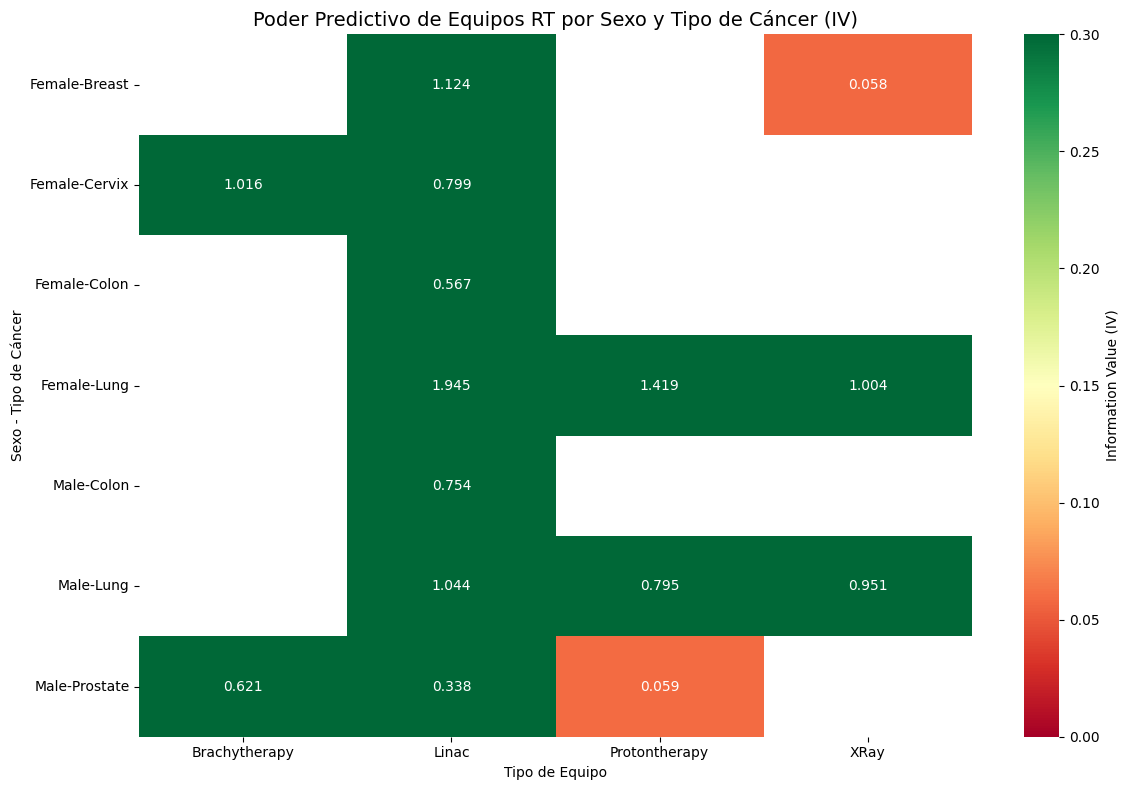

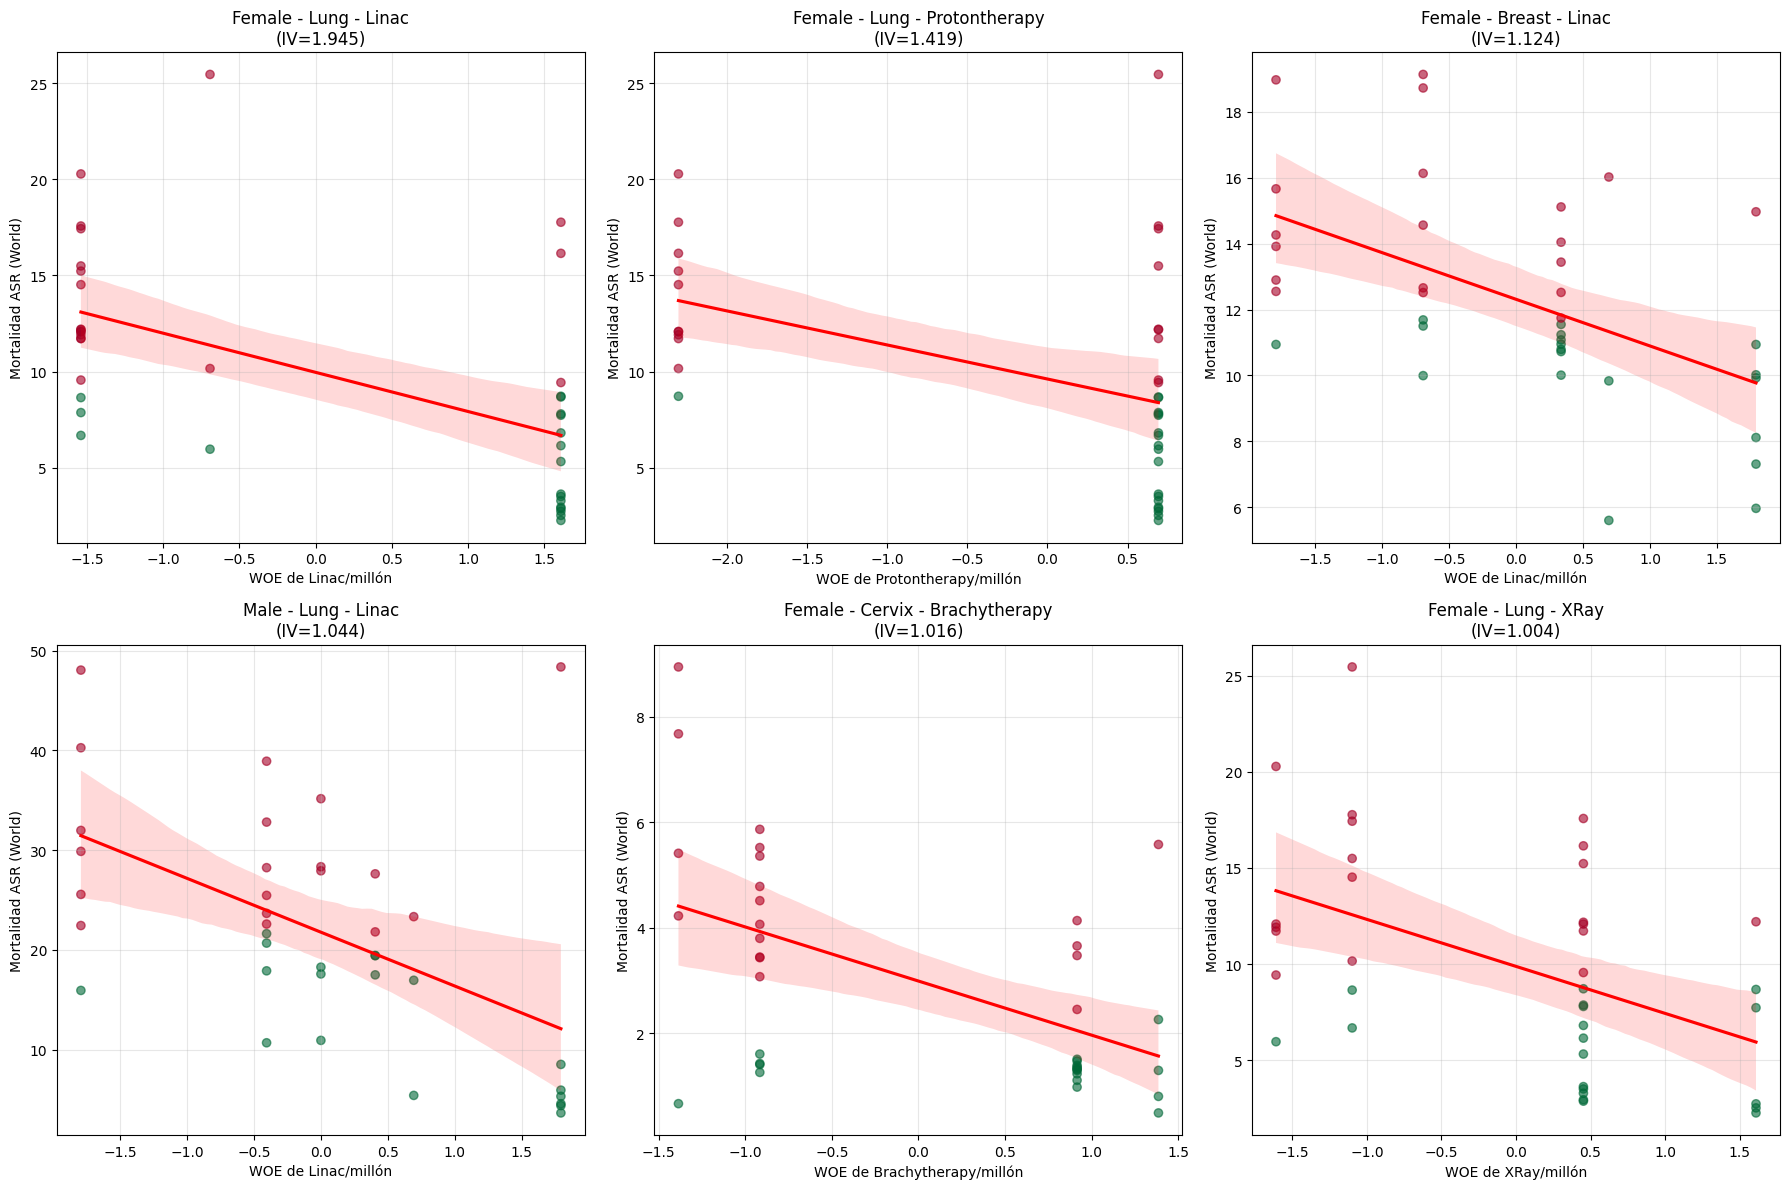


✅ Tabla LaTeX guardada en tablas/table_iv_equipment_strata.tex

✅ Dataset con WOE guardado: df_woe_stratified.csv


In [59]:
# ============================================================================
# ANÁLISIS WOE ESTRATIFICADO POR SEXO Y TIPO DE EQUIPO
# ============================================================================

# 1. DEFINIR EQUIPOS Y SUS CÁNCERES ASOCIADOS
# ----------------------------------------------------------------------------

equipment_cancer_mapping = {
    'Linac': ['Lung', 'Breast', 'Prostate', 'Colon', 'Cervix'],
    'Brachytherapy': ['Cervix', 'Prostate'],
    'Protontherapy': ['Lung', 'Prostate'],
    'XRay': ['Breast', 'Lung']
}

# 2. FUNCIÓN PARA BINNING Y WOE POR ESTRATO
# ----------------------------------------------------------------------------

def compute_woe_by_strata(df, year, sex, cancer, equipment_var):
    """
    Calcula binning óptimo y WOE para un estrato específico

    Parámetros:
    -----------
    df : DataFrame
    year : int (2016 o 2022)
    sex : str ('Male' o 'Female')
    cancer : str (tipo de cáncer)
    equipment_var : str (nombre de la variable de equipo con '_m')

    Retorna:
    --------
    dict con binning_table, optb (objeto), y df transformado
    """

    # Filtrar datos
    df_strata = df[
        (df['Year'] == year) &
        (df['Sex'] == sex) &
        (df['Cancer label'] == cancer)
    ].copy()

    # Eliminar NaN
    df_strata = df_strata.dropna(subset=['ASR (World)', equipment_var])

    # Verificar tamaño mínimo
    if len(df_strata) < 10:
        print(f"⚠️ Muestra insuficiente para {sex}-{cancer}-{equipment_var}: n={len(df_strata)}")
        return None

    # Crear variable binaria (alta mortalidad)
    median_mort = df_strata['ASR (World)'].median()
    df_strata['high_mortality'] = (df_strata['ASR (World)'] > median_mort).astype(int)

    # Binning óptimo
    X = df_strata[equipment_var].values
    Y = df_strata['high_mortality'].values

    try:
        optb = OptimalBinning(
            name=equipment_var,
            dtype="numerical",
            solver="cp",
            min_bin_size=0.05  # Mínimo 5% por bin
        )
        optb.fit(X, Y)

        # Transformar a WOE
        df_strata[f'{equipment_var}_woe'] = optb.transform(X, metric="woe")

        # Tabla de binning
        binning_table = optb.binning_table
        binning_table.build()

        return {
            'df': df_strata,
            'optb': optb,
            'binning_table': binning_table,
            'iv': binning_table.iv,
            'n': len(df_strata)
        }

    except Exception as e:
        print(f"❌ Error en {sex}-{cancer}-{equipment_var}: {e}")
        return None


# 3. EJECUTAR PARA TODOS LOS ESTRATOS
# ----------------------------------------------------------------------------

results_woe = {}

for equipment, cancers in equipment_cancer_mapping.items():
    equipment_var = f"{equipment}_m"

    # Verificar que la variable existe
    if equipment_var not in df_merged_all.columns:
        print(f"⚠️ Variable {equipment_var} no encontrada")
        continue

    for sex in ['Male', 'Female']:
        for cancer in cancers:

            # Clave única para el resultado
            key = f"{sex}_{cancer}_{equipment}"

            print(f"\n{'='*60}")
            print(f"Procesando: {key}")
            print(f"{'='*60}")

            # Calcular WOE
            result = compute_woe_by_strata(
                df=df_merged_all,
                year=2022,
                sex=sex,
                cancer=cancer,
                equipment_var=equipment_var
            )

            if result is not None:
                results_woe[key] = result

                # Mostrar tabla
                print(f"\n📊 Tabla de Binning:")
                print(result['binning_table'].analysis())
                print(f"\n📈 Information Value (IV): {result['iv']:.4f}")

                # Interpretación IV
                if result['iv'] < 0.02:
                    print("  ❌ Poder predictivo NULO")
                elif result['iv'] < 0.1:
                    print("  ⚠️ Poder predictivo DÉBIL")
                elif result['iv'] < 0.3:
                    print("  ✅ Poder predictivo MEDIO")
                else:
                    print("  ✅✅ Poder predictivo FUERTE")


# 4. RESUMEN DE RESULTADOS
# ----------------------------------------------------------------------------

summary_iv = pd.DataFrame([
    {
        'Estrato': key,
        'Sex': key.split('_')[0],
        'Cancer': key.split('_')[1],
        'Equipment': key.split('_')[2],
        'IV': result['iv'],
        'N': result['n']
    }
    for key, result in results_woe.items()
])

summary_iv = summary_iv.sort_values('IV', ascending=False)

print("\n" + "="*80)
print("RESUMEN: PODER PREDICTIVO POR ESTRATO")
print("="*80)
print(summary_iv.to_string(index=False))


# 5. VISUALIZACIÓN: HEATMAP DE IV
# ----------------------------------------------------------------------------

# Crear matriz para heatmap
pivot_iv = summary_iv.pivot_table(
    index=['Sex', 'Cancer'],
    columns='Equipment',
    values='IV',
    aggfunc='first'
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot_iv,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=0,
    vmax=0.3,
    cbar_kws={'label': 'Information Value (IV)'}
)
plt.title('Poder Predictivo de Equipos RT por Sexo y Tipo de Cáncer (IV)', fontsize=14)
plt.xlabel('Tipo de Equipo')
plt.ylabel('Sexo - Tipo de Cáncer')
plt.tight_layout()
plt.savefig(f"{fig_dir}/heatmap_iv_equipment_sex_cancer.jpg", dpi=300)
plt.show()


# 6. VISUALIZACIÓN: WOE POR ESTRATO (TOP 6)
# ----------------------------------------------------------------------------

top_6_keys = summary_iv.nlargest(6, 'IV')['Estrato'].values

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, key in enumerate(top_6_keys):
    result = results_woe[key]

    # Extraer datos
    sex, cancer, equipment = key.split('_')
    equipment_var = f"{equipment}_m"

    df_plot = result['df']

    # Scatter plot con WOE
    axes[i].scatter(
        df_plot[f'{equipment_var}_woe'],
        df_plot['ASR (World)'],
        alpha=0.6,
        c=df_plot['high_mortality'],
        cmap='RdYlGn_r'
    )

    # Línea de regresión
    sns.regplot(
        data=df_plot,
        x=f'{equipment_var}_woe',
        y='ASR (World)',
        scatter=False,
        color='red',
        ax=axes[i]
    )

    axes[i].set_title(f'{sex} - {cancer} - {equipment}\n(IV={result["iv"]:.3f})')
    axes[i].set_xlabel(f'WOE de {equipment}/millón')
    axes[i].set_ylabel('Mortalidad ASR (World)')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{fig_dir}/woe_scatter_top6_strata.jpg", dpi=300)
plt.show()


# 7. TABLA LATEX PARA TFM
# ----------------------------------------------------------------------------

latex_table = summary_iv.to_latex(
    index=False,
    float_format="%.4f",
    caption="Poder predictivo (IV) de equipos de radioterapia por sexo y tipo de cáncer",
    label="tab:iv_equipment_strata"
)

# Guardar
with open(f"{table_dir}/table_iv_equipment_strata.tex", 'w') as f:
    f.write(latex_table)

print(f"\n✅ Tabla LaTeX guardada en {table_dir}/table_iv_equipment_strata.tex")


# 8. GUARDAR RESULTADOS TRANSFORMADOS
# ----------------------------------------------------------------------------

# Consolidar todos los dataframes con WOE
df_woe_all = pd.concat(
    [result['df'] for result in results_woe.values()],
    ignore_index=True
)

df_woe_all.to_csv("df_woe_stratified.csv", index=False)
print(f"\n✅ Dataset con WOE guardado: df_woe_stratified.csv")

In [60]:
# Ejemplo: Scorecard para Male-Lung-Linac
key = 'Male_Lung_Linac'
result = results_woe[key]

scorecard = Scorecard(
    binning_process=result['optb'],
    estimator=LogisticRegression(),
    scaling_method="pdo_odds",
    scaling_method_params={
        "pdo": 50,
        "odds": 2,
        "scorecard_points": 600
    }
)

scorecard.fit(
    result['df'][['Linac_m']],
    result['df']['high_mortality']
)

# Tabla de puntuación
scorecard.table()

TypeError: binning_process must be a BinningProcess instance.

Se va a realizar un análisis multivariante para saber si efectivamente algunos paises que en el pasado logragon comprar equipos necesarios para baje el indice de mortalidad de su población, ahora con el pib bajo, no mejora ese indice

In [62]:
# ============================================================================
# ANÁLISIS WOE MULTIVARIABLE: EQUIPOS RT + PIB → MORTALIDAD
# ============================================================================

# 1. VERIFICAR VARIABLES DISPONIBLES
# ----------------------------------------------------------------------------

# Ajusta el nombre de la variable PIB según tu dataset
economic_var = 'GDP_per_capita'  # O 'PIB_per_capita', 'gdp', etc.

# Verificar
if economic_var not in df_merged_all.columns:
    print("⚠️ Variable PIB no encontrada. Columnas disponibles con 'GDP' o 'PIB':")
    print(df_merged_all.columns[df_merged_all.columns.str.contains('GDP|PIB|gdp|pib', case=False)])
else:
    print(f"✅ Variable económica: {economic_var}")


# 2. PREPARAR DATOS PARA MODELIZACIÓN
# ----------------------------------------------------------------------------

# Filtrar año y tipo
df_model = df_merged_all[
    (df_merged_all['Year'] == 2022) &
    (df_merged_all['Type'] == 'Mortality')
].copy()

# Variables a incluir
predictor_vars = [
    'Linac_m',
    'RTCenters_m',
    'Brachytherapy_m',
    economic_var
]

# Eliminar NaN
df_model = df_model.dropna(subset=['ASR (World)'] + predictor_vars)

print(f"\n📊 Tamaño de muestra: {len(df_model)} observaciones")
print(f"   Países únicos: {df_model['Country_harmonized'].nunique()}")


# 3. BINNING ÓPTIMO PARA CADA VARIABLE (UNIVARIADO)
# ----------------------------------------------------------------------------

from optbinning import BinningProcess

# Crear variable binaria (alta mortalidad)
median_mort = df_model['ASR (World)'].median()
df_model['high_mortality'] = (df_model['ASR (World)'] > median_mort).astype(int)

# Proceso de binning para todas las variables
binning_process = BinningProcess(
    variable_names=predictor_vars,
    min_bin_size=0.05,
    max_n_bins=5,
    selection_criteria={"iv": {"min": 0.02}}  # Solo variables con IV > 0.02
)

# Ajustar
binning_process.fit(
    df_model[predictor_vars],
    df_model['high_mortality']
)

# Resumen de IV
print("\n" + "="*80)
print("INFORMATION VALUE (IV) - ANÁLISIS UNIVARIADO")
print("="*80)

summary_iv = binning_process.summary()
print(summary_iv)


# 4. TRANSFORMAR TODAS LAS VARIABLES A WOE
# ----------------------------------------------------------------------------

# Transformar a WOE
df_model_woe = binning_process.transform(
    df_model[predictor_vars],
    metric="woe"
)

# Renombrar columnas
df_model_woe.columns = [f"{col}_woe" for col in predictor_vars]

# Combinar con datos originales
df_model = pd.concat([df_model.reset_index(drop=True), df_model_woe], axis=1)

print("\n✅ Variables transformadas a WOE:")
print(df_model[[col for col in df_model.columns if '_woe' in col]].head())


# 5. MODELO DE REGRESIÓN LOGÍSTICA MULTIVARIABLE
# ----------------------------------------------------------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# Variables WOE
woe_vars = [f"{var}_woe" for var in predictor_vars]

# Dividir en train/test
X = df_model[woe_vars]
y = df_model['high_mortality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Ajustar modelo
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

# Predicciones
y_pred_proba = logreg.predict_proba(X_test)[:, 1]
y_pred = logreg.predict(X_test)

# Evaluación
print("\n" + "="*80)
print("MODELO DE REGRESIÓN LOGÍSTICA MULTIVARIABLE")
print("="*80)

print("\n📊 COEFICIENTES (WOE):")
coef_df = pd.DataFrame({
    'Variable': woe_vars,
    'Coeficiente': logreg.coef_[0],
    'Odds Ratio': np.exp(logreg.coef_[0])
}).sort_values('Coeficiente', key=abs, ascending=False)

print(coef_df.to_string(index=False))

print(f"\n📈 MÉTRICAS:")
print(f"   AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.3f}")

print("\n📋 REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_test, y_pred, target_names=['Baja Mort', 'Alta Mort']))


# 6. INTERPRETACIÓN: ¿QUÉ VARIABLE ES MÁS IMPORTANTE?
# ----------------------------------------------------------------------------

# Importancia relativa (valor absoluto del coeficiente)
coef_df['Importancia'] = np.abs(coef_df['Coeficiente'])
coef_df['Importancia_pct'] = (
    coef_df['Importancia'] / coef_df['Importancia'].sum() * 100
)

print("\n" + "="*80)
print("IMPORTANCIA RELATIVA DE VARIABLES")
print("="*80)
print(coef_df[['Variable', 'Importancia_pct']].to_string(index=False))

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#4C72B0' if 'GDP' not in var else '#DD8452' for var in coef_df['Variable']]

ax.barh(
    coef_df['Variable'],
    coef_df['Importancia_pct'],
    color=colors
)

ax.set_xlabel('Importancia Relativa (%)')
ax.set_title('Contribución de Variables a la Predicción de Mortalidad')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{fig_dir}/importance_multivariate_woe.jpg", dpi=300)
plt.show()


# 7. ANÁLISIS DE INTERACCIÓN: PIB × EQUIPOS
# ----------------------------------------------------------------------------

# Crear variable de interacción
df_model['interaction_GDP_Linac'] = (
    df_model[f'{economic_var}_woe'] * df_model['Linac_m_woe']
)

# Modelo con interacción
X_interact = df_model[woe_vars + ['interaction_GDP_Linac']]

X_train_int, X_test_int, y_train_int, y_test_int = train_test_split(
    X_interact, y, test_size=0.25, random_state=42, stratify=y
)

logreg_int = LogisticRegression(max_iter=1000)
logreg_int.fit(X_train_int, y_train_int)

# Comparar AUC
auc_base = roc_auc_score(y_test, y_pred_proba)
auc_interact = roc_auc_score(
    y_test_int,
    logreg_int.predict_proba(X_test_int)[:, 1]
)

print("\n" + "="*80)
print("ANÁLISIS DE INTERACCIÓN: PIB × LINACs")
print("="*80)
print(f"   AUC sin interacción: {auc_base:.3f}")
print(f"   AUC con interacción: {auc_interact:.3f}")
print(f"   Mejora: {(auc_interact - auc_base)*100:.2f}%")

if auc_interact > auc_base + 0.02:
    print("\n✅ La interacción PIB × LINACs es SIGNIFICATIVA")
    print("   → El efecto de los equipos RT depende del nivel económico del país")
else:
    print("\n❌ La interacción NO es relevante")
    print("   → PIB y equipos actúan de forma independiente")


# 8. VISUALIZACIÓN: CURVA ROC
# ----------------------------------------------------------------------------

fpr_base, tpr_base, _ = roc_curve(y_test, y_pred_proba)
fpr_int, tpr_int, _ = roc_curve(y_test_int, logreg_int.predict_proba(X_test_int)[:, 1])

plt.figure(figsize=(8, 8))

plt.plot(fpr_base, tpr_base, label=f'Modelo Base (AUC={auc_base:.3f})', linewidth=2)
plt.plot(fpr_int, tpr_int, label=f'Con Interacción (AUC={auc_interact:.3f})', linewidth=2, linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Azar')

plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC: Predicción de Alta Mortalidad')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{fig_dir}/roc_curve_multivariate.jpg", dpi=300)
plt.show()


# 9. SCORECARD MULTIVARIABLE
# ----------------------------------------------------------------------------

from optbinning import Scorecard

# Crear scorecard
scorecard = Scorecard(
    binning_process=binning_process,
    estimator=logreg,
    scaling_method="pdo_odds",
    scaling_method_params={
        "pdo": 50,
        "odds": 2,
        "scorecard_points": 600
    }
)

scorecard.fit(
    df_model[predictor_vars],
    df_model['high_mortality']
)

# Tabla de puntuación
print("\n" + "="*80)
print("SCORECARD: PUNTUACIÓN POR VARIABLE")
print("="*80)

scorecard_table = scorecard.table(style="summary")
print(scorecard_table)


# 10. APLICAR SCORE A TODOS LOS PAÍSES
# ----------------------------------------------------------------------------

# Calcular score
df_model['risk_score'] = scorecard.score(df_model[predictor_vars])

# Normalizar a 0-100
scaler = MinMaxScaler(feature_range=(0, 100))
df_model['risk_score_normalized'] = scaler.fit_transform(
    df_model[['risk_score']]
)

# Top 10 peores países
worst_10 = df_model.nsmallest(10, 'risk_score_normalized')

print("\n" + "="*80)
print("TOP 10 PAÍSES CON MAYOR RIESGO (PEOR PUNTUACIÓN)")
print("="*80)
print(worst_10[[
    'Country_harmonized', 'Sex', 'Cancer label',
    'ASR (World)', 'Linac_m', economic_var,
    'risk_score_normalized'
]].to_string(index=False))


# 11. ANÁLISIS POR CUADRANTES: PIB vs EQUIPOS (continuación)
# ----------------------------------------------------------------------------

# Gráfico de cuadrantes
fig, ax = plt.subplots(figsize=(12, 8))

for cuad in df_model['cuadrante'].unique():
    df_cuad = df_model[df_model['cuadrante'] == cuad]

    ax.scatter(
        df_cuad[economic_var],
        df_cuad['Linac_m'],
        s=df_cuad['ASR (World)'] * 5,  # Tamaño = mortalidad
        alpha=0.6,
        label=cuad
    )

ax.axhline(median_linac, color='red', linestyle='--', alpha=0.5)
ax.axvline(median_gdp, color='red', linestyle='--', alpha=0.5)

ax.set_xlabel(f'{economic_var} (USD)')
ax.set_ylabel('LINACs por millón de habitantes')
ax.set_title('Clasificación de Países por PIB y Equipos RT\n(Tamaño = Mortalidad)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{fig_dir}/cuadrantes_pib_equipos.jpg", dpi=300)
plt.show()


# 12. TABLA RESUMEN PARA TFM
# ----------------------------------------------------------------------------

# Tabla con coeficientes e interpretación
interpretation_table = pd.DataFrame({
    'Variable': predictor_vars,
    'IV (univariado)': [
        binning_process.get_binned_variable(var).iv
        for var in predictor_vars
    ],
    'Coeficiente (modelo)': logreg.coef_[0],
    'Odds Ratio': np.exp(logreg.coef_[0]),
    'Importancia (%)': coef_df['Importancia_pct'].values
})

interpretation_table['Interpretación'] = interpretation_table.apply(
    lambda row:
        f"↑ {row['Variable']} → {'↑' if row['Coeficiente (modelo)'] > 0 else '↓'} mortalidad ({abs(row['Coeficiente (modelo)']):.2f})",
    axis=1
)

print("\n" + "="*80)
print("TABLA RESUMEN: EFECTO DE VARIABLES SOBRE MORTALIDAD")
print("="*80)
print(interpretation_table.to_string(index=False))

# Guardar en LaTeX
latex_table = interpretation_table.to_latex(
    index=False,
    float_format="%.3f",
    caption="Efecto de equipos RT y PIB sobre mortalidad por cáncer (modelo multivariable)",
    label="tab:multivariate_woe_model"
)

with open(f"{table_dir}/table_multivariate_woe.tex", 'w') as f:
    f.write(latex_table)

print(f"\n✅ Tabla LaTeX guardada en {table_dir}/table_multivariate_woe.tex")


# 13. GUARDAR DATASET CON SCORES
# ----------------------------------------------------------------------------

df_model.to_csv("df_model_multivariate_woe.csv", index=False)
print(f"\n✅ Dataset con scores guardado: df_model_multivariate_woe.csv")


# 14. RESUMEN EJECUTIVO
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("RESUMEN EJECUTIVO")
print("="*80)

print(f"\n📊 MUESTRA:")
print(f"   - Países analizados: {df_model['Country_harmonized'].nunique()}")
print(f"   - Observaciones totales: {len(df_model)}")

print(f"\n📈 RENDIMIENTO DEL MODELO:")
print(f"   - AUC-ROC: {auc_base:.3f}")
print(f"   - Precisión: {(y_pred == y_test).mean():.1%}")

print(f"\n🔍 VARIABLE MÁS IMPORTANTE:")
top_var = coef_df.iloc[0]['Variable']
top_importance = coef_df.iloc[0]['Importancia_pct']
print(f"   - {top_var} ({top_importance:.1f}% de importancia)")

print(f"\n💡 HALLAZGOS CLAVE:")

# ¿PIB es importante?
gdp_importance = coef_df[coef_df['Variable'].str.contains('GDP|PIB')]['Importancia_pct'].values
if len(gdp_importance) > 0 and gdp_importance[0] > 20:
    print(f"   ✅ PIB per cápita explica {gdp_importance[0]:.1f}% de la variabilidad")
    print(f"      → El nivel económico SÍ influye en la mortalidad")
else:
    print(f"   ❌ PIB per cápita tiene baja importancia ({gdp_importance[0] if len(gdp_importance) > 0 else 0:.1f}%)")
    print(f"      → Los equipos RT son más determinantes que la riqueza del país")

# ¿Equipos son importantes?
equipment_importance = coef_df[coef_df['Variable'].str.contains('Linac|RTCenters')]['Importancia_pct'].sum()
print(f"\n   ✅ Equipos RT (Linac + Centros) explican {equipment_importance:.1f}% conjuntamente")

# Cuadrante más vulnerable
worst_cuadrante = cuadrante_summary['ASR (World)'].idxmax()
worst_mortality = cuadrante_summary.loc[worst_cuadrante, 'ASR (World)']
print(f"\n   ⚠️ Cuadrante más vulnerable: {worst_cuadrante}")
print(f"      → Mortalidad promedio: {worst_mortality:.1f} por 100,000 hab")

print("\n" + "="*80)


✅ Variable económica: GDP_per_capita

📊 Tamaño de muestra: 266 observaciones
   Países únicos: 38

INFORMATION VALUE (IV) - ANÁLISIS UNIVARIADO
              name      dtype   status  selected n_bins        iv        js  \
0          Linac_m  numerical  OPTIMAL      True      5  0.277667  0.033829   
1      RTCenters_m  numerical  OPTIMAL      True      5  0.288075  0.034482   
2  Brachytherapy_m  numerical  OPTIMAL      True      5  0.356409  0.041878   
3   GDP_per_capita  numerical  OPTIMAL      True      5  0.309698  0.036543   

       gini quality_score  
0   0.28057      0.262222  
1  0.260784      0.392657  
2  0.279778      0.547073  
3  0.255639      0.517137  

✅ Variables transformadas a WOE:
   Linac_m_woe  RTCenters_m_woe  Brachytherapy_m_woe  GDP_per_capita_woe
0          NaN              NaN                  NaN                 NaN
1    -0.077962        -0.258574             -0.23923             0.15155
2          NaN              NaN                  NaN               

ValueError: Input y contains NaN.

DATASET CARGADO
Dimensiones: (387, 20)

Columnas disponibles:
['Cancer label', 'Sex', 'Type', 'Year', 'ASR (World)', 'Crude rate', 'Cumulative risk', 'Total', 'Country_harmonized', 'RTCenters', 'Linac', 'Protontherapy', 'XRay', 'Brachytherapy', 'Last Update', 'Region Name', 'Population', 'Population_male', 'Population_female', 'GDP_per_capita']

DATOS PREPARADOS
Observaciones: 266
Países únicos: 38
Tipos de cáncer: 5
  ['Lung' 'Breast' 'Prostate' 'Colon' 'Cervix']

📊 Mediana de mortalidad: 8.25
   Alta mortalidad (>mediana): 133 casos (50.0%)
   Baja mortalidad (≤mediana): 133 casos (50.0%)

BINNING ÓPTIMO Y CÁLCULO DE WOE

📈 INFORMATION VALUE (IV) - ANÁLISIS UNIVARIADO:
              name      dtype   status  selected n_bins        iv        js  \
0          Linac_m  numerical  OPTIMAL      True      5  0.277667  0.033829   
1      RTCenters_m  numerical  OPTIMAL      True      5  0.288075  0.034482   
2  Brachytherapy_m  numerical  OPTIMAL      True      5  0.356409  0.041878   
3   

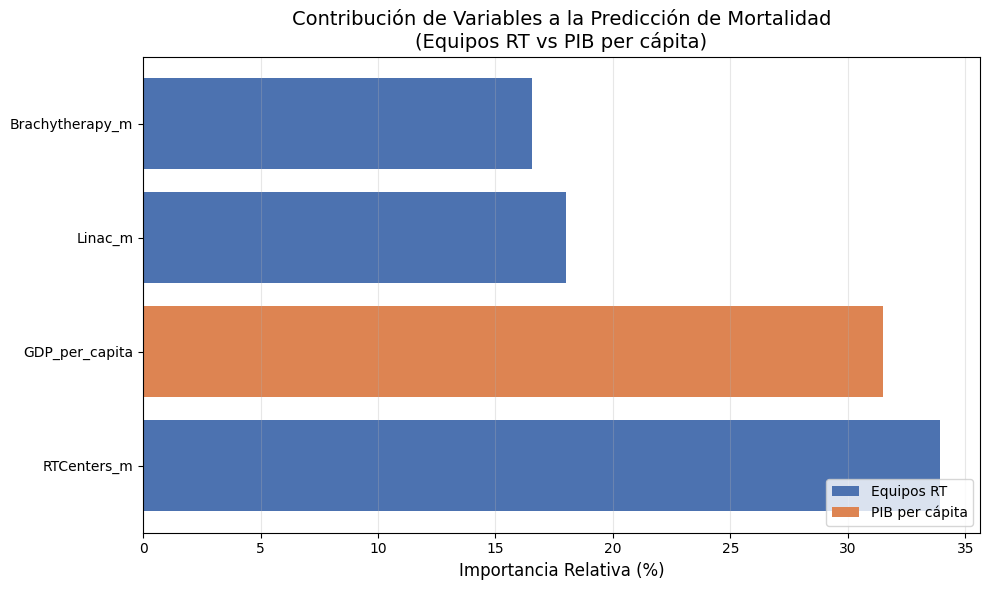


ANÁLISIS DE INTERACCIÓN: PIB × LINACs

📊 COMPARACIÓN DE MODELOS:
   AUC sin interacción: 0.650
   AUC con interacción: 0.649
   Mejora: -0.09%

❌ La interacción NO es relevante
   → PIB y equipos actúan de forma INDEPENDIENTE


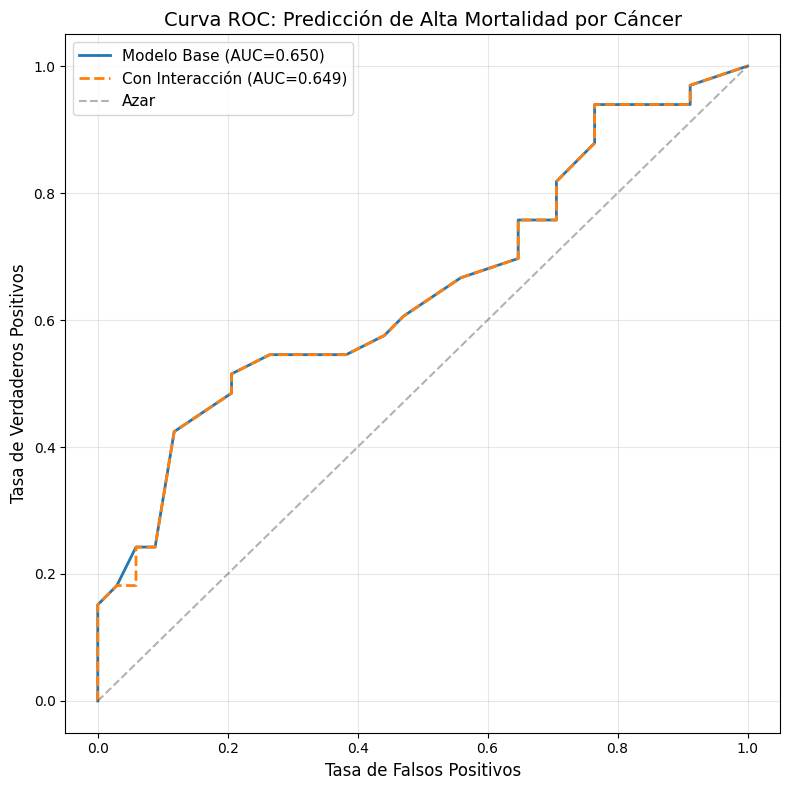


ANÁLISIS POR CUADRANTES: PIB × EQUIPOS RT

Columnas disponibles: ['Cancer label', 'Sex', 'Type', 'Year', 'ASR (World)', 'Crude rate', 'Cumulative risk', 'Total', 'Country_harmonized', 'RTCenters', 'Linac', 'Protontherapy', 'XRay', 'Brachytherapy', 'Last Update', 'Region Name', 'Population', 'Population_male', 'Population_female', 'GDP_per_capita', 'Linac_m', 'RTCenters_m', 'Brachytherapy_m', 'Protontherapy_m', 'XRay_m', 'high_mortality', 'Linac_m_woe', 'RTCenters_m_woe', 'Brachytherapy_m_woe', 'GDP_per_capita_woe', 'interaction_GDP_Linac']

📊 Valores de referencia:
   Mediana PIB per cápita: $28,311.30
   Mediana LINACs/millón: 5.48

✅ Distribución por cuadrante:
cuadrante
Alto PIB + Alta RT    98
Bajo PIB + Baja RT    98
Bajo PIB + Alta RT    35
Alto PIB + Baja RT    35
Name: count, dtype: int64

📊 MORTALIDAD PROMEDIO POR CUADRANTE:
                    Mortalidad_media  Mortalidad_std  Mortalidad_min  \
cuadrante                                                              
Alto PIB 

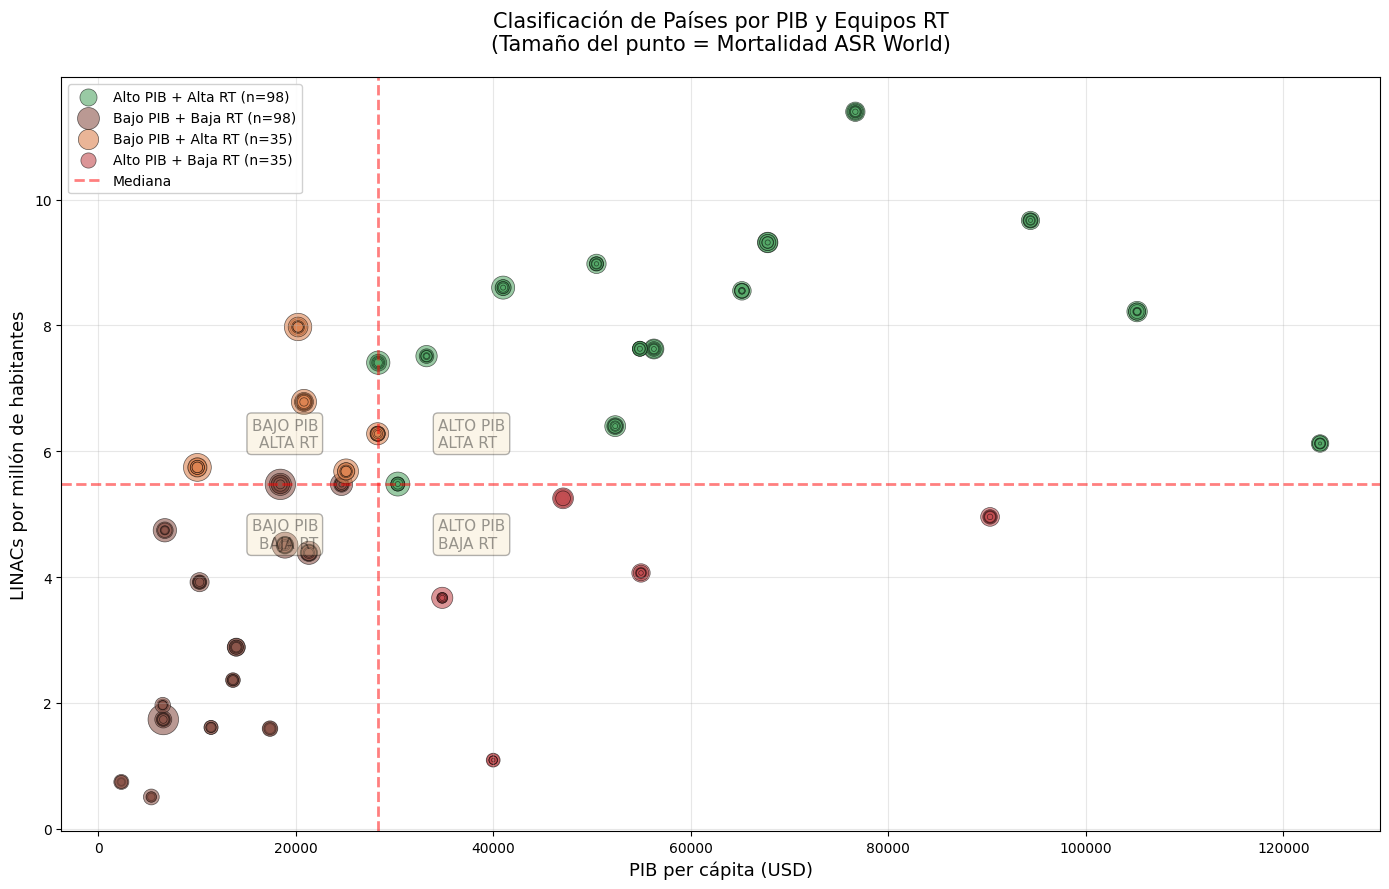


EJEMPLOS DE PAÍSES POR CUADRANTE

📍 Bajo PIB + Baja RT (98 observaciones):
   Mortalidad media: 9.74
Country_harmonized  Sex Cancer label ASR (World) GDP_per_capita Linac_m
           Armenia Male         Lung       48.37         $6,572    1.74
           Hungary Male         Lung       48.06        $18,428    5.47
            Poland Male         Lung       35.17        $18,891    4.51
           Georgia Male         Lung       28.35         $6,730    4.74
          Slovakia Male         Lung       27.94        $21,318    4.39

📍 Bajo PIB + Alta RT (35 observaciones):
   Mortalidad media: 13.61
Country_harmonized  Sex Cancer label ASR (World) GDP_per_capita Linac_m
            Serbia Male         Lung       40.27        $10,025    5.74
            Latvia Male         Lung       38.92        $20,221    7.97
           Uruguay Male         Lung       32.82        $20,819    6.78
         Lithuania Male         Lung       31.98        $25,086    5.68
           Czechia Male         Lung 

In [66]:
# ============================================================================
# ANÁLISIS WOE MULTIVARIABLE: EQUIPOS RT + PIB → MORTALIDAD
# Dataset: df_22.csv (Año 2022)
# ============================================================================



# Directorios
fig_dir = "figuras"
table_dir = "tablas"

# 1. CARGAR DATOS
# ----------------------------------------------------------------------------

df = pd.read_csv("df_22.csv")

print("="*80)
print("DATASET CARGADO")
print("="*80)
print(f"Dimensiones: {df.shape}")
print(f"\nColumnas disponibles:")
print(df.columns.tolist())


# 2. PREPARAR DATOS
# ----------------------------------------------------------------------------

# Filtrar solo mortalidad (ya está en Type='Mortality')
df_model = df[df['Type'] == 'Mortality'].copy()

# Crear variables por millón de habitantes
equipment_vars_raw = ['Linac', 'RTCenters', 'Brachytherapy', 'Protontherapy', 'XRay']

for var in equipment_vars_raw:
    df_model[f'{var}_m'] = (df_model[var] / df_model['Population']) * 1_000_000

# Variables a analizar
predictor_vars = [
    'Linac_m',
    'RTCenters_m',
    'Brachytherapy_m',
    'GDP_per_capita'
]

# Eliminar NaN
df_model = df_model.dropna(subset=['ASR (World)'] + predictor_vars)

# Excluir Leukaemia (no depende de RT)
df_model = df_model[df_model['Cancer label'] != 'Leukaemia'].copy()

print("\n" + "="*80)
print("DATOS PREPARADOS")
print("="*80)
print(f"Observaciones: {len(df_model)}")
print(f"Países únicos: {df_model['Country_harmonized'].nunique()}")
print(f"Tipos de cáncer: {df_model['Cancer label'].nunique()}")
print(f"  {df_model['Cancer label'].unique()}")


# 3. CREAR VARIABLE BINARIA (ALTA MORTALIDAD)
# ----------------------------------------------------------------------------

# Definir alta mortalidad como > mediana
median_mort = df_model['ASR (World)'].median()
df_model['high_mortality'] = (df_model['ASR (World)'] > median_mort).astype(int)

print(f"\n📊 Mediana de mortalidad: {median_mort:.2f}")
print(f"   Alta mortalidad (>mediana): {df_model['high_mortality'].sum()} casos ({df_model['high_mortality'].mean()*100:.1f}%)")
print(f"   Baja mortalidad (≤mediana): {(1-df_model['high_mortality']).sum()} casos ({(1-df_model['high_mortality'].mean())*100:.1f}%)")


# 4. BINNING ÓPTIMO PARA TODAS LAS VARIABLES
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("BINNING ÓPTIMO Y CÁLCULO DE WOE")
print("="*80)

binning_process = BinningProcess(
    variable_names=predictor_vars,
    min_bin_size=0.05,
    max_n_bins=5,
    selection_criteria={"iv": {"min": 0.001}}  # Umbral muy bajo para no excluir variables
)

# Ajustar
try:
    binning_process.fit(
        df_model[predictor_vars],
        df_model['high_mortality']
    )

    # Resumen de IV
    summary_iv = binning_process.summary()
    print("\n📈 INFORMATION VALUE (IV) - ANÁLISIS UNIVARIADO:")
    print(summary_iv)

except Exception as e:
    print(f"\n⚠️ Error en binning: {e}")
    print("Continuando con análisis manual...")


# 5. TRANSFORMAR A WOE
# ----------------------------------------------------------------------------

# Transformar cada variable individualmente
df_woe = df_model[predictor_vars].copy()

for var in predictor_vars:
    try:
        optb = OptimalBinning(
            name=var,
            dtype="numerical",
            solver="cp",
            min_bin_size=0.05,
            max_n_bins=5
        )

        X = df_model[var].values
        y = df_model['high_mortality'].values

        optb.fit(X, y)

        # Transformar a WOE
        df_model[f'{var}_woe'] = optb.transform(X, metric="woe")

        # Mostrar tabla
        print(f"\n{'='*60}")
        print(f"VARIABLE: {var}")
        print(f"{'='*60}")
        binning_table = optb.binning_table
        binning_table.build()
        print(binning_table.analysis())

    except Exception as e:
        print(f"\n⚠️ Error en {var}: {e}")
        # Usar z-score como alternativa
        df_model[f'{var}_woe'] = (df_model[var] - df_model[var].mean()) / df_model[var].std()


# 6. MODELO DE REGRESIÓN LOGÍSTICA MULTIVARIABLE
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("MODELO DE REGRESIÓN LOGÍSTICA MULTIVARIABLE")
print("="*80)

# Variables WOE
woe_vars = [f"{var}_woe" for var in predictor_vars]

# Dividir en train/test
X = df_model[woe_vars].dropna()
y = df_model.loc[X.index, 'high_mortality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\n📊 Tamaño de muestra:")
print(f"   Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Test:  {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# Ajustar modelo
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

# Predicciones
y_pred_proba = logreg.predict_proba(X_test)[:, 1]
y_pred = logreg.predict(X_test)

# Evaluación
print("\n📊 COEFICIENTES DEL MODELO:")
print("-" * 60)

coef_df = pd.DataFrame({
    'Variable': predictor_vars,
    'Coeficiente': logreg.coef_[0],
    'Odds Ratio': np.exp(logreg.coef_[0])
}).sort_values('Coeficiente', key=abs, ascending=False)

coef_df['Importancia (%)'] = (
    np.abs(coef_df['Coeficiente']) / np.abs(coef_df['Coeficiente']).sum() * 100
)

print(coef_df.to_string(index=False))

print(f"\n📈 MÉTRICAS DEL MODELO:")
print(f"   AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.3f}")
print(f"   Precisión: {(y_pred == y_test).mean():.1%}")

print("\n📋 REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_test, y_pred, target_names=['Baja Mort', 'Alta Mort']))


# 7. VISUALIZACIÓN: IMPORTANCIA DE VARIABLES
# ----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#DD8452' if 'GDP' in var else '#4C72B0' for var in coef_df['Variable']]

ax.barh(
    coef_df['Variable'],
    coef_df['Importancia (%)'],
    color=colors
)

ax.set_xlabel('Importancia Relativa (%)', fontsize=12)
ax.set_title('Contribución de Variables a la Predicción de Mortalidad\n(Equipos RT vs PIB per cápita)', fontsize=14)
ax.grid(axis='x', alpha=0.3)

# Leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', label='Equipos RT'),
    Patch(facecolor='#DD8452', label='PIB per cápita')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(f"{fig_dir}/importance_multivariate_woe.jpg", dpi=300, bbox_inches='tight')
plt.show()


# 8. ANÁLISIS DE INTERACCIÓN: PIB × LINAC
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("ANÁLISIS DE INTERACCIÓN: PIB × LINACs")
print("="*80)

# Crear variable de interacción
df_model['interaction_GDP_Linac'] = (
    df_model['GDP_per_capita_woe'] * df_model['Linac_m_woe']
)

# Modelo con interacción
X_interact = df_model.loc[X.index, woe_vars + ['interaction_GDP_Linac']].dropna()
y_interact = df_model.loc[X_interact.index, 'high_mortality']

X_train_int, X_test_int, y_train_int, y_test_int = train_test_split(
    X_interact, y_interact, test_size=0.25, random_state=42, stratify=y_interact
)

logreg_int = LogisticRegression(max_iter=1000, random_state=42)
logreg_int.fit(X_train_int, y_train_int)

# Comparar AUC
auc_base = roc_auc_score(y_test, y_pred_proba)
auc_interact = roc_auc_score(
    y_test_int,
    logreg_int.predict_proba(X_test_int)[:, 1]
)

print(f"\n📊 COMPARACIÓN DE MODELOS:")
print(f"   AUC sin interacción: {auc_base:.3f}")
print(f"   AUC con interacción: {auc_interact:.3f}")
print(f"   Mejora: {(auc_interact - auc_base)*100:+.2f}%")

if auc_interact > auc_base + 0.02:
    print("\n✅ La interacción PIB × LINACs es SIGNIFICATIVA")
    print("   → El efecto de los equipos RT DEPENDE del nivel económico del país")
else:
    print("\n❌ La interacción NO es relevante")
    print("   → PIB y equipos actúan de forma INDEPENDIENTE")


# 9. CURVA ROC
# ----------------------------------------------------------------------------

fpr_base, tpr_base, _ = roc_curve(y_test, y_pred_proba)
fpr_int, tpr_int, _ = roc_curve(y_test_int, logreg_int.predict_proba(X_test_int)[:, 1])

plt.figure(figsize=(8, 8))

plt.plot(fpr_base, tpr_base, label=f'Modelo Base (AUC={auc_base:.3f})', linewidth=2)
plt.plot(fpr_int, tpr_int, label=f'Con Interacción (AUC={auc_interact:.3f})', linewidth=2, linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Azar')

plt.xlabel('Tasa de Falsos Positivos', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos', fontsize=12)
plt.title('Curva ROC: Predicción de Alta Mortalidad por Cáncer', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{fig_dir}/roc_curve_multivariate.jpg", dpi=300, bbox_inches='tight')
plt.show()


# 10. ANÁLISIS POR CUADRANTES: PIB vs EQUIPOS (VERSIÓN CORREGIDA)
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("ANÁLISIS POR CUADRANTES: PIB × EQUIPOS RT")
print("="*80)

# Verificar que las columnas existen
print(f"\nColumnas disponibles: {df_model.columns.tolist()}")

# Calcular medianas
median_gdp = df_model['GDP_per_capita'].median()
median_linac = df_model['Linac_m'].median()

print(f"\n📊 Valores de referencia:")
print(f"   Mediana PIB per cápita: ${median_gdp:,.2f}")
print(f"   Mediana LINACs/millón: {median_linac:.2f}")

# Crear columna de cuadrante con condiciones más claras
conditions = [
    (df_model['GDP_per_capita'] >= median_gdp) & (df_model['Linac_m'] >= median_linac),
    (df_model['GDP_per_capita'] >= median_gdp) & (df_model['Linac_m'] < median_linac),
    (df_model['GDP_per_capita'] < median_gdp) & (df_model['Linac_m'] >= median_linac),
    (df_model['GDP_per_capita'] < median_gdp) & (df_model['Linac_m'] < median_linac)
]

choices = [
    'Alto PIB + Alta RT',
    'Alto PIB + Baja RT',
    'Bajo PIB + Alta RT',
    'Bajo PIB + Baja RT'
]

df_model['cuadrante'] = np.select(conditions, choices, default='Sin clasificar')

# Verificar que se creó correctamente
print(f"\n✅ Distribución por cuadrante:")
print(df_model['cuadrante'].value_counts())

# Mortalidad promedio por cuadrante
cuadrante_summary = df_model.groupby('cuadrante', as_index=True).agg({
    'ASR (World)': ['mean', 'std', 'min', 'max'],
    'Country_harmonized': 'count',
    'GDP_per_capita': 'mean',
    'Linac_m': 'mean'
})

# Aplanar columnas multinivel
cuadrante_summary.columns = ['_'.join(col).strip() for col in cuadrante_summary.columns.values]
cuadrante_summary = cuadrante_summary.rename(columns={
    'ASR (World)_mean': 'Mortalidad_media',
    'ASR (World)_std': 'Mortalidad_std',
    'ASR (World)_min': 'Mortalidad_min',
    'ASR (World)_max': 'Mortalidad_max',
    'Country_harmonized_count': 'N_observaciones',
    'GDP_per_capita_mean': 'PIB_medio',
    'Linac_m_mean': 'Linac_medio'
})

print("\n📊 MORTALIDAD PROMEDIO POR CUADRANTE:")
print(cuadrante_summary.round(2))

# Identificar cuadrante más vulnerable
worst_cuadrante = cuadrante_summary['Mortalidad_media'].idxmax()
worst_mortality = cuadrante_summary.loc[worst_cuadrante, 'Mortalidad_media']

print(f"\n⚠️ Cuadrante más vulnerable: {worst_cuadrante}")
print(f"   Mortalidad promedio: {worst_mortality:.2f} por 100,000 hab")


# 11. GRÁFICO DE CUADRANTES
# ----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 9))

# Colores por cuadrante
color_map = {
    'Alto PIB + Alta RT': '#55A868',      # Verde (mejor situación)
    'Alto PIB + Baja RT': '#C44E52',      # Rojo
    'Bajo PIB + Alta RT': '#DD8452',      # Naranja
    'Bajo PIB + Baja RT': '#8C564B'       # Marrón (peor situación)
}

for cuad in df_model['cuadrante'].unique():
    if cuad == 'Sin clasificar':
        continue

    df_cuad = df_model[df_model['cuadrante'] == cuad]

    ax.scatter(
        df_cuad['GDP_per_capita'],
        df_cuad['Linac_m'],
        s=df_cuad['ASR (World)'] * 10,  # Tamaño proporcional a mortalidad
        alpha=0.6,
        color=color_map.get(cuad, 'gray'),
        label=f"{cuad} (n={len(df_cuad)})",
        edgecolors='black',
        linewidths=0.5
    )

# Líneas de mediana
ax.axhline(median_linac, color='red', linestyle='--', alpha=0.5, linewidth=2, label='Mediana')
ax.axvline(median_gdp, color='red', linestyle='--', alpha=0.5, linewidth=2)

# Anotaciones en cada cuadrante
offset_x = (df_model['GDP_per_capita'].max() - df_model['GDP_per_capita'].min()) * 0.05
offset_y = (df_model['Linac_m'].max() - df_model['Linac_m'].min()) * 0.05

ax.text(median_gdp - offset_x, median_linac + offset_y,
        'BAJO PIB\nALTA RT',
        fontsize=11, alpha=0.4, ha='right', va='bottom',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

ax.text(median_gdp + offset_x, median_linac + offset_y,
        'ALTO PIB\nALTA RT',
        fontsize=11, alpha=0.4, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

ax.text(median_gdp - offset_x, median_linac - offset_y,
        'BAJO PIB\nBAJA RT',
        fontsize=11, alpha=0.4, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

ax.text(median_gdp + offset_x, median_linac - offset_y,
        'ALTO PIB\nBAJA RT',
        fontsize=11, alpha=0.4, ha='left', va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

ax.set_xlabel('PIB per cápita (USD)', fontsize=13)
ax.set_ylabel('LINACs por millón de habitantes', fontsize=13)
ax.set_title('Clasificación de Países por PIB y Equipos RT\n(Tamaño del punto = Mortalidad ASR World)', fontsize=15, pad=20)
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{fig_dir}/cuadrantes_pib_equipos.jpg", dpi=300, bbox_inches='tight')
plt.show()


# 12. PAÍSES ESPECÍFICOS POR CUADRANTE
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("EJEMPLOS DE PAÍSES POR CUADRANTE")
print("="*80)

for cuad in ['Bajo PIB + Baja RT', 'Bajo PIB + Alta RT', 'Alto PIB + Baja RT', 'Alto PIB + Alta RT']:
    df_cuad = df_model[df_model['cuadrante'] == cuad]

    if len(df_cuad) > 0:
        print(f"\n📍 {cuad} ({len(df_cuad)} observaciones):")
        print(f"   Mortalidad media: {df_cuad['ASR (World)'].mean():.2f}")

        # Top 5 con mayor mortalidad
        top5 = df_cuad.nlargest(5, 'ASR (World)')[
            ['Country_harmonized', 'Sex', 'Cancer label', 'ASR (World)', 'GDP_per_capita', 'Linac_m']
        ].copy()

        top5['GDP_per_capita'] = top5['GDP_per_capita'].apply(lambda x: f"${x:,.0f}")
        top5['Linac_m'] = top5['Linac_m'].apply(lambda x: f"{x:.2f}")
        top5['ASR (World)'] = top5['ASR (World)'].apply(lambda x: f"{x:.2f}")

        print(top5.to_string(index=False))


# 13. TABLA RESUMEN PARA TFM
# ----------------------------------------------------------------------------

interpretation_table = pd.DataFrame({
    'Variable': predictor_vars,
    'Coeficiente': logreg.coef_[0],
    'Odds Ratio': np.exp(logreg.coef_[0]),
    'Importancia (%)': coef_df['Importancia (%)'].values,
    'Interpretación': [
        f"↑ {var.replace('_m', '').replace('_', ' ')} → {'↑' if coef > 0 else '↓'} mortalidad"
        for var, coef in zip(predictor_vars, logreg.coef_[0])
    ]
})

print("\n" + "="*80)
print("TABLA RESUMEN: EFECTO DE VARIABLES SOBRE MORTALIDAD")
print("="*80)
print(interpretation_table.to_string(index=False))

# Guardar en LaTeX
latex_table = interpretation_table.to_latex(
    index=False,
    float_format="%.3f",
    caption="Efecto de equipos RT y PIB sobre mortalidad por cáncer (modelo multivariable WOE)",
    label="tab:multivariate_woe_model",
    escape=False
)

with open(f"{table_dir}/table_multivariate_woe.tex", 'w', encoding='utf-8') as f:
    f.write(latex_table)

print(f"\n✅ Tabla LaTeX guardada en {table_dir}/table_multivariate_woe.tex")


# 14. RESUMEN EJECUTIVO
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("🎯 RESUMEN EJECUTIVO")
print("="*80)

print(f"\n📊 MUESTRA:")
print(f"   • Países analizados: {df_model['Country_harmonized'].nunique()}")
print(f"   • Observaciones totales: {len(df_model)}")
print(f"   • Tipos de cáncer: {', '.join(df_model['Cancer label'].unique())}")
print(f"   • Distribución por sexo: {dict(df_model['Sex'].value_counts())}")

print(f"\n📈 RENDIMIENTO DEL MODELO:")
print(f"   • AUC-ROC: {auc_base:.3f}")
print(f"   • Precisión: {(y_pred == y_test).mean():.1%}")

print(f"\n🔍 VARIABLE MÁS IMPORTANTE:")
top_var = coef_df.iloc[0]['Variable']
top_importance = coef_df.iloc[0]['Importancia (%)']
top_coef = coef_df.iloc[0]['Coeficiente']
print(f"   • {top_var.replace('_', ' ').title()}")
print(f"   • Importancia: {top_importance:.1f}%")
print(f"   • Coeficiente: {top_coef:+.3f}")

print(f"\n💡 HALLAZGOS CLAVE:")

# PIB
gdp_row = coef_df[coef_df['Variable'] == 'GDP_per_capita']
if len(gdp_row) > 0:
    gdp_importance = gdp_row['Importancia (%)'].values[0]
    gdp_coef = gdp_row['Coeficiente'].values[0]

    print(f"\n   💰 PIB per cápita:")
    print(f"      • Importancia: {gdp_importance:.1f}%")
    print(f"      • Efecto: {'AUMENTA' if gdp_coef > 0 else 'REDUCE'} mortalidad")
    print(f"      • Coeficiente: {gdp_coef:+.3f}")

# Equipos
equipment_importance = coef_df[
    coef_df['Variable'].str.contains('Linac|RTCenters|Brachytherapy')
]['Importancia (%)'].sum()

print(f"\n   🏥 Equipos de Radioterapia:")
print(f"      • Importancia conjunta: {equipment_importance:.1f}%")

for var in ['Linac_m', 'RTCenters_m', 'Brachytherapy_m']:
    row = coef_df[coef_df['Variable'] == var]
    if len(row) > 0:
        print(f"      • {var.replace('_m', '')}: {row['Importancia (%)'].values[0]:.1f}% ({row['Coeficiente'].values[0]:+.3f})")

# Cuadrante
print(f"\n   ⚠️ Cuadrante más vulnerable:")
print(f"      • {worst_cuadrante}")
print(f"      • Mortalidad promedio: {worst_mortality:.2f} por 100,000 hab")

# Interacción
print(f"\n   🔗 Interacción PIB × LINACs:")
if auc_interact > auc_base + 0.02:
    print(f"      • ✅ SIGNIFICATIVA (mejora AUC en {(auc_interact-auc_base)*100:+.2f}%)")
    print(f"      • El efecto de los equipos DEPENDE del nivel económico")
else:
    print(f"      • ❌ NO significativa")
    print(f"      • PIB y equipos actúan de forma INDEPENDIENTE")

print("\n" + "="*80)


# 15. GUARDAR DATASET PROCESADO
# ----------------------------------------------------------------------------

df_model.to_csv("df_model_multivariate_woe.csv", index=False)
print(f"\n✅ Dataset procesado guardado: df_model_multivariate_woe.csv")
print(f"   Variables WOE incluidas: {', '.join(woe_vars)}")

print("\n" + "="*80)
print("✅ ANÁLISIS COMPLETADO")
print("="*80)
print(f"\nArchivos generados:")
print(f"   📊 {fig_dir}/importance_multivariate_woe.jpg")
print(f"   📊 {fig_dir}/roc_curve_multivariate.jpg")
print(f"   📊 {fig_dir}/cuadrantes_pib_equipos.jpg")
print(f"   📄 {table_dir}/table_multivariate_woe.tex")
print(f"   💾 df_model_multivariate_woe.csv")

print("\n🎯 Próximos pasos sugeridos:")
print("   1. Revisar gráfico de cuadrantes para identificar países paradójicos")
print("   2. Analizar si la interacción PIB×LINACs es significativa")
print("   3. Estratificar análisis por tipo de cáncer específico")
print("   4. Incluir tabla de coeficientes en el TFM")